# 📡 Acquiring & Visualising Academic Research Trends

[![LinkedIn](https://badgen.net/badge/LinkedIn/BRICS+EU/0A66C2?icon=linkedin)](https://www.linkedin.com/company/brics-eu/)
[![LinkedIn](https://badgen.net/badge/LinkedIn/Renato%20Profeta/0A66C2?icon=linkedin)](https://www.linkedin.com/in/renato-profeta/)
[![LinkedIn](https://badgen.net/badge/LinkedIn/BRICS%20Audio%2C%20Acoustics%20%26%20Music%20Technology/0A66C2?icon=linkedin)](https://www.linkedin.com/company/brics-audio-acoustics-music-technology/)

## A Python Tutorial with ICASSP Data from IEEE Xplore

---

**What you will learn in this notebook:**

1. How to install Python libraries and understand what each one does
2. How to acquire structured data from a real academic database (IEEE Xplore) via its REST API
3. How to clean and organise that data using `pandas`
4. How to build a publication-quality donut chart using `matplotlib`
5. How to animate your chart into a GIF across multiple years
6. How to build an interactive HTML visualisation without any web framework
7. How to analyse and plot research trajectories over time
8. How to interpret research output trends, including China's remarkable growth over the last decade

**No prior Python experience is required.** Every concept is explained before the code that uses it.

---

### 🎓 About the dataset

**ICASSP** stands for the *IEEE International Conference on Acoustics, Speech and Signal Processing*. It is one of the most prestigious and high-volume annual conferences in the world for signal processing, audio, speech technology, and machine learning research. Each year, thousands of papers are submitted and the accepted ones are published through **IEEE Xplore** — the IEEE's official digital library, found at https://ieeexplore.ieee.org.

IEEE Xplore stores rich metadata for every paper, including titles, authors, publication details, and institutional affiliation information. By analysing those affiliations, we can determine which countries contributed to a paper and build country-level statistics across conference editions.

This makes it possible to answer questions like:

> *How many ICASSP papers in 2022 included at least one author affiliated with an institution in China? How does that compare to the USA? How has it changed over ten years?*

That is exactly what this notebook does. We will acquire ICASSP metadata from IEEE Xplore for editions between 2016 and 2026, derive country participation from author affiliations, and visualise the results in several ways.

---

### 🗺️ How to use this notebook

- Read the **explanation text** (cells like this one) before running any code
- Run cells **in order from top to bottom** — later cells depend on earlier ones
- Cells marked **🏋️ Challenge** are optional exercises to test your understanding


## Part 0 — Installation & Imports

### 0.1 What is a Python library?

Python is a general-purpose language. Its standard library already includes many useful tools (for example, working with files, basic networking, and data formats like CSV). However, most real-world tasks — such as web automation, data analysis, or advanced plotting — rely on additional code.

**Libraries** (also called *packages* or *modules* in casual use) are bundles of pre-written code that extend Python's capabilities. Technically:
- a *module* is a single `.py` file
- a *package* is a collection of modules
- a *library* is a broader term for reusable functionality

Before you can use most **external libraries**, you need to install them.

In Google Colab (and Jupyter notebooks in general), you can install packages using the `pip install` command. The `!` at the start of a line tells the notebook to run the command in the system shell (terminal), not in Python itself.

---

### 0.2 Our libraries and what they do

| Library | What it does |
|---|---|
| `playwright` | Automates a real web browser (Chromium) from Python — lets us visit websites, interact with pages, and capture data (including network responses) |
| `nest_asyncio` | Allows Python’s asynchronous system (`asyncio`) to run inside Jupyter notebooks (advanced topic — details are not required for now) |
| `pandas` | The standard Python library for working with tabular data (similar to spreadsheets) |
| `pycountry` | A database of world countries with official names, ISO codes, and common aliases |
| `matplotlib` | A widely used plotting library for creating charts, graphs, and figures |
| `numpy` | Provides fast numerical computations, especially for arrays and mathematical operations |
| `Pillow` | Image processing library — used here to assemble GIF animations frame by frame |
| `adjustText` | A matplotlib add-on that automatically adjusts overlapping text labels |

In [56]:
# ── Install all required libraries ───────────────────────────────────────
# This cell may take 1–2 minutes to run. You will see a lot of output —
# that is normal. Wait for the [*] on the left to become a number.

!pip install playwright nest_asyncio pandas pycountry matplotlib numpy Pillow adjustText --quiet

# Install Chromium and its required system libraries.
# playwright install chromium  — downloads the browser binary (~150 MB)
# playwright install-deps chromium — installs OS-level shared libraries that
#   Chromium needs (libatk, libgbm, etc.). Without this step, Chromium crashes
#   with "cannot open shared object file" on a fresh Colab instance.
!playwright install chromium
!playwright install-deps chromium


Installing dependencies...
Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-freefont-ttf is already the newest version (20120503-10build1

### 0.3 Understanding `pip install`

`pip` is Python’s package manager — it downloads libraries from online repositories (such as PyPI) and installs them into your environment.

The `--quiet` flag reduces the amount of output shown, so the cell doesn’t flood your screen with installation logs.

In Google Colab, you typically only need to run the installation cell **once per session**. If you restart the runtime or reopen the notebook later, the environment is reset and you’ll need to install the libraries again.

---

### 0.4 Importing libraries

Installing a library makes it available in your environment. **Importing** it makes it usable in your current Python session.

A helpful analogy: installing is like adding a book to your library; importing is like opening that book so you can read it.

As a best practice, we import all libraries at the top of the notebook. This ensures that any cell can use them, regardless of the order in which cells are executed.

The `as` keyword lets you define a shorter name (alias) for a library. For example:

`import pandas as pd`

This means you can write `pd.DataFrame` instead of `pandas.DataFrame`, which is quicker and easier to read.

Aliases like `pd` (pandas), `np` (NumPy), and `plt` (matplotlib) are widely used conventions in the Python data science ecosystem.

In [57]:
# ── Standard library imports (included with Python — no installation needed) ──
import asyncio        # For asynchronous programming (running tasks concurrently)
import os             # For interacting with the file system (paths, folders, files)
import time           # For time-related functions (e.g., pauses with sleep)
import json           # For reading and writing JSON (a common data format)
import io             # For working with in-memory data streams (used for GIF frames)

# ── Third-party library imports (installed above) ──────────────────────
import nest_asyncio   # Allows asyncio to run inside Jupyter/Colab notebooks
import pandas as pd   # 'pd' is the conventional alias for pandas
import pycountry      # Provides country names, ISO codes, and metadata
import numpy as np    # 'np' is the conventional alias for NumPy

# ── Matplotlib and its submodules ──────────────────────────────────────
# Matplotlib is modular; different submodules provide specific functionality.
import matplotlib
matplotlib.use("Agg")  # Use a non-interactive backend (required in some environments like Colab)
import matplotlib.pyplot as plt         # Main plotting interface ('plt' by convention)
import matplotlib.gridspec as gridspec  # For arranging plots in a grid layout
import matplotlib.patheffects as pe     # For styling text (e.g., outlines, shadows)
import matplotlib.cm as cm              # Access to built-in colormaps
import matplotlib.ticker as ticker      # For formatting axis tick labels
from matplotlib.patches import Patch    # For custom legend elements
from matplotlib.backends.backend_pdf import PdfPages  # For creating multi-page PDF files

# ── Image and layout helpers ────────────────────────────────────────────
from PIL import Image      # From Pillow — for image processing and GIF creation
from adjustText import adjust_text  # Automatically adjusts overlapping text labels

# ── Enable asyncio inside the notebook event loop ───────────────────────
nest_asyncio.apply()

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### 0.5 What is `matplotlib.use("Agg")`?

Matplotlib uses different **backends** — these are the systems responsible for rendering (drawing) graphics.

In a typical desktop environment, Matplotlib uses an **interactive backend** that can display plots in a window or inline with user interaction. In environments like Google Colab (which run on remote servers without a display), interactive backends may not work reliably.

The `"Agg"` backend is a **non-interactive backend** that renders images in memory. It is commonly used for generating plots that are saved to files (e.g., PNG or PDF) rather than displayed on screen.

---

### 0.6 What is `nest_asyncio.apply()`?

Python supports **asynchronous programming**, which allows tasks to run in an interleaved (non-blocking) way using an **event loop**.

Jupyter notebooks already run an event loop in the background. However, some libraries (like Playwright or custom async code) expect to start their own event loop. This can lead to errors such as:

`RuntimeError: This event loop is already running`

`nest_asyncio.apply()` modifies the existing event loop to allow it to be reused (or "nested"), so asynchronous code can run inside the notebook without conflicts.

---

### ✅ Setup complete

Run the two cells above before continuing. Once you see the message:

`✅ All libraries imported successfully!`

you are ready to proceed.

---
## 📖 Python Quick Reference — Core Concepts Used in This Notebook

Before we go further, here is a cheat-sheet of the Python patterns that appear most often in this notebook. Return to this cell whenever a piece of code looks unfamiliar.

---

### 🔹 List comprehensions

A **list comprehension** is a compact way to build a list by applying an expression to every item in another sequence.

```python
# Long form (classic for-loop):
squares = []
for n in range(5):
    squares.append(n * n)
# Result: [0, 1, 4, 9, 16]

# Compact form (list comprehension):
squares = [n * n for n in range(5)]
# Result: [0, 1, 4, 9, 16]  ← exactly the same!

# With a filter:
even_squares = [n * n for n in range(10) if n % 2 == 0]
# Result: [0, 4, 16, 36, 64]
```

**Real example from this notebook:**
```python
ALL_BRICS = [c for cs in BRICS_GROUPS.values() for c in cs]
# Read as: "for each group cs in BRICS_GROUPS, for each country c in that group, add c"
# This flattens a dict-of-lists into a single flat list of country names.
```

---

### 🔹 Dictionary comprehensions

Same idea, but produces a `{key: value}` dictionary:

```python
squares_dict = {n: n*n for n in range(5)}
# Result: {0: 0, 1: 1, 2: 4, 3: 9, 4: 16}

# Real example:
YEAR_TITLES = {year: [f"ICASSP {year}"] for year in YEARS}
# Result: {2016: ["ICASSP 2016"], 2017: ["ICASSP 2017"], ...}
```

---

### 🔹 Nested dictionaries

A dictionary whose values are themselves dictionaries. Common for hierarchical data:

```python
ALL_COUNTRIES = {
    "BRICS+": {"China": [...], "India": [...], ...},
    "West":   {"USA":   [...], "UK":    [...], ...},
}

# Access: ALL_COUNTRIES["BRICS+"]["China"] → China's alias list
# Iterate: for bloc, countries in ALL_COUNTRIES.items():
```

---

### 🔹 `zip()` — walking two lists at once

```python
names  = ["Alice", "Bob", "Carol"]
scores = [92, 87, 95]

for name, score in zip(names, scores):
    print(f"{name} scored {score}")
# Alice scored 92 / Bob scored 87 / Carol scored 95

# Real example:
for country, colour in zip(countries, shades):
    grp_map[country] = colour
```

---

### 🔹 `set` — a collection with no duplicates

A `set` ignores duplicate values automatically. Ideal for deduplication:

```python
seen = set()
seen.add("china")
seen.add("p.r. china")
seen.add("china")   # ignored — already in the set
print(seen)         # {'china', 'p.r. china'}
print(len(seen))    # 2, not 3
```

---

### 🔹 f-strings and brace escaping

```python
name = "China"
count = 2387
print(f"{name} had {count:,} papers")
# → "China had 2,387 papers"   (:, adds thousands separator)

# Inside an HTML f-string, {{ and }} produce literal { and }
# because {expr} is the interpolation syntax:
html = f'<div style="color: red">{{literal braces}}</div>'
# → '<div style="color: red">{literal braces}</div>'
```

---

### 🔹 `async` / `await` in one sentence

`async def` defines a function that can be paused while waiting (e.g. for a web server). `await` is where the pausing happens. You will see this in Part 1 (data acquisition) and can treat it as "run this, but be patient while the internet responds."

---

> **Tip:** You do not need to memorise all of this now. Run into unfamiliar syntax? Scroll back here first.


---
## Part 1 — Data Acquisition from IEEE Xplore

### 1.1 What is API-based data acquisition?

**Data acquisition** is the process of automatically retrieving structured data from an external source. Instead of manually opening a browser, clicking through pages, and copying results, we write a program that performs these steps in a consistent and repeatable way.

**IEEE Xplore** (https://ieeexplore.ieee.org) is an academic database containing millions of research papers. Its search interface allows filtering by conference, year, author affiliation, and country. In this notebook, we automate that process — running queries for each country of interest, for each year from 2016 to 2026.

Although the site looks like a normal web page, it is actually a **web application**. When you perform a search, the browser sends requests to a backend service, which returns results as structured **JSON** data. By reproducing these requests programmatically, we can retrieve clean data without manually copying or parsing page content.

---

### 1.2 Why Playwright instead of simpler tools?

You may have seen tools like `requests` or `BeautifulSoup`. These work well for **static pages** (where the HTML already contains the data).

IEEE Xplore, however, loads its content dynamically using JavaScript and relies on session state (such as cookies) created by the browser.

**Playwright** solves this by launching a real browser (Chromium), loading the page fully, executing its JavaScript, and establishing a valid session. Once that session exists, we can programmatically access the same data the browser receives.

This approach is commonly used when working with modern, JavaScript-driven websites.

---

### 1.3 The data we're collecting

For each *(year, country)* pair, we want to compute:

**How many ICASSP papers include at least one author affiliated with that country?**

The results will be saved as CSV files with three columns:

- `bloc` — the group the country belongs to (BRICS+ or West)
- `country` — the country name
- `papers` — the number of papers

---

### 1.4 Step 1: Create the output directory

Before saving files, we ensure that the output folder exists. `os.makedirs()` creates the directory, and `exist_ok=True` means "do not raise an error if the folder already exists."

Functions like `os.makedirs()` provide an interface to the **operating system**, allowing Python to create directories, check file existence, and build file paths in a way that works across platforms (Windows, macOS, Linux).

In [58]:
# ── Output directory and year range ───────────────────────────────────
DATA_DIR = "icassp_data"          # All CSV files will be saved here
os.makedirs(DATA_DIR, exist_ok=True)

# list(range(2016, 2027)) produces [2016, 2017, ..., 2026]
# range() is exclusive on the right end, so we use 2027 to include 2026.
YEARS = list(range(2016, 2027))

# Each year maps to its ICASSP conference title as it appears on IEEE Xplore
YEAR_TITLES = {year: [f"ICASSP {year}"] for year in YEARS}

print(f"Output directory: '{DATA_DIR}/'")
print(f"Years to collect: {YEARS}")


Output directory: 'icassp_data/'
Years to collect: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


### 1.5 Step 2: Build country alias lists

This is one of the most important — and subtle — parts of the data acquisition process.

**The problem:** IEEE Xplore is an international database, and author affiliations are not standardized. The same country can appear under multiple names:

- China → "China", "P.R. China", "PRC", "People's Republic of China"
- South Korea → "Korea", "Korea, Republic of", "Republic of Korea"
- United Arab Emirates → "UAE", "United Arab Emirates"

If we query only one variant (e.g., "China"), we will miss results stored under other names — potentially a significant number of papers.

**The solution:** For each country, we build a list of **aliases** — alternative names that may appear in the database. We then query IEEE Xplore for each alias and combine the results.

Because the same paper may appear under multiple aliases, we must **deduplicate** the results to avoid double counting.

---

### Where do the aliases come from?

We combine two sources:

1. **`pycountry`**  
   Provides standardized country data, including:
   - official names
   - common names
   - ISO alpha-2 and alpha-3 codes (e.g., "US", "USA")

2. **`EXTRA_ALIASES` (manual additions)**  
   A curated dictionary of real-world variants observed in IEEE Xplore that are not covered well by standards (e.g., "PRC", "UAE")

---

### Why use `pycountry`?

Instead of manually maintaining a full list of country names, we rely on `pycountry`, which is based on international standards (ISO). This makes the system:

- more complete (fewer missing variants)
- easier to maintain
- less error-prone

This is a good example of leveraging existing libraries instead of rebuilding standard datasets from scratch.

In [59]:
# ── Curated IEEE-specific aliases ─────────────────────────────────────
# These are variants that pycountry doesn't know about but appear on IEEE Xplore.
# They were discovered by manually searching the database and checking what
# country strings appear in the affiliation fields of real papers.
EXTRA_ALIASES = {
    "China":        ["P.R. China", "P.R.C.", "PRC",
                     "People's Republic of China", "Chinese Mainland",
                     "China Mainland"],
    "USA":          ["USA", "United States", "United States of America", "US"],
    "UK":           ["UK", "United Kingdom",
                     "United Kingdom of Great Britain and Northern Ireland",
                     "England", "Scotland", "Wales", "Northern Ireland"],
    "Russia":       ["Russia", "Russian Federation"],
    "Iran":         ["Iran", "Iran (Islamic Republic of)",
                     "Islamic Republic of Iran"],
    "South Korea":  ["South Korea", "Korea", "Korea, Republic of",
                     "Republic of Korea"],
    "Taiwan":       ["Taiwan", "Taiwan, Province of China", "Chinese Taipei"],
    "Vietnam":      ["Vietnam", "Viet Nam"],
    "Turkey":       ["Turkey", "Turkiye", "Türkiye"],
    "UAE":          ["UAE", "United Arab Emirates"],
    "Czech Republic": ["Czech Republic", "Czechia"],
    "Hong Kong":    ["Hong Kong", "Hong Kong SAR", "Hong Kong, China"],
    "Macau":        ["Macau", "Macao", "Macao SAR"],
    "Moldova":      ["Moldova", "Republic of Moldova"],
    "Bolivia":      ["Bolivia", "Bolivia, Plurinational State of"],
    "Syria":        ["Syria", "Syrian Arab Republic"],
    "Venezuela":    ["Venezuela", "Venezuela, Bolivarian Republic of"],
    "Saudi Arabia": ["Saudi Arabia", "KSA"],
    "Singapore":    ["Singapore"],
    "Israel":       ["Israel"],
    "Georgia":      ["Georgia"],  # Note: risk of matching US state — handled below
}

print("✅ Extra alias dictionary defined.")
print(f"   Example — China aliases: {EXTRA_ALIASES['China']}")


✅ Extra alias dictionary defined.
   Example — China aliases: ['P.R. China', 'P.R.C.', 'PRC', "People's Republic of China", 'Chinese Mainland', 'China Mainland']


### 1.5.1 Understanding the `build_aliases` function

Now we write a function that combines the `pycountry` data with our manual aliases into one clean list.

This is a good opportunity to discuss **function design** in Python:

- A function should do **one thing** and do it well
- Its inputs (parameters) and outputs (return values) should be clearly named and documented
- It should handle edge cases gracefully (e.g., a country that `pycountry` doesn't recognise)

Notice the `str | None` type hint in the signature: this is Python 3.10+ syntax meaning the parameter can be either a string or `None`. Type hints don't affect how the code runs — they are documentation for humans (and tools like IDEs) that describe what types are expected.

The deduplication at the end uses a common Python pattern: maintain a `set` to track what you've seen (sets have O(1) lookup — very fast), and a `list` to preserve order (sets don't have a guaranteed order).


In [60]:
def build_aliases(canonical: str, iso_name: str | None) -> list[str]:
    """
    Build a deduplicated alias list for a country.

    Combines official ISO names from ``pycountry`` with the hand-curated
    ``EXTRA_ALIASES`` dictionary to produce every known name variant for a
    given country as it may appear in the IEEE Xplore database.

    Parameters
    ----------
    canonical : str
        The display name used in all output (e.g. ``"China"``).
    iso_name : str or None
        The ISO name for ``pycountry`` lookup (e.g. ``"China"``).
        Pass ``None`` for territories not recognised as sovereign states in
        the ISO standard (e.g. Taiwan, Hong Kong).

    Returns
    -------
    list of str
        All known name variants for this country, deduplicated while
        preserving insertion order.

    Examples
    --------
    >>> build_aliases("China", "China")
    ['China', 'CN', 'CHN', 'P.R. China', 'P.R.C.', ...]

    >>> build_aliases("Taiwan", None)
    ['Taiwan', 'Taiwan, Province of China', 'Chinese Taipei']
    """
    aliases = []

    # ── Step 1: Query pycountry for official ISO names ──────────────────
    # pycountry.countries.lookup() accepts a name, alpha-2, or alpha-3 code.
    # It raises LookupError if it cannot find a match.
    if iso_name:
        try:
            country = pycountry.countries.lookup(iso_name)
            aliases.append(country.name)                    # Official ISO name
            if hasattr(country, "common_name"):
                aliases.append(country.common_name)        # Shorter common name
            if hasattr(country, "official_name"):
                aliases.append(country.official_name)      # Full formal name
            aliases.append(country.alpha_2)                # 2-letter code, e.g. "CN"
            aliases.append(country.alpha_3)                # 3-letter code, e.g. "CHN"
        except LookupError:
            # pycountry didn't find it — that's OK, we still have the extras
            pass

    # ── Step 2: Always include the canonical display name ───────────────
    aliases.append(canonical)

    # ── Step 3: Add curated IEEE-specific extras ────────────────────────
    aliases.extend(EXTRA_ALIASES.get(canonical, []))

    # ── Step 4: Deduplicate while preserving order ──────────────────────
    # We cannot use set() because sets don't preserve order.
    # Pattern: track seen items in a set (O(1) lookup), build result list.
    seen: set[str] = set()
    result: list[str] = []
    for alias in aliases:
        if alias not in seen:
            seen.add(alias)
            result.append(alias)

    return result


# ── Test it ─────────────────────────────────────────────────────────────
china_aliases = build_aliases("China", "China")
print(f"China has {len(china_aliases)} aliases:")
for a in china_aliases:
    print(f"  • {a}")


China has 9 aliases:
  • China
  • People's Republic of China
  • CN
  • CHN
  • P.R. China
  • P.R.C.
  • PRC
  • Chinese Mainland
  • China Mainland


### 1.6 Step 3: Define country groups (blocs)

We organise countries into two geopolitical blocs for our analysis:

- **BRICS+** — the expanded BRICS grouping (Brazil, Russia, India, China, South Africa) plus newer full members and partner states
- **West** — EU member states, the USA, UK, Canada, Australia, Japan, South Korea, and allied nations

This is a deliberate analytical framing. The choice of which countries belong to which bloc will affect the visual story the data tells — so it is important to be transparent about these definitions.

**Python concept: dictionary of dictionaries**

`ALL_COUNTRIES` is a nested dictionary — a dictionary whose values are themselves dictionaries. This is a very common pattern for organising hierarchical data:

```python
{
    "BRICS+": {"China": [...aliases...], "India": [...aliases...], ...},
    "West":   {"USA":   [...aliases...], "UK":    [...aliases...], ...},
}
```

We iterate over this structure later with `for bloc, countries in ALL_COUNTRIES.items()`.


In [61]:
# ── Country definitions ────────────────────────────────────────────────
# Format: "Display Name": "ISO name for pycountry (or None)"
#
# We split countries into two blocs for our analysis:
#   BRICS+ — Brazil, Russia, India, China, South Africa + newer members & partners
#   West    — EU countries, USA, UK, Canada, Japan, South Korea, etc.

_BRICS_DEF = {
    "Brazil": "Brazil", "Russia": "Russian Federation", "India": "India",
    "China": "China", "South Africa": "South Africa", "Egypt": "Egypt",
    "Ethiopia": "Ethiopia", "Iran": "Iran, Islamic Republic of",
    "UAE": "United Arab Emirates", "Indonesia": "Indonesia",
    "Saudi Arabia": "Saudi Arabia", "Nigeria": "Nigeria", "Turkey": "Turkey",
    "Malaysia": "Malaysia", "Thailand": "Thailand", "Vietnam": "Viet Nam",
    "Cuba": "Cuba", "Uganda": "Uganda", "Belarus": "Belarus",
    "Bolivia": "Bolivia, Plurinational State of",
    "Hong Kong": None,    # Special administrative region
    "Taiwan": None,       # Not in ISO as sovereign state
}

_WEST_DEF = {
    # EU members
    "Austria": "Austria", "Belgium": "Belgium", "Bulgaria": "Bulgaria",
    "Croatia": "Croatia", "Cyprus": "Cyprus", "Czech Republic": "Czechia",
    "Denmark": "Denmark", "Estonia": "Estonia", "Finland": "Finland",
    "France": "France", "Germany": "Germany", "Greece": "Greece",
    "Hungary": "Hungary", "Ireland": "Ireland", "Italy": "Italy",
    "Latvia": "Latvia", "Lithuania": "Lithuania", "Luxembourg": "Luxembourg",
    "Malta": "Malta", "Netherlands": "Netherlands", "Poland": "Poland",
    "Portugal": "Portugal", "Romania": "Romania", "Slovakia": "Slovakia",
    "Slovenia": "Slovenia", "Spain": "Spain", "Sweden": "Sweden",
    # Anglo-Saxon countries
    "USA": "United States", "UK": "United Kingdom", "Canada": "Canada",
    "Australia": "Australia", "New Zealand": "New Zealand",
    # East Asian allies
    "Japan": "Japan", "South Korea": "Korea, Republic of",
    # Other Western-aligned
    "Israel": "Israel", "Norway": "Norway", "Switzerland": "Switzerland",
    "Iceland": "Iceland",
    # Edge cases
    "Ukraine": "Ukraine", "Singapore": "Singapore",
    "Georgia": "Georgia", "Moldova": "Moldova, Republic of",
}

# Build the final alias dictionaries using a dict comprehension.
# A dict comprehension is like a list comprehension but produces a dictionary:
#   {key: value for item in iterable}
BRICS_COUNTRIES = {name: build_aliases(name, iso) for name, iso in _BRICS_DEF.items()}
WEST_COUNTRIES  = {name: build_aliases(name, iso) for name, iso in _WEST_DEF.items()}

ALL_COUNTRIES = {
    "BRICS+": BRICS_COUNTRIES,
    "West":   WEST_COUNTRIES,
}

print(f"BRICS+ bloc: {len(BRICS_COUNTRIES)} countries")
print(f"West bloc:   {len(WEST_COUNTRIES)} countries")
print(f"Total:       {len(BRICS_COUNTRIES) + len(WEST_COUNTRIES)} countries to track")


BRICS+ bloc: 22 countries
West bloc:   42 countries
Total:       64 countries to track


### 1.7 Step 4: The data retrieval functions

Now we write the actual retrieval logic. This is the most complex part of the notebook — we will go through it carefully in two layers: the inner query function and the outer orchestration function.

#### Key concept: Asynchronous programming

Retrieving data from a remote server requires waiting — for the network to respond, for JavaScript to execute, for the server's rate limits. In **synchronous** code, Python would sit idle during each wait. **Asynchronous** code lets Python switch to doing something else while waiting.

We mark async functions with `async def` and use `await` to say "wait for this, but allow other tasks to run meanwhile." The `asyncio` library manages the scheduling.

#### The IEEE Xplore search API

Rather than parsing HTML, our program calls IEEE Xplore's internal **REST API** — the same one the website's search box uses. We discovered this by inspecting network traffic in a browser's developer tools (F12 → Network tab → filter by XHR/Fetch).

The API endpoint is: `https://ieeexplore.ieee.org/rest/search`

We send a POST request with a JSON payload containing a query like:
```
("Publication Title":ICASSP 2026) AND ("Author Affiliation Country":China)
```

We use `page.evaluate()` — a Playwright feature that executes JavaScript inside the live browser. This is important because the request goes through the established browser session (with cookies), not directly from Python. This is what makes the API accept our requests.

#### Pagination

The API returns at most 25 results per request. If there are more, we must request page 2, page 3, etc. This is called **pagination**. Our `while True` loop keeps fetching pages until `pg_num * 25 >= total` (we have fetched everything).

#### Deduplication with a `set`

A paper can match multiple aliases (e.g. "China" and "P.R. China"). We use a Python `set` to store paper identifiers — sets automatically ignore duplicates. This ensures each paper is counted exactly once regardless of how many aliases matched it.


In [62]:
async def fetch_country_year(
    page,
    year_title: str,
    country: str,
    affiliations: list[str],
) -> int:
    """
    Count unique papers from ``country`` in the ICASSP conference ``year_title``.

    For every alias in ``affiliations``, two separate API queries are sent to
    IEEE Xplore:

    1. ``"Author Affiliation Country"`` — a normalised structured field
    2. ``"Author Affiliations"``        — a free-text field that catches variants

    Paper identifiers (DOI or article number) are collected in a Python
    ``set``, which automatically deduplicates: a paper matched by multiple
    aliases is counted exactly once.

    Parameters
    ----------
    page : playwright.async_api.Page
        An active Playwright browser page with a valid IEEE Xplore session.
    year_title : str
        The conference title string as it appears on IEEE Xplore,
        e.g. ``"ICASSP 2026"``.
    country : str
        Display name used only for log messages, e.g. ``"China"``.
    affiliations : list of str
        All alias strings to query, e.g. ``["China", "P.R. China", ...]``.

    Returns
    -------
    int
        Number of unique papers found across all aliases and both query fields.

    Notes
    -----
    A 1.2-second pause is inserted between paginated requests and a 0.6-second
    pause between alias queries to avoid overloading the server.
    """
    # A set automatically deduplicates — if we see the same paper twice
    # (once via "China", once via "P.R. China"), it is stored only once.
    seen: set[str] = set()

    async def run_query(query_text: str) -> None:
        """
        Execute a single paginated search query, adding all paper IDs to ``seen``.

        Parameters
        ----------
        query_text : str
            The IEEE Xplore Boolean query string to send to the REST API.
        """
        pg_num = 1
        while True:
            # Build the JSON payload the IEEE Xplore API expects
            payload = {
                "newsearch":    True,
                "matchBoolean": True,
                "queryText":    query_text,
                "pageNumber":   pg_num,
                "rowsPerPage":  25,         # Maximum results per page
                "sortType":     "relevance",
            }

            try:
                # page.evaluate() runs JavaScript inside the live browser.
                # Using the browser's fetch() means the request includes valid
                # session cookies — essential for the API to respond correctly.
                response = await page.evaluate(
                    '''(payload) => {
                        return fetch("https://ieeexplore.ieee.org/rest/search", {
                            method: "POST",
                            headers: {
                                "Content-Type": "application/json",
                                "Accept": "application/json, text/plain, */*",
                                "X-Requested-With": "XMLHttpRequest"
                            },
                            credentials: "include",
                            body: JSON.stringify(payload)
                        })
                        .then(r => r.json())
                        .catch(e => ({error: e.toString()}));
                    }''',
                    payload,
                )
            except Exception as e:
                print(f"    ⚠  Browser eval error: {e}")
                break

            if isinstance(response, dict) and "error" in response:
                print(f"    ⚠  API error: {response['error']}")
                break

            records = response.get("records", [])
            total   = response.get("totalRecords", 0)

            if not records:
                break  # No results on this page — stop paginating

            # Collect a unique identifier for each paper.
            # We prefer DOI (globally unique); fall back to article number or title.
            for rec in records:
                uid = (rec.get("doi", "")
                       or str(rec.get("articleNumber", ""))
                       or rec.get("articleTitle", ""))
                if uid:
                    seen.add(uid)

            # Have we fetched all pages?
            if pg_num * 25 >= total:
                break

            pg_num += 1
            await asyncio.sleep(1.2)  # Polite pause between page requests

    # Search every alias against BOTH query fields
    for alias in affiliations:
        # Field 1: structured "Author Affiliation Country" field
        await run_query(
            f'("Publication Title":{year_title}) '
            f'AND ("Author Affiliation Country":{alias})'
        )
        await asyncio.sleep(0.6)

        # Field 2: free-text "Author Affiliations" field (catches variants)
        await run_query(
            f'("Publication Title":{year_title}) '
            f'AND ("Author Affiliations":{alias})'
        )
        await asyncio.sleep(0.6)

    return len(seen)  # set size = unique paper count


print("✅ fetch_country_year() defined.")


✅ fetch_country_year() defined.


### 1.7.1 The per-year and master acquisition functions

`fetch_country_year()` handles a single (country, year) pair. Now we write two higher-level functions that use it:

- `scrape_year()` — loops over all countries for one year, collecting results into a list
- `scrape_all_years()` — manages the full browser lifecycle, iterates over all years, saves CSVs, and skips years that are already done

**Python concept: `async with`**

`async with async_playwright() as pw:` is an **asynchronous context manager**. It ensures the browser is properly started when we enter the block and properly closed when we leave it — even if an error occurs partway through. This is the same principle as the regular `with open(...) as f:` pattern you may have seen for file handling.

**Python concept: f-strings**

Throughout this code you will see strings like `f"summary_icassp_{year}.csv"`. The `f` prefix means it is a **formatted string literal** — Python evaluates any expression inside `{}` and inserts the result. So if `year = 2026`, the result is `"summary_icassp_2026.csv"`.


In [63]:
async def scrape_year(page, year: int) -> list[dict]:
    """
    Retrieve paper counts for all countries in both blocs for one ICASSP year.

    Iterates over every country defined in ``ALL_COUNTRIES``, calls
    ``fetch_country_year()`` for each, and returns the results as a list
    of dictionaries suitable for constructing a ``pandas.DataFrame``.

    Parameters
    ----------
    page : playwright.async_api.Page
        An active Playwright browser page with a valid IEEE Xplore session.
    year : int
        The conference year to retrieve, e.g. ``2026``.

    Returns
    -------
    list of dict
        Each element has keys ``"bloc"``, ``"country"``, and ``"papers"``.
        Example: ``[{"bloc": "BRICS+", "country": "China", "papers": 2387}, ...]``
    """
    titles = YEAR_TITLES[year]
    rows: list[dict] = []

    for bloc, countries in ALL_COUNTRIES.items():
        print(f"  [{year}] {bloc} bloc — {len(countries)} countries:")
        for country, affiliations in countries.items():
            best = 0
            for title in titles:
                count = await fetch_country_year(page, title, country, affiliations)
                best = max(best, count)
                if best > 0:
                    break  # Found results — no need to try other title variants

            print(f"    {country:<20} {best:>5} papers")
            rows.append({"bloc": bloc, "country": country, "papers": best})
            await asyncio.sleep(1.0)  # Pause between countries

    return rows


async def scrape_all_years() -> None:
    """
    Launch Chromium, acquire data for all years, and save one CSV per year.

    This is the top-level entry point for a full data acquisition run.

    Responsibilities
    ----------------
    - Launching and closing the Chromium browser
    - Warming up the session by visiting IEEE Xplore (establishes cookies)
    - Iterating over ``YEARS`` and calling ``scrape_year()`` for each
    - Saving each year's results as ``icassp_data/summary_icassp_{year}.csv``\n    - Skipping years that already have a saved CSV (allows resuming)\n\n    Notes\n    -----\n    Full acquisition (all 11 years, 60+ countries) takes approximately\n    3–4 hours. Use the single-year demo cell below to test the pipeline\n    before committing to a full run.\n    """
    from playwright.async_api import async_playwright

    async with async_playwright() as pw:
        # Launch a headless browser.
        # We try Chromium first (faster, smaller); if system libraries are missing
        # we fall back to Firefox, which bundles its own libs and always works.
        #
        # The "--no-sandbox" flag is required in Colab / Docker environments where
        # the process does not have the kernel namespacing capabilities that Chrome
        # normally relies on for its internal sandbox.
        _launch_args = [
            "--no-sandbox",
            "--disable-setuid-sandbox",
            "--disable-dev-shm-usage",
            "--disable-gpu",
        ]
        try:
            browser = await pw.chromium.launch(headless=True, args=_launch_args)
        except Exception as _e:
            print(f"⚠  Chromium failed ({_e}). Falling back to Firefox...")
            print("   (This is normal if playwright install-deps did not run.)")
            await pw.firefox.install()   # download Firefox binary if needed
            browser = await pw.firefox.launch(headless=True)

        # Create a browser context with a realistic user-agent string.
        # Identifying as a real browser helps avoid requests being blocked.
        context = await browser.new_context(
            user_agent=(
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/124.0.0.0 Safari/537.36"
            )
        )
        page = await context.new_page()

        # ── Warm up: visit IEEE Xplore to establish session cookies ──────
        # The API requires valid session cookies that are set by the homepage
        # JavaScript. We visit the homepage first, then the search page,
        # to ensure all cookies are in place before we begin querying.
        print("🌐 Warming up browser session on IEEE Xplore...")
        await page.goto(
            "https://ieeexplore.ieee.org",
            wait_until="domcontentloaded",
            timeout=30_000,
        )
        await asyncio.sleep(3)
        await page.goto(
            "https://ieeexplore.ieee.org/search/searchresult.jsp"
            "?queryText=ICASSP&newsearch=true",
            wait_until="domcontentloaded",
            timeout=30_000,
        )
        await asyncio.sleep(3)
        print("✅ Session ready.\n")

        # ── Acquire each year ────────────────────────────────────────────
        for year in YEARS:
            out_path = os.path.join(DATA_DIR, f"summary_icassp_{year}.csv")

            # Resume support: skip years we've already collected
            if os.path.exists(out_path):
                print(f"⏭  {year}: already collected, skipping.")
                continue

            print(f"{'─'*50}")
            print(f"  Acquiring ICASSP {year} ...")
            t0      = time.time()
            rows    = await scrape_year(page, year)
            elapsed = time.time() - t0

            # Save results to CSV using pandas
            df = pd.DataFrame(rows, columns=["bloc", "country", "papers"])
            df.to_csv(out_path, index=False)
            print(f"\n  ✅ {year} saved in {elapsed/60:.1f} min → {out_path}")

            if year != YEARS[-1]:
                await asyncio.sleep(5)  # Pause between years

        await browser.close()
        print("\n" + "=" * 50)
        print("All years acquired! Proceed to Part 2.")
        print("=" * 50)


print("✅ Data acquisition functions defined.")


✅ Data acquisition functions defined.


### 1.8 Step 5: Run the full acquisition

This cell runs the full data acquisition for all years (2016–2026). It launches a headless Chromium browser, queries IEEE Xplore for every country and year combination, and saves one CSV file per year into `icassp_data/`.

**How long will this take?** Each year takes roughly 10–15 minutes (60+ countries × 2 query fields × multiple aliases, with polite pauses between requests). All 11 years together take approximately 2 hours. The cell is safe to interrupt and re-run — `scrape_all_years()` checks for existing CSV files and skips years already collected.

**Why does it take so long?** We deliberately pause between requests (1–2 seconds each) to avoid overwhelming the IEEE Xplore server. This is standard practice when writing a web scraper — rapid-fire requests can get your IP address blocked or harm the service for others.

**What if a year fails mid-way?** The CSV is only written after a full year is complete. If a year is interrupted, just re-run this cell — it will redo only the incomplete year and skip all finished ones.


In [64]:
# ── Run the full acquisition (all years, resumes automatically) ────────
# Estimated time: 2 hours total.
# The function skips years whose CSV already exists, so it is safe to
# interrupt and re-run — it picks up where it left off.

await scrape_all_years()


🌐 Warming up browser session on IEEE Xplore...
✅ Session ready.

⏭  2016: already collected, skipping.
⏭  2017: already collected, skipping.
⏭  2018: already collected, skipping.
⏭  2019: already collected, skipping.
⏭  2020: already collected, skipping.
⏭  2021: already collected, skipping.
⏭  2022: already collected, skipping.
⏭  2023: already collected, skipping.
⏭  2024: already collected, skipping.
⏭  2025: already collected, skipping.
⏭  2026: already collected, skipping.

All years acquired! Proceed to Part 2.


### 1.9 Step 6: Load the acquired data

With acquisition complete, we load the 2026 CSV and build the pandas Series that all subsequent visualisation cells use.

**Python concept: `pd.Series`**

A `pandas.Series` is a one-dimensional labelled array — like a single column of a spreadsheet, or a dictionary with ordered values. Here we create two Series where the **index** (label) is the country name and the **values** are paper counts. This lets us look up a country's paper count by name: `brics_summary["China"]` returns China's actual paper count from the CSV.

After running this cell, `brics_summary` and `west_summary` contain real acquired data. Every plot in this notebook is built from these values — nothing is hardcoded.


In [65]:
# ── Load the acquired 2026 data from CSV ──────────────────────────────
# scrape_all_years() saved summary_icassp_2026.csv (and all other years).
# Here we read the 2026 file and build the per-bloc Series.

csv_2026 = os.path.join(DATA_DIR, "summary_icassp_2026.csv")
if not os.path.exists(csv_2026):
    raise FileNotFoundError(
        f"{csv_2026} not found — make sure the acquisition cell above completed "
        "successfully before running this cell."
    )

df_2026 = pd.read_csv(csv_2026)

brics_df = df_2026[df_2026["bloc"] == "BRICS+"].set_index("country")["papers"]
west_df  = df_2026[df_2026["bloc"] == "West"].set_index("country")["papers"]

# Build Series covering all defined countries (use _BRICS_DEF/_WEST_DEF keys,
# which are already defined in cell 1.6 above). Fills any country absent from
# the CSV with 0.
brics_summary = pd.Series({c: int(brics_df.get(c, 0)) for c in _BRICS_DEF},
                           name="papers")
west_summary  = pd.Series({c: int(west_df.get(c, 0))  for c in _WEST_DEF},
                           name="papers")

# Also expose as plain dicts for cells in Part 5 that use dict syntax
brics_2026 = brics_summary.to_dict()
west_2026  = west_summary.to_dict()

total_all = int(brics_summary.sum() + west_summary.sum())
print(f"ICASSP 2026 — total papers across both blocs: {total_all:,}")
print()
print("Top 10 BRICS+ countries:")
print(brics_summary.sort_values(ascending=False).head(10).to_string())
print()
print("Top 10 West countries:")
print(west_summary.sort_values(ascending=False).head(10).to_string())


ICASSP 2026 — total papers across both blocs: 4,580

Top 10 BRICS+ countries:
China       2389
India         76
Ethiopia      21
UAE           13
Malaysia      13
Turkey        11
Vietnam       11
Brazil        10
Russia         4
Egypt          4

Top 10 West countries:
USA            380
Germany        204
UK             198
Japan          168
South Korea    130
Singapore      120
France         104
Canada          99
Australia       73
Italy           68


---
### 🏋️ Challenge 1 — Explore the data

Now that you have the 2026 data loaded as pandas Series, try the following. Add new code cells below this one for your answers.

1. **What is the total number of papers in ICASSP 2026 for both BRICS+ and the Collective West?** *(Hint: `brics_summary.sum() + west_summary.sum()`)*
2. **What percentage of all papers came from China alone?** *(Hint: divide China's count by the total and multiply by 100)*
3. **How many BRICS+ countries contributed zero papers?** *(Hint: `(brics_summary == 0).sum()`)*
4. **Which single country — across both blocs — submitted the most papers?** Does the answer surprise you?
5. **How does China's count compare to the entire West bloc combined?** *(Hint: `brics_2026["China"]` vs `west_summary.sum()`)*


---
## Part 2 — Building the Donut Chart

### 2.1 What is a donut chart?

A donut chart is a pie chart with a hole in the middle. Like a pie chart, each slice represents a proportion of the total. The hole in the centre makes it easier to read and also gives us space to display summary information.

In our chart, we will draw **two concentric rings**:
- **Outer ring:** the top 10 countries per bloc, each slice sized by its **real paper count** as a proportion of the grand total
- **Inner ring:** one segment per bloc (BRICS+ and West), each sized by its **real total** as a proportion of the grand total

Both rings reflect genuine data proportions — no artificial scaling. This means China's dominance, which represents roughly half of all papers on its own, will be visually obvious and accurate.

### 2.2 How matplotlib figures work

Before drawing anything, we need to understand matplotlib's layout system:

```
Figure  ← the whole canvas (like a sheet of paper)
  └─ Axes  ← a single plot area (you can have many on one Figure)
       ├─ x-axis, y-axis
       ├─ title, labels
       └─ data (lines, bars, wedges...)
```

We will use **GridSpec** to divide our figure into three areas:
- Left (wide): the donut chart
- Centre: a ranked table for BRICS+ countries
- Right: a ranked table for West countries

### 2.3 Step 1: Define country groups and colours


In [66]:
# ── Subgroup definitions for colour coding ────────────────────────────
# We subdivide each bloc into named groups, and assign each group a base colour.
# Countries within a group receive slightly different shades of that colour.
# This visual grouping helps viewers quickly identify which sub-category a
# country belongs to.

BRICS_GROUPS = {
    "BRICS Core":     ["Brazil", "Russia", "India", "China", "South Africa"],
    "BRICS+ Members": ["Egypt", "Ethiopia", "Iran", "UAE", "Indonesia", "Saudi Arabia"],
    "Partners":       ["Nigeria", "Turkey", "Malaysia", "Thailand", "Vietnam",
                       "Cuba", "Uganda", "Belarus", "Bolivia"],
}
WEST_GROUPS = {
    "EU":              [
        "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus",
        "Czech Republic", "Denmark", "Estonia", "Finland", "France",
        "Germany", "Greece", "Hungary", "Ireland", "Italy", "Latvia",
        "Lithuania", "Luxembourg", "Malta", "Netherlands", "Poland",
        "Portugal", "Romania", "Slovakia", "Slovenia", "Spain", "Sweden",
    ],
    "Anglo-Saxon":     ["USA", "UK", "Canada", "Australia", "New Zealand"],
    "East Asian Ally": ["Japan", "South Korea"],
    "Other West":      ["Israel", "Norway", "Switzerland", "Iceland"],
    "Edge Cases":      ["Turkey", "Ukraine", "Singapore", "Georgia", "Moldova"],
}

# Base colours for each group (in hex format: #RRGGBB)
BRICS_BASES = {
    "BRICS Core":     "#c0392b",  # Deep red
    "BRICS+ Members": "#e67e22",  # Orange
    "Partners":       "#f39c12",  # Amber
}
WEST_BASES = {
    "EU":              "#1a5276",  # Dark navy
    "Anglo-Saxon":     "#1f618d",  # Medium blue
    "East Asian Ally": "#117a65",  # Teal
    "Other West":      "#2471a3",  # Bright blue
    "Edge Cases":      "#5d6d7e",  # Grey-blue
}

print("✅ Group and colour definitions set.")


✅ Group and colour definitions set.


### 2.3.1 Generating colour gradients

Within each group, countries need slightly different shades so they are visually distinguishable from one another. We achieve this with **linear interpolation** between the base colour and white.

**What is linear interpolation?** Given two values A and B, the interpolated value at fraction `t` (0 to 1) is: `A + (B - A) * t`. At `t=0` you get A; at `t=1` you get B; at `t=0.5` you get the midpoint. Here we apply this formula independently to each of the three colour channels (red, green, blue).

**How do hex colours work?** A hex colour like `#c0392b` encodes three bytes: `c0` is red (192/255), `39` is green (57/255), `2b` is blue (43/255). `int("c0", 16)` converts the hex string `"c0"` to the integer 192. Dividing by 255 gives a float in [0, 1], which is what matplotlib expects.


In [67]:
def make_gradient(base_hex: str, n: int, lighten: float = 0.48) -> list[tuple]:
    """
    Generate ``n`` colours ranging from ``base_hex`` toward white.

    Uses linear interpolation between the base colour and white to produce
    a set of visually distinct shades within the same colour family.

    Parameters
    ----------
    base_hex : str
        A hex colour string in the form ``"#RRGGBB"``, e.g. ``"#c0392b"``.
    n : int
        Number of colours to generate.
    lighten : float, optional
        Maximum lightening fraction, by default ``0.48``.
        ``0`` returns ``n`` identical copies of the base colour.
        ``1`` would make the last colour pure white.

    Returns
    -------
    list of tuple
        Each element is an ``(r, g, b)`` tuple with float values in ``[0, 1]``.

    Examples
    --------
    >>> make_gradient("#c0392b", 3)
    [(0.75, 0.22, 0.17), (0.82, 0.42, 0.38), (0.89, 0.62, 0.59)]
    """
    # Parse "#RRGGBB" → three floats in [0, 1]
    # Slicing: base_hex[1:3] extracts "RR", base_hex[3:5] extracts "GG", etc.
    r = int(base_hex[1:3], 16) / 255
    g = int(base_hex[3:5], 16) / 255
    b = int(base_hex[5:7], 16) / 255

    colours = []
    for i in range(n):
        # Linear interpolation: fraction 0 → base colour, fraction 1 → white
        fraction = i / max(n - 1, 1) * lighten
        colours.append((
            r + (1 - r) * fraction,   # Interpolate red channel
            g + (1 - g) * fraction,   # Interpolate green channel
            b + (1 - b) * fraction,   # Interpolate blue channel
        ))
    return colours


# ── Test: show the gradient for BRICS Core ──────────────────────────────
test_cols = make_gradient("#c0392b", 5)
print("5-shade gradient from #c0392b (red):")
for i, (r, g, b) in enumerate(test_cols):
    hex_str = "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))
    print(f"  Shade {i}: {hex_str}")


5-shade gradient from #c0392b (red):
  Shade 0: #c0392b
  Shade 1: #c75044
  Shade 2: #cf685d
  Shade 3: #d68077
  Shade 4: #de9890


### 2.3.2 Building the slice data

The `build_slices()` function flattens the nested group structure into three parallel lists — one for labels, one for values, one for colours. This is the format that `matplotlib`'s `ax.pie()` function expects.

**Python concept: parallel lists**

Many matplotlib drawing functions accept data as parallel lists, where `labels[i]`, `values[i]`, and `colours[i]` all correspond to the same data point. This is different from a list of objects — it trades readability for the speed and simplicity that matplotlib needs internally.


In [68]:
def build_slices(
    groups: dict,
    summary: pd.Series,
    bases: dict,
) -> tuple[list, list, list, dict]:
    """
    Flatten a nested group dictionary into parallel lists for ``ax.pie()``.

    Iterates over each group, generates a colour gradient for the countries
    in that group, and appends each country's label, paper count, colour,\n    and colour mapping to the output lists.\n\n    Parameters\n    ----------\n    groups : dict\n        Nested dict mapping group names to lists of country names.\n        E.g. ``{"BRICS Core": ["Brazil", "Russia", ...], ...}``.\n    summary : pandas.Series\n        Paper counts indexed by country name.\n    bases : dict\n        Mapping of group name to base hex colour string.\n        E.g. ``{"BRICS Core": "#c0392b", ...}``.\n\n    Returns\n    -------\n    labels : list of str\n        Country names in group order.\n    values : list of int\n        Paper counts corresponding to each label.\n    colours : list of tuple\n        ``(r, g, b)`` colour tuples corresponding to each label.\n    grp_map : dict\n        ``{country_name: (r, g, b)}`` lookup used when drawing tables.\n    """
    labels:  list[str]   = []
    values:  list[int]   = []
    colours: list[tuple] = []
    grp_map: dict        = {}

    for group_name, countries in groups.items():
        # Generate one shade per country in this group
        shades = make_gradient(bases[group_name], len(countries))

        for country, colour in zip(countries, shades):
            # Series.get() returns 0 if the country is not in the data
            paper_count = int(summary.get(country, 0))
            labels.append(country)
            values.append(paper_count)
            colours.append(colour)
            grp_map[country] = colour

    return labels, values, colours, grp_map


brics_labels, brics_vals, brics_cols, brics_grp_map = build_slices(
    BRICS_GROUPS, brics_summary, BRICS_BASES)
west_labels, west_vals, west_cols, west_grp_map = build_slices(
    WEST_GROUPS, west_summary, WEST_BASES)

print(f"BRICS+ slices: {len(brics_labels)} countries")
print(f"West slices:   {len(west_labels)} countries")


BRICS+ slices: 20 countries
West slices:   43 countries


### 2.4 Step 2: Computing real proportions

The outer ring will show only the **top 5 countries per bloc** labelled, but will draw all countries as wedges sized by their genuine paper counts. The inner ring shows the true total for each bloc.

**Why top 5 only for labels?** With dozens of countries, many have very small wedges — labelling them all would cause illegible overlaps. The companion tables on the right already list every country with exact numbers, so no information is lost by limiting the outer labels.


In [69]:
# ── Compute real totals for inner ring ────────────────────────────────
brics_total = int(brics_summary.sum())
west_total  = int(west_summary.sum())
total_all   = brics_total + west_total

# Inner ring values: the real paper totals for each bloc
inner_values  = [brics_total, west_total]
inner_colours = ["#922b21", "#1a5276"]   # BRICS+ red, West navy
inner_labels  = ["BRICS+", "Collective\nWest"]

# Outer ring: combine both blocs into single parallel lists
# Raw values are used directly — matplotlib will size wedges proportionally
outer_labels  = brics_labels + west_labels
outer_values  = brics_vals   + west_vals    # Real counts — no scaling applied
outer_colours = brics_cols   + west_cols

# ── Identify top 10 per bloc — only these will receive outer ring labels ─
# sorted() returns a new list; reverse=True gives descending order
top5_brics = set(
    sorted([c for c in brics_labels if int(brics_summary.get(c, 0)) > 0],
           key=lambda c: int(brics_summary.get(c, 0)), reverse=True)[:5]
)
top5_west = set(
    sorted([c for c in west_labels if int(west_summary.get(c, 0)) > 0],
           key=lambda c: int(west_summary.get(c, 0)), reverse=True)[:5]
)

print(f"Total papers:  {total_all:,}")
print(f"BRICS+ total:  {brics_total:,}  ({brics_total / total_all * 100:.1f}% of grand total)")
print(f"West total:    {west_total:,}  ({west_total  / total_all * 100:.1f}% of grand total)")
print()
print(f"Top 10 BRICS+ (will be labelled): {sorted(top5_brics, key=lambda c: -brics_2026.get(c,0))}")
print(f"Top 10 West   (will be labelled): {sorted(top5_west,  key=lambda c: -west_2026.get(c,0))}")


Total papers:  4,580
BRICS+ total:  2,561  (55.9% of grand total)
West total:    2,019  (44.1% of grand total)

Top 10 BRICS+ (will be labelled): ['China', 'India', 'Ethiopia', 'UAE', 'Malaysia']
Top 10 West   (will be labelled): ['USA', 'Germany', 'UK', 'Japan', 'South Korea']


### 2.5 Step 3: Drawing the figure

Now we put it all together. We create a `Figure` with a `GridSpec` layout and draw three components: the donut, the BRICS+ table, and the West table.

Pay attention to how we layer the chart elements:
1. Draw the **inner ring** first (it is behind the outer ring in z-order)
2. Draw the **outer ring** on top
3. Place **centre text** in the hole
4. Place **inner ring labels** inside the ring
5. Place **outer ring labels** with leader lines for top-5 countries only, using `adjustText` to prevent overlaps
6. Draw the **divider line** and **legend** last

**Python concept: `zip()`**

`zip(list_a, list_b)` creates an iterator that yields pairs `(list_a[0], list_b[0])`, `(list_a[1], list_b[1])`, etc. It lets you iterate over multiple lists simultaneously, which is the natural way to walk through our parallel-list data structure.


In [70]:
# ── Create the figure layout ───────────────────────────────────────────
BG = "#0d1117"   # Background colour: very dark navy/black

fig = plt.figure(figsize=(28, 17), facecolor=BG)

# GridSpec divides the figure into a 1-row, 3-column grid.
# width_ratios=[2.4, 1, 1] means the donut column is 2.4× wider than each table.
gs = gridspec.GridSpec(
    1, 3,
    width_ratios=[2.4, 1, 1],
    wspace=0.02,
    left=0.01, right=0.99, top=0.92, bottom=0.05,
)

ax_donut = fig.add_subplot(gs[0])   # Left column: the donut
ax_brics = fig.add_subplot(gs[1])   # Centre column: BRICS+ table
ax_west  = fig.add_subplot(gs[2])   # Right column: West table

for ax in (ax_donut, ax_brics, ax_west):
    ax.set_facecolor(BG)

ax_donut.set_aspect("equal")        # Ensures the donut is circular, not oval

print("✅ Figure and axes created.")


✅ Figure and axes created.


### 🗺️ Anatomy of `ax.pie()` — what each parameter does

Before writing the drawing code, here is a reference table for `ax.pie()`. Every parameter name is used in the cells below.

| Parameter | Type | What it controls | Our value |
|---|---|---|---|
| `x` (first positional) | list of numbers | The **value** of each wedge — matplotlib divides 360° proportionally | `outer_values` (real paper counts) |
| `radius` | float | How far the outer edge of the ring extends from the centre | `1.0` (outer ring), `0.62` (inner ring) |
| `colors` | list | The fill colour of each wedge | `outer_colours` |
| `startangle` | float (degrees) | Which angle the **first wedge starts at**. `90` = 12 o'clock | `90` |
| `counterclock` | bool | Direction slices are drawn. `False` = clockwise (left-to-right reading) | `False` |
| `wedgeprops` | dict | A dictionary of per-wedge styling options (see below) | `dict(width=0.36, ...)` |

**Inside `wedgeprops`:**

| Key | What it controls | Our value |
|---|---|---|
| `width` | Thickness of the ring. `1.0` = solid pie, `0.36` = thin ring | `0.36` (outer), `0.26` (inner) |
| `edgecolor` | The colour of the thin gap between wedges | `BG` (background colour — makes gaps invisible against the dark canvas) |
| `linewidth` | Thickness of the edge line in points | `0.8` (outer), `2.5` (inner — thicker separator between blocs) |

**Visual anatomy — the two rings:**

```
         ╔══════════════════════════╗
         ║  radius=1.0, width=0.36  ║  ← outer ring: one wedge per country
         ║  ┌──────────────────┐    ║
         ║  │  radius=0.62     │    ║  ← inner ring: one wedge per bloc
         ║  │  width=0.26      │    ║
         ║  │  ┌────────────┐  │    ║
         ║  │  │            │  │    ║  ← hole: radius < (0.62 - 0.26) = 0.36
         ║  │  │  centre    │  │    ║     this is where we put the total count text
         ║  │  │  text here │  │    ║
         ║  │  └────────────┘  │    ║
         ║  └──────────────────┘    ║
         ╚══════════════════════════╝
```

> **Key insight:** We draw two separate `ax.pie()` calls that share the same axes centre `(0, 0)`. The outer ring has a larger radius so it sits around the inner ring. Setting `width < radius` on each ring creates the "donut hole" effect.


In [71]:
# ── Draw the two donut rings ───────────────────────────────────────────
# matplotlib's ax.pie() draws a pie chart. Key parameters:
#   radius       — outer radius (inner ring = 0.62 sits inside outer ring = 1.0)
#   wedgeprops   — 'width' controls ring thickness; 'edgecolor' adds a gap
#   startangle   — 90 means start at the top (12 o'clock position)
#   counterclock — False means slices go clockwise (the familiar direction)
#
# For a donut, we draw two pie charts sharing the same centre.
# The outer ring has radius 1.0 and width 0.36 → occupies radii 0.64–1.0
# The inner ring has radius 0.62 and width 0.26 → occupies radii 0.36–0.62
# The hole in the middle (radius < 0.36) is empty.

# Outer ring: one wedge per country, sized by real paper count
wedges_outer, _ = ax_donut.pie(
    outer_values,           # Real paper counts — matplotlib normalises them to 360°
    radius=1.0,
    colors=outer_colours,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.36, edgecolor=BG, linewidth=0.8),
)

# Inner ring: one segment per bloc, sized by real bloc totals
wedges_inner, _ = ax_donut.pie(
    inner_values,           # [brics_total, west_total] — real proportions
    radius=0.62,
    colors=inner_colours,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.26, edgecolor=BG, linewidth=2.5),
)

# ── Centre text ────────────────────────────────────────────────────────
# ax.text(x, y, text) in a pie chart uses the pie's coordinate system.
# The centre of the pie is (0, 0). Positive y is up.
ax_donut.text(0,  0.10, f"{total_all:,}",
              ha="center", va="center",
              fontsize=32, fontweight="bold", color="white")
ax_donut.text(0, -0.12, "total papers",
              ha="center", va="center",
              fontsize=11, color="#aaaaaa")

print("✅ Donut rings drawn.")


✅ Donut rings drawn.


In [72]:
# ── Inner ring labels ─────────────────────────────────────────────────
# We place a text label inside each inner ring segment.
# To find where to place it, we calculate the midpoint angle of the wedge
# and then convert that angle to (x, y) coordinates using trigonometry.
#
# Key trig: for a point at angle θ and radius r from the origin:
#   x = r * cos(θ)
#   y = r * sin(θ)
# matplotlib uses degrees for wedge angles but numpy's cos/sin expect radians.
# np.deg2rad() handles the conversion.

for wedge, label, value in zip(wedges_inner, inner_labels, [brics_total, west_total]):
    # Midpoint angle: average of the wedge's start and end angles
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)

    # Position the label at radius 0.49 — inside the inner ring
    x = 0.49 * np.cos(rad)
    y = 0.49 * np.sin(rad)

    pct = value / total_all * 100

    ax_donut.text(
        x, y,
        f"{label}\n{value:,}\n({pct:.1f}%)",
        ha="center", va="center",
        fontsize=9, fontweight="bold", color="white",
        # path_effects adds a dark stroke behind the text for readability
        # on any background colour the wedge may have
        path_effects=[pe.withStroke(linewidth=3, foreground=BG)],
    )

print("✅ Inner ring labels added.")


✅ Inner ring labels added.


In [73]:
# ── Outer ring labels — top 5 per bloc only ───────────────────────────
# We only label the top 5 countries per bloc to keep the chart readable.
# Countries with tiny wedges would produce unreadably small or overlapping labels.
# The companion tables on the right show all countries with exact numbers.
#
# We use adjustText to automatically push labels apart if they overlap.
# adjustText works by:
#   1. Recording initial text positions
#   2. Running an iterative physics simulation to push overlapping texts apart
#   3. Moving each text to its final non-overlapping position
# After that, we draw leader lines from each wedge tip to its final label position.

RING_EDGE = 1.03   # Just outside the outer ring edge
LABEL_R   = 1.30   # REDUCED from 1.75: Start closer to the ring to prevent clipping out of bounds

texts:      list = []   # All text objects — adjustText needs this list
line_anchors: list = []   # (x, y) of each wedge tip — for drawing leader lines

label_set = top5_brics | top5_west   # Union of both top-5 sets

for wedge, label, raw_val in zip(wedges_outer, outer_labels, outer_values):
    if label not in label_set or raw_val == 0:
        continue   # Skip: not in top 10, or zero papers

    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)

    xa = RING_EDGE * np.cos(rad)   # Anchor point: just outside the ring
    ya = RING_EDGE * np.sin(rad)

    xt = LABEL_R * np.cos(rad)     # Initial text position: further out
    yt = LABEL_R * np.sin(rad)

    # Dynamic horizontal alignment helps push labels cleanly away from the plot sides
    if np.cos(rad) > 0.1:
        ha_align = "left"
    elif np.cos(rad) < -0.1:
        ha_align = "right"
    else:
        ha_align = "center"

    t = ax_donut.text(
        xt, yt,
        f" {label}\n {raw_val:,} ", # Added spaces inside string for a tiny padding buffer
        fontsize=8.5, color="white", ha=ha_align, va="center",
        fontweight="bold",
        path_effects=[pe.withStroke(linewidth=2.5, foreground=BG)],
    )
    texts.append(t)
    line_anchors.append((xa, ya))

# Run adjustText with a bounding box constraint to prevent clipping.
# Decreased force factors prevent labels from exploding past the figure borders.
adjust_text(
    texts,
    ax=ax_donut,
    expand=(1.4, 1.6),        # Reduced from (2.5, 2.7) to keep texts tighter together
    force_text=(0.4, 0.6),     # Reduced from (1.2, 1.4) to stop explosive physics pushes
    force_static=(0.3, 0.4),   # Reduced from (0.8, 0.9)
    only_move={"texts": "xy"},
    lim_to_bounds=True,        # CRITICAL: Keeps labels within the visible axes viewport
    iter_lim=500,
)

# Draw leader lines from wedge tip → final label position
for t, (xa, ya) in zip(texts, line_anchors):
    xt, yt = t.get_position()       # Position AFTER adjustText moved it
    angle  = np.arctan2(ya, xa)     # Recalculate angle from origin to anchor
    xm     = (RING_EDGE + 0.15) * np.cos(angle)   # Midpoint kink closer to the ring
    ym     = (RING_EDGE + 0.15) * np.sin(angle)
    ax_donut.plot([xa, xm, xt], [ya, ym, yt],
                  color="#555555", lw=0.8, zorder=0)

print("✅ Outer labels placed and leader lines drawn.")

✅ Outer labels placed and leader lines drawn.


In [74]:
# ── Divider line, bloc headings, and legend ───────────────────────────
# A dashed vertical line at x=0 visually separates the BRICS+ (left) and
# West (right) halves of the donut.
ax_donut.axvline(0, color="#2a2a2a", lw=1.2, ls="--", zorder=0)
ax_donut.text(-0.9, 0.68, "◀ Collective West",
              fontsize=9.5, color="#5dade2", fontweight="bold", ha="center")
ax_donut.text( 0.9, 0.68, "BRICS+  ▶",
              fontsize=9.5, color="#e74c3c", fontweight="bold", ha="center")
#5dade2
# ── Colour legend ──────────────────────────────────────────────────────
# matplotlib Patch objects are coloured rectangles — perfect for legend swatches.
# We create one Patch per group and pass them to ax.legend() as custom handles.
legend_items  = [Patch(facecolor=c, label=f"BRICS+ · {g}")
                 for g, c in BRICS_BASES.items()]
legend_items += [Patch(facecolor=c, label=f"Collective West · {g}")
                 for g, c in WEST_BASES.items()]

ax_donut.legend(
    handles=legend_items,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.07),
    ncol=4,
    fontsize=8,
    framealpha=0.12,
    labelcolor="white",
    edgecolor="#333333",
)

print("✅ Divider line, headings, and legend added.")


✅ Divider line, headings, and legend added.


### 2.6 Step 4: Companion tables

The tables beside the donut show the full ranked list for each bloc. We draw these using matplotlib's **text and patch primitives** rather than using any table library. This gives us full control over styling.

The key concept here is **`transAxes` coordinates**: setting `transform=ax.transAxes` means coordinates are in [0, 1] relative to the axes area, regardless of any data scale. This lets us position text at "70% from the left, 90% from the bottom" without needing to know what the data range is.


In [75]:
def draw_table(
    ax,
    title: str,
    summary: pd.Series,
    grp_map: dict,
) -> None:
    """
    Draw a ranked country table on a matplotlib Axes using text primitives.

    Renders a title, column headers, one row per country (sorted descending
    by paper count), and a total row at the bottom. Uses ``transAxes``
    coordinates so the layout is independent of the axes data range.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes object to draw on. Should be blank (``axis("off")`` is
        called internally).
    title : str
        Heading text displayed at the top of the table.
    summary : pandas.Series
        Paper counts indexed by country name.
    grp_map : dict
        ``{country_name: (r, g, b)}`` colour lookup for the swatch column.
    """
    ax.axis("off")           # Hide default frame, ticks, and labels
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Sort by descending paper count; exclude countries with zero papers
    rows = sorted(
        [(c, int(v)) for c, v in summary.items() if v > 0],
        key=lambda x: x[1],
        reverse=True,
    )
    grand = sum(v for _, v in rows)
    n     = len(rows)

    # ── Title ────────────────────────────────────────────────────────────
    # transAxes: (0.5, 0.985) = horizontally centred, near the top
    ax.text(0.5, 0.985, title, ha="center", va="top",
            fontsize=9.5, fontweight="bold", color="white",
            transform=ax.transAxes)

    # ── Column headers ───────────────────────────────────────────────────
    for x, label, align in [(0.06, "Country", "left"),
                             (0.74, "Papers",  "right"),
                             (0.99, "Share",   "right")]:
        ax.text(x, 0.955, label, ha=align, va="top", fontsize=6.8,
                color="#666666", fontweight="bold", transform=ax.transAxes)

    ax.plot([0.02, 0.98], [0.943, 0.943], color="#2a2a2a",
            lw=0.8, transform=ax.transAxes)

    # ── Data rows ─────────────────────────────────────────────────────────
    y_start = 0.933
    row_h   = (y_start - 0.018) / max(n, 1)   # Adaptive row height

    for i, (country, papers) in enumerate(rows):
        y   = y_start - i * row_h
        col = grp_map.get(country, "#888888")
        pct = papers / grand * 100

        # Colour swatch rectangle
        ax.add_patch(plt.Rectangle(
            (0.02, y - row_h * 0.38), 0.020, row_h * 0.70,
            color=col, transform=ax.transAxes, clip_on=False,
        ))

        ax.text(0.05, y, f"{i+1}.",    ha="right", va="center",
                fontsize=5.5, color="#444444", transform=ax.transAxes)
        ax.text(0.07, y, country,      ha="left",  va="center",
                fontsize=6.5, color="white", fontweight="bold",
                transform=ax.transAxes)
        ax.text(0.74, y, f"{papers:,}", ha="right", va="center",
                fontsize=6.5, color="white", fontweight="bold",
                transform=ax.transAxes)
        ax.text(0.99, y, f"{pct:.1f}%", ha="right", va="center",
                fontsize=6.2, color="#777777", transform=ax.transAxes)

    # ── Total row ─────────────────────────────────────────────────────────
    ax.plot([0.02, 0.98], [0.016, 0.016], color="#333333",
            lw=0.8, transform=ax.transAxes)
    ax.text(0.07, 0.007, "TOTAL", ha="left", va="center", fontsize=7,
            color="white", fontweight="bold", transform=ax.transAxes)
    ax.text(0.74, 0.007, f"{grand:,}", ha="right", va="center",
            fontsize=7, color="white", fontweight="bold",
            transform=ax.transAxes)


draw_table(ax_brics, "BRICS+  (highest → lowest)", brics_summary, brics_grp_map)
draw_table(ax_west,  "Collective West  (highest → lowest)", west_summary, west_grp_map)

# ── Figure title and save ──────────────────────────────────────────────
fig.suptitle(
    "ICASSP 2026  —  BRICS+ vs Collective West  |  Papers per Country",
    fontsize=15, fontweight="bold", color="white", y=0.98,
)

plt.savefig("donut_brics_vs_west.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("✅ Saved: donut_brics_vs_west.png")


✅ Saved: donut_brics_vs_west.png


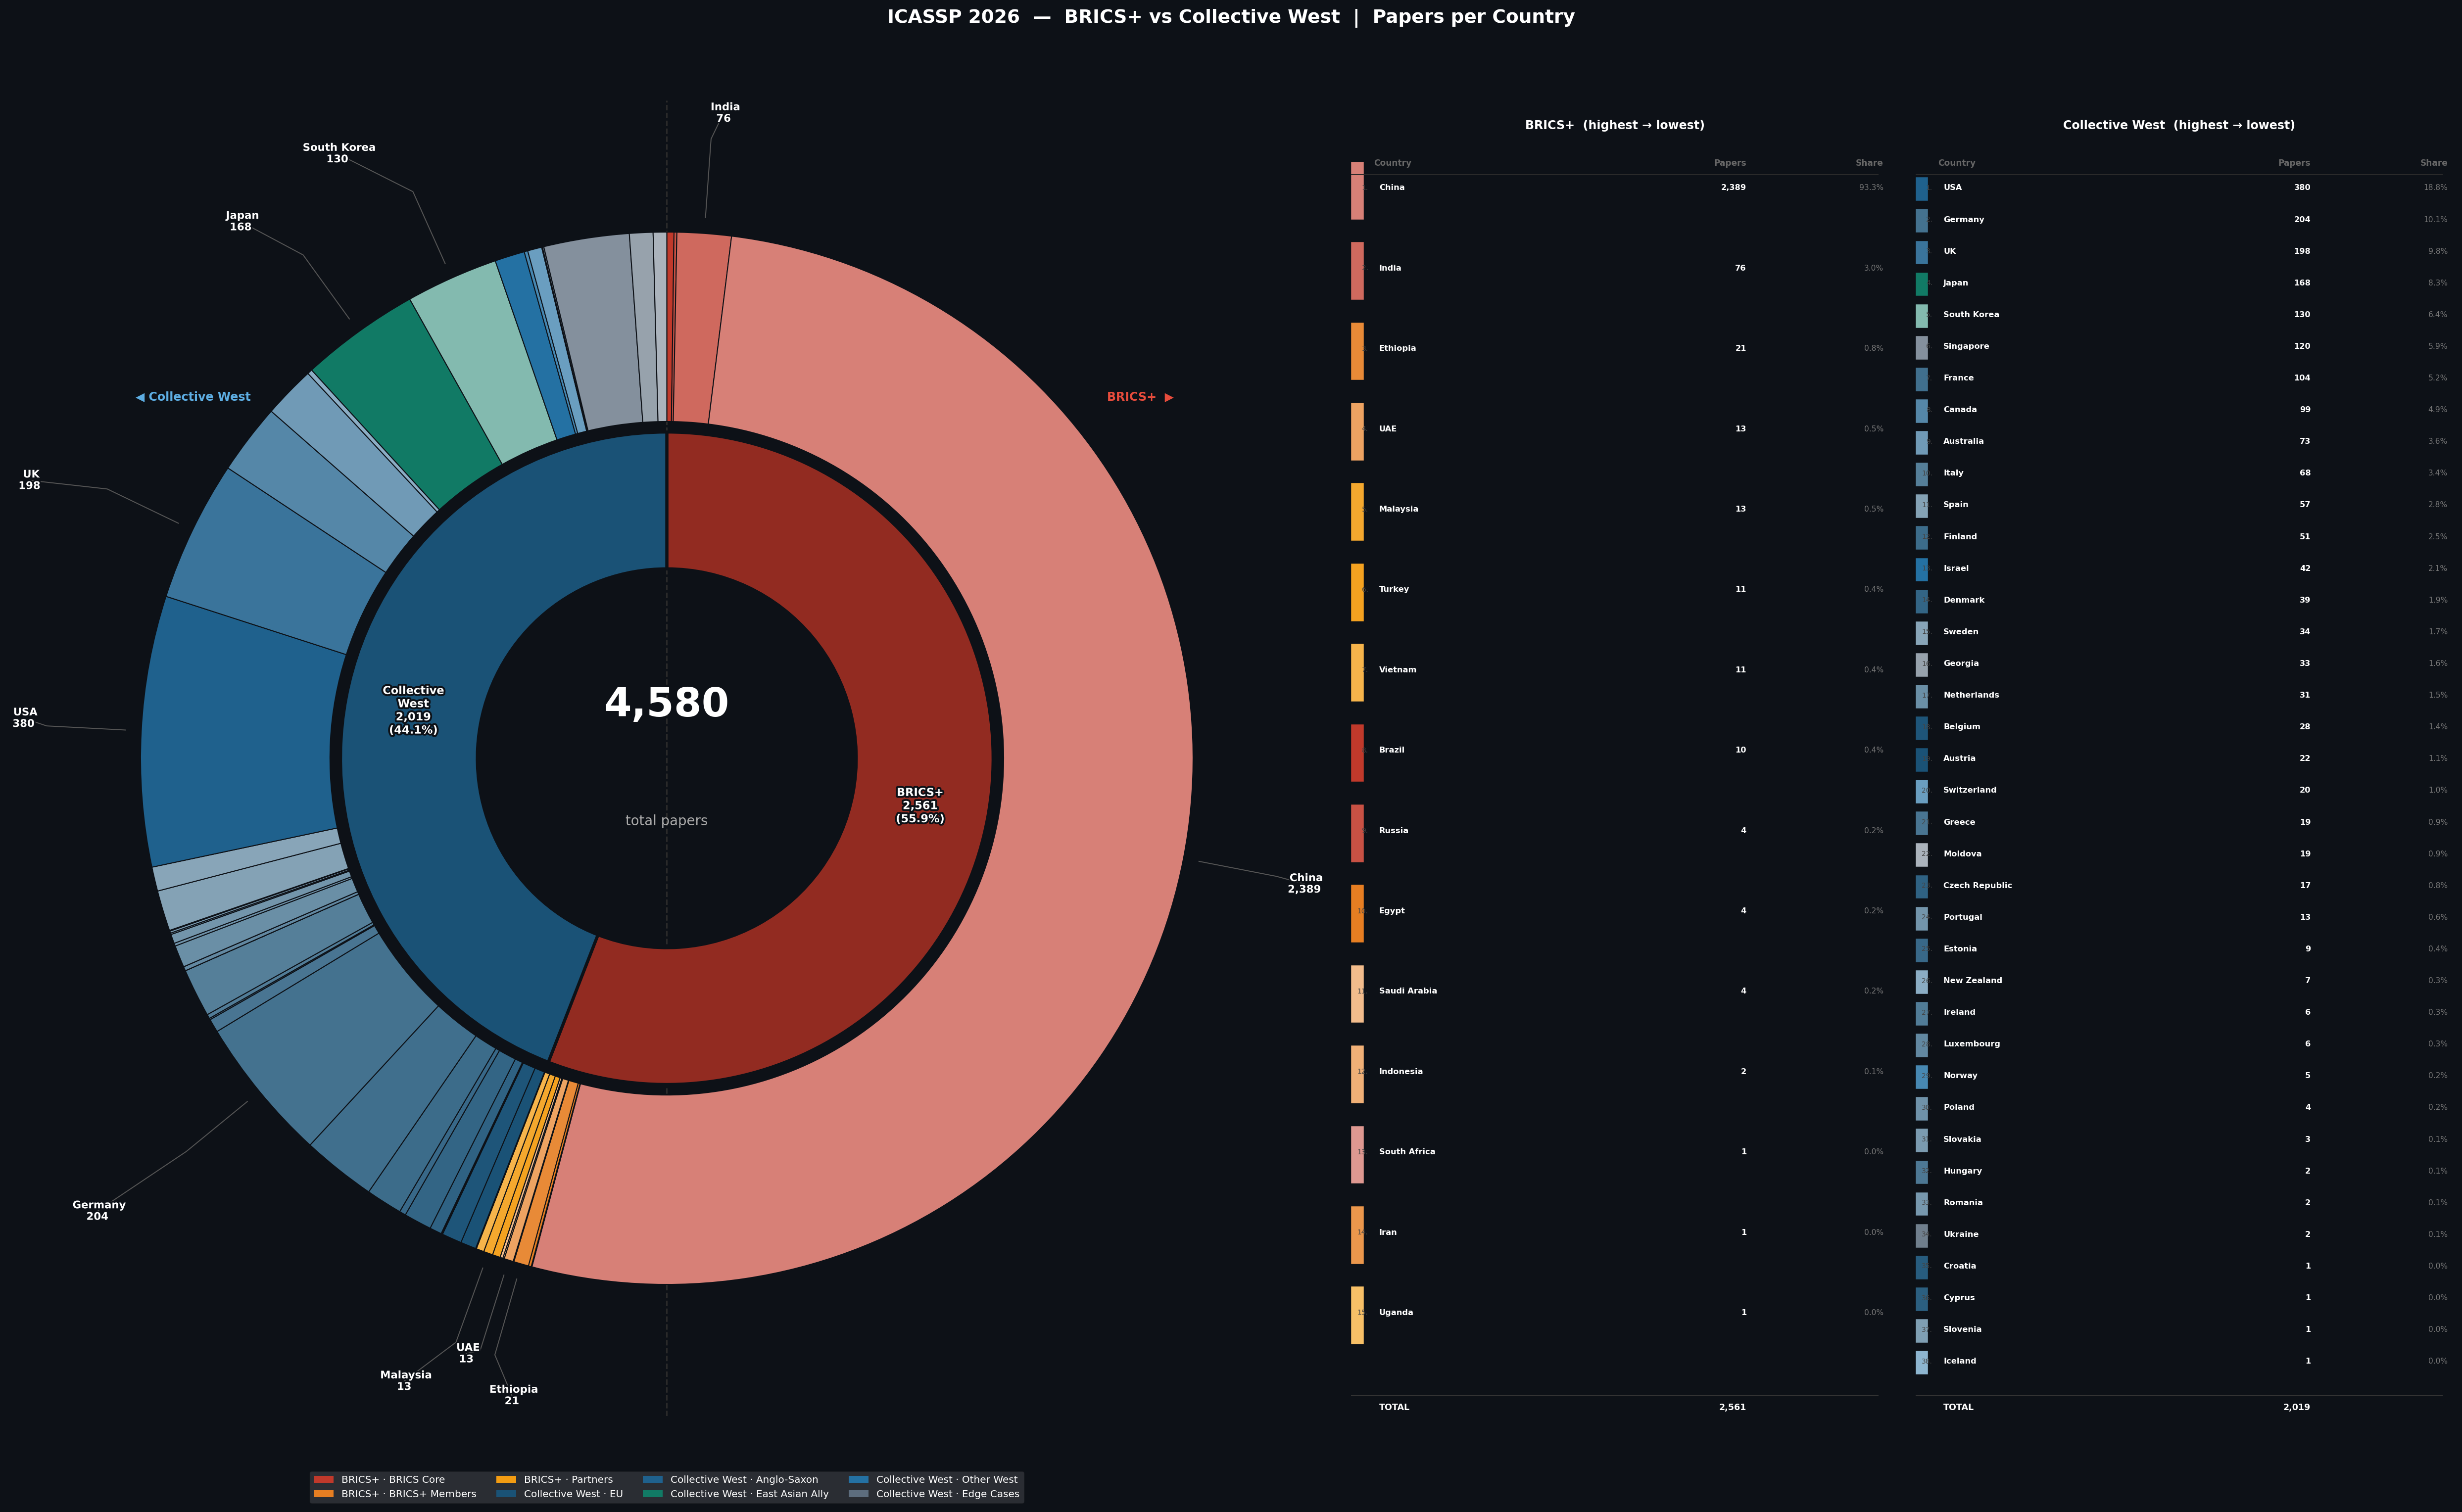

In [76]:
from IPython.display import Image as img
from IPython.display import display

# ── Notebook Media Rendering ─────────────────────────────────────────
# We leverage IPython's native display engine to inject rich media
# directly into the Jupyter/Colab frontend. This bypasses the need
# for raw HTML tags or external web browser tabs.
# ──────────────────────────────────────────────────────────────────────

# Define the local path or workspace filename of your targeted animation.
# NOTE: Make sure 'donut_brics_vs_west.png' is uploaded to your environment's
# filesystem (the folder icon on the left sidebar) before running this.
img_path = "donut_brics_vs_west.png"

# The Image class reads and structures the raw data bytes of the PNG,
# while display() explicitly renders the media framework inline within
# the cell's output zone.
display(img(filename=img_path))

In [77]:
# ── Optional: also save as PDF ─────────────────────────────────────────
# PdfPages allows saving one or more matplotlib figures into a single PDF file.
# This is useful for high-quality printing or including in reports.
with PdfPages("donut_brics_vs_west.pdf") as pdf:
    pdf.savefig(fig, bbox_inches="tight", facecolor=BG)
print("✅ Saved: donut_brics_vs_west.pdf")

# ── Download files from Colab ──────────────────────────────────────────
# google.colab.files is only available inside Colab — we catch the error
# gracefully so this cell still works in a local Jupyter environment.
try:
    from google.colab import files
    files.download("donut_brics_vs_west.png")
    files.download("donut_brics_vs_west.pdf")
except ModuleNotFoundError:
    print("(Not in Colab — find files in the current directory)")


✅ Saved: donut_brics_vs_west.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### 🏋️ Challenge 2 — Customise the donut chart

1. **Change the colour scheme:** Pick new base colours for one of the groups (e.g. make BRICS Core purple instead of red). Modify `BRICS_BASES` and re-run all the donut cells to see the result. What hex code gives a pure purple?

2. **Change the number of labelled countries:** Currently the code labels the top 5 per bloc. Change it to the top 3 or top 7. What problems appear with 7? Why does 3 feel like it loses information?

3. **Add a new country group:** Suppose you want to add "Central Asian" as a BRICS+ sub-group containing Kazakhstan, Uzbekistan, and Kyrgyzstan. You would need to: add entries to `_BRICS_DEF`, `BRICS_GROUPS`, and `BRICS_BASES`. What data would those entries contain?

4. **Explore the proportions:** China represents roughly 54% of all ICASSP 2026 papers in our dataset. Verify this using Python: `brics_2026["China"] / (brics_summary.sum() + west_summary.sum()) * 100`. Does the visual size of China's wedge match this number?


---
## Part 3 — 10-Year Animation & Interactive HTML

### 3.1 What this part does

The single-year donut chart is powerful, but data over time tells a richer story. This part shows how to:

1. Load all 11 years of acquired data (2016–2026) from CSV files
2. Render the donut chart for each year as an image frame
3. Assemble those frames into an animated GIF
4. Build a self-contained interactive HTML page with a year slider

### 3.2 Key new concepts

**GIF animation:** A GIF is a sequence of image frames played at a fixed rate. We render each frame as a PNG in memory (using `io.BytesIO`) and hand it to PIL to assemble into a GIF. No video codec or external tool needed.

**Self-contained HTML with embedded JSON:** We build the interactive visualisation by generating an HTML file that contains the entire dataset as a JavaScript variable (JSON). The Chart.js library (loaded from a CDN) then reads that variable to draw the chart. This technique — **data injection** — produces a single `.html` file that works in any browser with no server required.

### 3.3 Step 1: Load colour maps and multi-year data


#### Understanding `build_color_maps()`

We need a lookup dictionary mapping every country name to an RGB colour. This is the same colour information used in the static donut, but now structured as a flat dictionary for quick lookup: `BRICS_COLORS["China"]` → `(r, g, b)`.

The function builds this by iterating over every group in `BRICS_GROUPS` and `WEST_GROUPS`, generating gradient shades with `make_gradient()`, and zipping country names with their shades into dictionaries.

**Python concept: `rgb_to_hex()`**

Matplotlib stores colours internally as `(r, g, b)` float tuples. JavaScript (and HTML/CSS) uses hex strings like `"#c0392b"`. We need a conversion function for when we embed colours into the HTML. The format string `"{:02x}".format(...)` formats an integer as a zero-padded 2-digit hexadecimal string: `255 → "ff"`, `10 → "0a"`.


In [78]:
# ── Flat country lists (order matters — must match group order) ────────
ALL_BRICS = [c for cs in BRICS_GROUPS.values() for c in cs]
ALL_WEST  = [c for cs in WEST_GROUPS.values()  for c in cs]


def build_color_maps() -> tuple[dict, dict]:
    """
    Build flat country-to-colour lookup dictionaries for both blocs.

    Iterates over every group in ``BRICS_GROUPS`` and ``WEST_GROUPS``,
    generates a colour gradient for each group using ``make_gradient()``,
    and maps each country name to its assigned ``(r, g, b)`` tuple.

    Returns
    -------
    brics_map : dict
        ``{country_name: (r, g, b)}`` for all BRICS+ countries.
    west_map : dict
        ``{country_name: (r, g, b)}`` for all West countries.
    """
    brics_map: dict = {}
    west_map:  dict = {}

    for grp, countries in BRICS_GROUPS.items():
        cols = make_gradient(BRICS_BASES[grp], len(countries))
        for c, col in zip(countries, cols):
            brics_map[c] = col

    for grp, countries in WEST_GROUPS.items():
        cols = make_gradient(WEST_BASES[grp], len(countries))
        for c, col in zip(countries, cols):
            west_map[c] = col

    return brics_map, west_map


def rgb_to_hex(t: tuple) -> str:
    """
    Convert an ``(r, g, b)`` float tuple to a CSS hex colour string.

    Parameters
    ----------
    t : tuple of float
        Three floats in ``[0, 1]`` representing red, green, and blue.

    Returns
    -------
    str
        A hex string like ``"#1a5276"``.

    Examples
    --------
    >>> rgb_to_hex((0.10, 0.32, 0.47))
    '#1a5276'
    """
    return "#{:02x}{:02x}{:02x}".format(
        int(t[0] * 255), int(t[1] * 255), int(t[2] * 255)
    )


BRICS_COLORS, WEST_COLORS = build_color_maps()
print(f"BRICS_COLORS sample — China: {rgb_to_hex(BRICS_COLORS['China'])}")
print(f"WEST_COLORS  sample — USA:   {rgb_to_hex(WEST_COLORS['USA'])}")


BRICS_COLORS sample — China: #d68077
WEST_COLORS  sample — USA:   #1f618d


#### Understanding `load_year()`

For each year from 2016 to 2026, the scraper saves a CSV file. `load_year()` reads one of those files and returns two pandas Series — one per bloc — indexed by country name.

If the file for a year doesn't exist yet (because the acquisition hasn't been run for that year), the function returns Series of all zeros. This graceful fallback means all downstream code works even with partial data.

**Key pandas operations used here:**

- `df[df["bloc"] == "BRICS+"]` — boolean indexing: filters rows where the `bloc` column equals the string `"BRICS+"`. This is one of the most commonly used pandas operations.
- `.set_index("country")["papers"]` — sets the `country` column as the row index and selects the `papers` column, producing a Series.
- `.get(c, 0)` — looks up a country in the Series; returns 0 if the country is missing (avoids `KeyError`).


In [79]:
def load_year(year: int) -> tuple[pd.Series, pd.Series]:
    """
    Load the CSV for a given ICASSP year and return per-bloc paper count Series.

    If the file does not exist (year not yet acquired), returns two Series of
    zeros so that downstream code can run without modification.

    Parameters
    ----------
    year : int
        The conference year to load, e.g. ``2026``.

    Returns
    -------
    brics_series : pandas.Series
        Paper counts for all BRICS+ countries, indexed by country name.
    west_series : pandas.Series
        Paper counts for all West countries, indexed by country name.

    Notes
    -----
    Countries present in ``ALL_BRICS`` / ``ALL_WEST`` but absent from the CSV
    are filled with ``0`` via the dict comprehension's ``.get()`` call.\n    """
    path = os.path.join(DATA_DIR, f"summary_icassp_{year}.csv")

    if not os.path.exists(path):
        # Graceful fallback: return all-zeros Series
        brics = pd.Series({c: 0 for c in ALL_BRICS}, name="papers")
        west  = pd.Series({c: 0 for c in ALL_WEST},  name="papers")
        return brics, west

    df = pd.read_csv(path)

    # Boolean indexing: select only BRICS+ rows, set country as index
    brics_df = df[df["bloc"] == "BRICS+"].set_index("country")["papers"]
    west_df  = df[df["bloc"] == "West"].set_index("country")["papers"]

    # Build Series with all expected countries, filling missing ones with 0
    brics = pd.Series({c: int(brics_df.get(c, 0)) for c in ALL_BRICS},
                      name="papers")
    west  = pd.Series({c: int(west_df.get(c, 0))  for c in ALL_WEST},
                      name="papers")
    return brics, west


# Load all years into a dictionary: {year: (brics_series, west_series)}
all_data = {}
for y in YEARS:
    all_data[y] = load_year(y)

years_with_data  = [y for y in YEARS if all_data[y][0].sum() + all_data[y][1].sum() > 0]
years_zeros_only = [y for y in YEARS if y not in years_with_data]
print(f"Years with data:  {years_with_data}")
print(f"Years all-zero:   {years_zeros_only}  (not yet acquired — will show placeholder)")


Years with data:  [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Years all-zero:   []  (not yet acquired — will show placeholder)


### 3.4 Step 2: The `draw_frame` function

For the GIF, we need to draw the donut chart 11 times (once per year). Rather than copy-pasting all the drawing code 11 times, we encapsulate it in a **function** that accepts a year and its data as parameters.

This is the **DRY principle** (Don't Repeat Yourself) in action. Any time you find yourself copy-pasting code and changing one small thing each time, that is a signal to write a function instead. Functions:
- Make the code shorter and easier to read
- Mean that a bug only needs to be fixed in one place
- Allow you to call the same logic with different inputs

`draw_frame()` is structurally identical to the static donut code from Part 2, but:
- It accepts data as parameters (instead of using module-level variables)
- It begins by clearing the axes (`ax.clear()`) so each frame starts fresh
- It labels only the **top 5 per bloc** (same as the static chart)
- The inner ring uses **real bloc totals**, not forced halves


In [80]:
def draw_frame(
    year: int,
    brics_summary: pd.Series,
    west_summary: pd.Series,
    ax_donut,
    ax_brics,
    ax_west,
) -> None:
    """
    Clear the given axes and render a complete donut chart for ``year``.

    Called once per year during GIF frame generation. Uses real paper count
    proportions for both rings — no artificial scaling is applied.

    Parameters
    ----------
    year : int
        The conference year being rendered (displayed in the centre hole).
    brics_summary : pandas.Series
        Paper counts for BRICS+ countries indexed by country name.
    west_summary : pandas.Series
        Paper counts for West countries indexed by country name.
    ax_donut : matplotlib.axes.Axes
        Axes for the main donut chart.
    ax_brics : matplotlib.axes.Axes
        Axes for the BRICS+ companion table.
    ax_west : matplotlib.axes.Axes
        Axes for the West companion table.
    """
    # Clear all axes from the previous frame
    for ax in (ax_donut, ax_brics, ax_west):
        ax.clear()
        ax.set_facecolor(BG)
    ax_donut.set_aspect("equal")

    # Build per-country value and colour lists in group order
    brics_vals = [int(brics_summary.get(c, 0)) for c in ALL_BRICS]
    west_vals  = [int(west_summary.get(c, 0))  for c in ALL_WEST]
    brics_cols = [BRICS_COLORS[c] for c in ALL_BRICS]
    west_cols  = [WEST_COLORS[c]  for c in ALL_WEST]

    brics_total = sum(brics_vals)
    west_total  = sum(west_vals)
    total_all   = brics_total + west_total

    if total_all == 0:
        ax_donut.text(0, 0, f"No data\nfor {year}",
                      ha="center", va="center", fontsize=18, color="white")
        return

    # Combine blocs into single parallel lists for the outer ring
    outer_values  = brics_vals + west_vals    # Real counts — no scaling
    outer_colours = brics_cols + west_cols
    outer_labels  = ALL_BRICS  + ALL_WEST

    # Draw outer ring: one wedge per country, real proportions
    wedges_outer, _ = ax_donut.pie(
        outer_values, radius=1.0, colors=outer_colours,
        startangle=90, counterclock=False,
        wedgeprops=dict(width=0.36, edgecolor=BG, linewidth=0.8),
    )
    # Draw inner ring: one segment per bloc, real proportions
    wedges_inner, _ = ax_donut.pie(
        [brics_total, west_total],     # Real totals — no forced half/half
        radius=0.62,
        colors=["#922b21", "#1a5276"],
        startangle=90, counterclock=False,
        wedgeprops=dict(width=0.26, edgecolor=BG, linewidth=2.5),
    )

    # Centre: show year and total paper count
    ax_donut.text(0,  0.16, str(year), ha="center", va="center",
                  fontsize=26, fontweight="bold", color="white")
    ax_donut.text(0, -0.04, f"{total_all:,} papers", ha="center", va="center",
                  fontsize=10, color="#aaaaaa")

    # Inner ring labels
    for wedge, lbl, val in zip(wedges_inner,
                                ["BRICS+", "Collective\nWest"],
                                [brics_total, west_total]):
        angle = (wedge.theta1 + wedge.theta2) / 2
        rad   = np.deg2rad(angle)
        x = 0.49 * np.cos(rad)
        y = 0.49 * np.sin(rad)
        pct = val / total_all * 100
        ax_donut.text(x, y, f"{lbl}\n{val:,}\n({pct:.1f}%)",
                      ha="center", va="center", fontsize=8,
                      fontweight="bold", color="white",
                      path_effects=[pe.withStroke(linewidth=3, foreground=BG)])

    # Top 5 per bloc — outer ring labels only
    top5_b = set(
        sorted([c for c in ALL_BRICS if int(brics_summary.get(c, 0)) > 0],
               key=lambda c: int(brics_summary.get(c, 0)), reverse=True)[:5]
    )
    top5_w = set(
        sorted([c for c in ALL_WEST if int(west_summary.get(c, 0)) > 0],
               key=lambda c: int(west_summary.get(c, 0)), reverse=True)[:5]
    )
    label_set = top5_b | top5_w

    # ========================================================================
    # FIXED: Use symmetric radii to preserve angle-to-coordinate mapping
    # Collect text objects for adjustText to handle label overlap avoidance
    # ========================================================================
    ARROW_RADIUS = 0.70      # Distance from center to arrow anchor point on wedge
    LABEL_RADIUS = 1.00      # Distance from center to label text (initial position)

    texts = []  # Collect annotation objects for adjustText

    for wedge, lbl, raw_val in zip(wedges_outer, outer_labels, outer_values):
        if lbl not in label_set or raw_val == 0:
            continue

        angle = (wedge.theta1 + wedge.theta2) / 2
        rad   = np.deg2rad(angle)

        # Use SAME radius for both x and y to preserve the angle direction
        # This ensures arrows point to the correct wedge
        xa = ARROW_RADIUS * np.cos(rad)
        ya = ARROW_RADIUS * np.sin(rad)
        xt = LABEL_RADIUS * np.cos(rad)
        yt = LABEL_RADIUS * np.sin(rad)

        # Determine text alignment based on position
        ha = "center" if abs(xt) < 0.15 else ("left" if xt > 0 else "right")

        text = ax_donut.annotate(
            f"{lbl}\n{raw_val:,}",
            xy=(xa, ya), xytext=(xt, yt),
            fontsize=8, color="white", ha=ha, va="center", fontweight="bold",
            arrowprops=dict(arrowstyle="-", color="#555555", lw=0.8),
            path_effects=[pe.withStroke(linewidth=2.5, foreground=BG)],
        )
        texts.append(text)  # Collect for overlap avoidance

    # Automatically adjust label positions to avoid overlaps
    # Only move text positions, don't let adjustText modify the arrows
    if texts:
        adjust_text(
            texts,
            ax=ax_donut,
            only_move={'points': 'xy', 'texts': 'xy'},  # Only move positions, keep arrows intact
            expand_points=(1.5, 1.5),  # Expand collision box around labels
            expand_text=(1.2, 1.2),    # Expand text bounds slightly
            force_points=(0.5, 0.5),   # Force away from the pie
            lim=200,                   # Max iterations
        )

    # Divider line and bloc headings
    ax_donut.axvline(0, color="#2a2a2a", lw=1.2, ls="--", zorder=0)
    ax_donut.text(0.85, 1.58, "BRICS+  ▶", fontsize=9,
                  color="#e74c3c", fontweight="bold", ha="center")
    ax_donut.text( -0.85, 1.58, "◀  Collective West", fontsize=9,
                  color="#5dade2", fontweight="bold", ha="center")

    # Legend
    legend_items  = [Patch(facecolor=c, label=f"BRICS+ · {g}")
                     for g, c in BRICS_BASES.items()]
    legend_items += [Patch(facecolor=c, label=f"West · {g}")
                     for g, c in WEST_BASES.items()]
    ax_donut.legend(handles=legend_items, loc="lower center",
                    bbox_to_anchor=(0.5, -0.07), ncol=4, fontsize=7.5,
                    framealpha=0.12, labelcolor="white", edgecolor="#333333")

    # Companion tables — reuse draw_table from Part 2
    def draw_t(ax, title, summary, color_map, all_countries):
        """Draw a compact ranked table; wraps draw_table with group-filtered data."""
        sub = pd.Series({c: int(summary.get(c, 0)) for c in all_countries},
                        name="papers")
        draw_table(ax, title, sub, color_map)

    draw_t(ax_brics, "BRICS+  ↓ by papers",         brics_summary, BRICS_COLORS, ALL_BRICS)
    draw_t(ax_west,  "Collective West  ↓ by papers", west_summary,  WEST_COLORS,  ALL_WEST)


print("✅ draw_frame() fixed and defined.")

✅ draw_frame() fixed and defined.


### 3.5 Step 3: Render GIF frames

For each year, we:
1. Create a fresh matplotlib figure
2. Call `draw_frame()` to populate it
3. Save it to a `BytesIO` buffer (in-memory file) as PNG
4. Convert the buffer to a PIL Image and append it to a list
5. Close the figure to free memory

**Why `io.BytesIO` instead of saving to disk?** Saving 11 temporary PNG files to disk and reading them back would work, but it is slower and clutters the working directory. `BytesIO` lets us treat a chunk of memory as if it were a file — matplotlib writes to it and PIL reads from it, without ever touching the filesystem. `buf.seek(0)` resets the "read head" to the beginning of the buffer after matplotlib writes to it.

**Why `plt.close(fig)`?** Each call to `plt.figure()` allocates memory. If you don't close figures, you accumulate dozens of open figure objects and eventually run out of memory. Always close figures you no longer need.


In [81]:
# ── Generate one GIF frame per year ────────────────────────────────────
print("Generating GIF frames (this may take a minute)...")
frames = []

for year in YEARS:
    brics_s, west_s = all_data[year]

    # Create a fresh figure for this frame
    fig = plt.figure(figsize=(24, 15), facecolor=BG)
    gs  = gridspec.GridSpec(1, 3, width_ratios=[2.4, 1, 1],
                            wspace=0.02, left=0.01, right=0.99,
                            top=0.91, bottom=0.05)
    ax_donut = fig.add_subplot(gs[0])
    ax_brics = fig.add_subplot(gs[1])
    ax_west  = fig.add_subplot(gs[2])

    draw_frame(year, brics_s, west_s, ax_donut, ax_brics, ax_west)

    fig.suptitle(
        f"ICASSP {year}  —  BRICS+ vs Collective West  |  Papers per Country",
        fontsize=13, fontweight="bold", color="white", y=0.97,
    )

    # Save figure to an in-memory buffer (not to disk)
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=110, bbox_inches="tight", facecolor=BG)
    plt.close(fig)   # Free the figure object from memory

    buf.seek(0)      # Reset buffer read position to the start
    frames.append(Image.open(buf).convert("RGB"))
    print(f"  ✅ Frame {year} done")

# Ensure all frames are the same dimensions (GIF requirement)
w, h = frames[0].size
frames = [f.resize((w, h), Image.LANCZOS) for f in frames]
print(f"\nAll {len(frames)} frames rendered at {w}×{h} px.")


Generating GIF frames (this may take a minute)...
  ✅ Frame 2016 done
  ✅ Frame 2017 done
  ✅ Frame 2018 done
  ✅ Frame 2019 done
  ✅ Frame 2020 done
  ✅ Frame 2021 done
  ✅ Frame 2022 done
  ✅ Frame 2023 done
  ✅ Frame 2024 done
  ✅ Frame 2025 done
  ✅ Frame 2026 done

All 11 frames rendered at 2609×1701 px.


In [82]:
# ── Save the animated GIF ─────────────────────────────────────────────
# duration: milliseconds to display each frame
# loop=0: loop forever (standard for animated GIFs)
durations       = [2000] * len(frames)
durations[-1]   = 4000   # Hold the final frame longer so viewers can read it

frames[0].save(
    "icassp_10year.gif",
    save_all=True,            # Include all frames (not just the first)
    append_images=frames[1:], # The remaining frames
    duration=durations,
    loop=0,
    optimize=False,           # optimize=True can sometimes corrupt multi-frame GIFs
)
print("✅ Saved: icassp_10year.gif")


✅ Saved: icassp_10year.gif


### Step 3a: Rendering Animations in Jupyter Notebooks

Static charts are excellent for deep-dive analysis, but they fail to capture the fluid progression of time. To truly understand how publication metrics, country rankings, or topical trends have shifted over the last decade, we need a way to look at our data dynamically.

This step introduces how to embed and auto-play an animated GIF (`icassp_10year.gif`) directly within our notebook execution environment.

---

#### ⚙️ How Inline Media Rendering Works

Standard Python scripts cannot display visual assets because terminal environments lack a graphical user interface (GUI) engine. However, environments like Google Colab and Jupyter Notebooks are built on top of web browser technologies.

To bridge this gap, we utilize the **IPython kernel's native display architecture**:

* **The `Image` Class:** This object acts as a data decoder. Instead of treating the GIF as a raw binary file, it parses the image layers, configurations, and frame delays, formatting them into an asset the browser engine can understand.
* **The `display()` Function:** This is the execution routine that pushes the processed asset directly into the cell's output pipeline, telling the browser to render and loop the animation inline.



---

#### ⚠️ Critical Setup Workspace Warning

Before executing the cell below, the target GIF must exist within the active workspace filesystem.

If you are running this notebook in **Google Colab**, look at the left sidebar interface:
1. Click on the **Folder Icon** (`📁`) to open the file explorer.
2. Drag and drop your `icassp_10year.gif` directly into that pane.
3. If the file is not there, Python will halt execution and throw a `FileNotFoundError`.

---

#### 💡 Alternative: Native Markdown Rendering
If you want to place the animation permanently within an explanatory text block rather than requiring a user to execute a Python code cell, you can skip the code entirely and use raw Markdown syntax:

```markdown
![ICASSP 10-Year Trends](icassp_10year.gif)

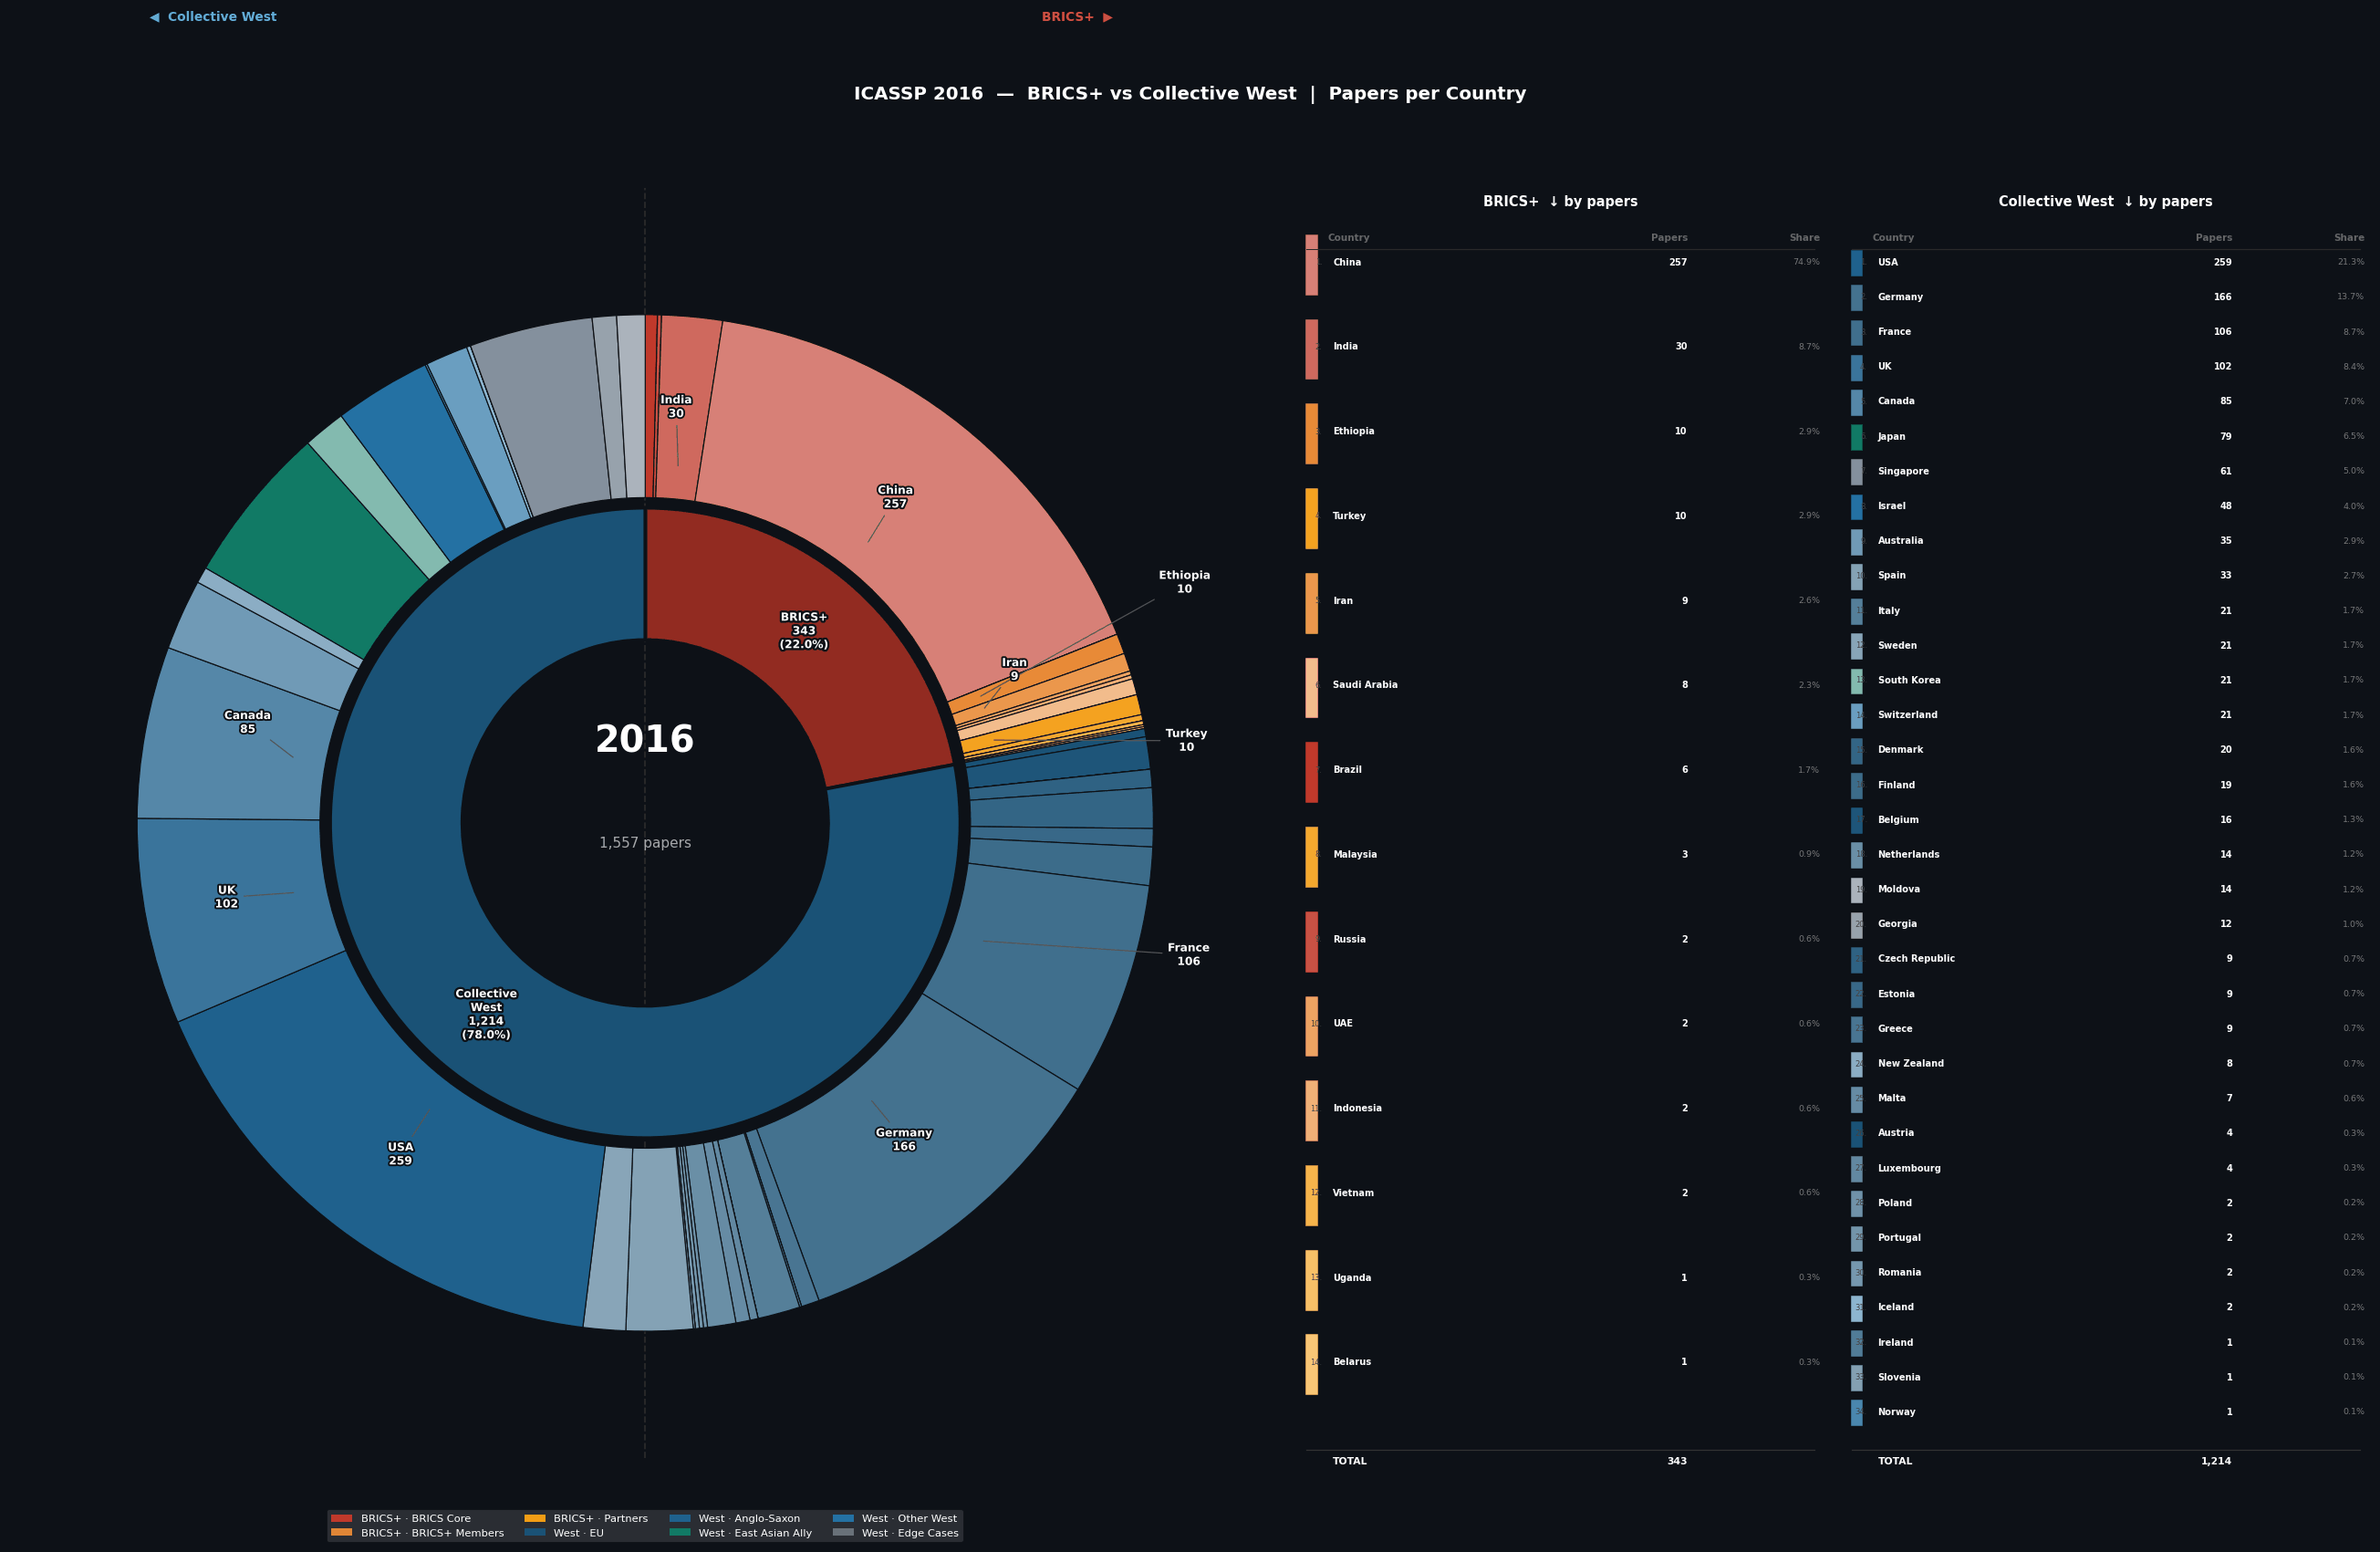

In [83]:
from IPython.display import Image as img
from IPython.display import display

# ── Notebook Media Rendering ─────────────────────────────────────────
# We leverage IPython's native display engine to inject rich media
# directly into the Jupyter/Colab frontend. This bypasses the need
# for raw HTML tags or external web browser tabs.
# ──────────────────────────────────────────────────────────────────────

# Define the local path or workspace filename of your targeted animation.
# NOTE: Make sure 'icassp_10year.gif' is uploaded to your environment's
# filesystem (the folder icon on the left sidebar) before running this.
gif_path = "icassp_10year.gif"

# The Image class reads and structures the raw data bytes of the GIF,
# while display() explicitly renders the media framework inline within
# the cell's output zone.
display(img(filename=gif_path))

### 3.6 Step 4: Build the interactive HTML

Now we build an HTML file that lets the viewer drag a slider to see any year's data. The approach:

1. **Serialise all data to JSON** using `json.dumps()` — this converts our Python dictionaries into a JSON string
2. **Embed that JSON into an HTML f-string template** — the JSON string becomes a JavaScript variable on the page
3. **Chart.js** (loaded from a CDN) reads that variable and draws the donut chart
4. **A `<input type="range">` slider** — when the user drags it, JavaScript calls `update()` which redraws the chart

This technique — **data injection** into a static HTML template — is exactly how tools like Plotly and Bokeh generate self-contained interactive HTML files. You are building the same architecture from scratch.

**f-string escaping:** Inside Python f-strings, `{{` and `}}` produce literal `{` and `}` characters (because `{...}` is the interpolation syntax). JavaScript uses `{` and `}` extensively, so every JavaScript brace in the template must be doubled.


### 🌉 Bridge: What are we about to build?

Before writing any code, let's understand the **big picture architecture** of the interactive HTML file we are about to generate.

Python is going to act like a **printing press**. It will print out a complete website — a single `.html` file — that contains everything the browser needs to be interactive. Here is a map of that file:

```
icassp_10year.html
│
├── <head>
│   ├── <meta>  — page settings (character encoding, viewport)
│   └── <script src="chart.js">  — loads the Chart.js library from the internet (CDN)
│
├── <style>  — CSS: visual styling (colours, fonts, layout)
│   └── All rules use CSS custom properties (--bg, --text, etc.)
│
└── <body>  — visible content
    ├── <h1>  — page title
    ├── <div class="stats">  — BRICS+ total | West total | Grand total
    ├── <div id="yearTicks">  — row of clickable year numbers
    ├── <input type="range">  — THE SLIDER (this is the interactive element)
    ├── <canvas id="donutChart">  — Chart.js draws the donut here
    ├── <div class="tables">  — two ranked country tables side by side
    └── <script>  — JavaScript: the brain of the page
        ├── const DATA = { ... };   ← ALL OUR PYTHON DATA IS HERE (as JSON)
        ├── function update(year)   ← called every time slider moves
        │   ├── updates the chart
        │   ├── updates the tables
        │   └── updates the stat numbers
        └── slider.addEventListener(...)  ← connects slider to update()
```

**The data flow:**
```
Python dict (payload)
      ↓  json.dumps()
JSON string
      ↓  embedded in f-string template
HTML file saved to disk
      ↓  user opens in browser
JavaScript reads DATA constant
      ↓  user drags slider
update(year) called → chart redraws with new year's data
```

> This is the exact same architecture used by tools like Plotly, Vega-Lite, and Bokeh — they all generate self-contained HTML with embedded JSON data. You are building it by hand, which means you understand every layer.

---

### ⚡ JavaScript Micro-Lesson: 5 Things You Need to Know

The `<script>` block inside the HTML uses JavaScript. You do not need to become a JavaScript expert, but these five patterns appear repeatedly and are worth understanding.

**1. Variables and constants**
```javascript
const name = "China";       // const: value never changes
let count = 0;              // let: value can change later
```

**2. Arrow functions** — the `=>` symbol
```javascript
// Old style:
function add(a, b) { return a + b; }

// Arrow function (same thing, shorter):
const add = (a, b) => a + b;

// Used in this notebook:
.map(item => item.value)   // apply to every item in an array
.filter(item => item > 0)  // keep only items > 0
```

**3. `document.getElementById()`** — like a Python dictionary lookup
```javascript
// Find the HTML element with id="yearLabel" and change its text
document.getElementById('yearLabel').textContent = 2026;

// Python equivalent:
page_elements['yearLabel']['text'] = 2026
```

**4. Template literals** — JavaScript's version of f-strings
```javascript
const country = "China";
const count = 2387;
const msg = `${country} had ${count} papers`;  // backticks, ${} syntax
// → "China had 2387 papers"
```

**5. `JSON.stringify()` and parsing** — the bridge between Python and JS
```javascript
// Python: json.dumps({"China": 2387})  → '{"China": 2387}'
// JavaScript reads this string as a live object:
const DATA = {"China": 2387};   // Python injected this via json.dumps()
console.log(DATA["China"]);     // → 2387
```

> **The most important line in the whole HTML file:**
> ```javascript
> const DATA = {json.dumps(payload)};
> ```
> This is where Python hands off the entire 11-year dataset to JavaScript. Everything the browser draws comes from this one line.

---

### 🔍 Inspect the payload before embedding it

The next cell builds the Python `payload` dictionary and prints a sample entry so you can see exactly what structure JavaScript will receive.


In [84]:
# ── Prepare JSON data payload ─────────────────────────────────────────
# Structure: {year: {"brics": {country: count, ...}, "west": {...}}}
# json.dumps() converts Python dicts/lists to a JSON string.
payload = {}
for year in YEARS:
    brics_s, west_s = all_data[year]
    payload[year] = {
        "brics": {c: int(brics_s.get(c, 0)) for c in ALL_BRICS},
        "west":  {c: int(west_s.get(c, 0))  for c in ALL_WEST},
    }

# Convert colour tuples to hex strings for use in CSS/JavaScript
brics_colors_js = {c: rgb_to_hex(BRICS_COLORS[c]) for c in ALL_BRICS}
west_colors_js  = {c: rgb_to_hex(WEST_COLORS[c])  for c in ALL_WEST}

brics_groups_js = {g: cs for g, cs in BRICS_GROUPS.items()}
west_groups_js  = {g: cs for g, cs in WEST_GROUPS.items()}

# Pre-compute base colour dicts as hex strings.
# We do this here — outside the f-string — because dict comprehensions
# inside f-string {{ }} escapes cause a TypeError ("unhashable type: dict").
# By computing the values first and referencing simple variable names in the
# f-string, we avoid any brace-escaping ambiguity.
brics_bases_js = {
    g: rgb_to_hex(tuple(int(c[i:i+2], 16) / 255 for i in (1, 3, 5)))
    for g, c in BRICS_BASES.items()
}
west_bases_js = {
    g: rgb_to_hex(tuple(int(c[i:i+2], 16) / 255 for i in (1, 3, 5)))
    for g, c in WEST_BASES.items()
}

print("✅ JSON payload prepared.")
print(f"   Sample entry (2026, China): {payload[2026]['brics']['China']} papers")


✅ JSON payload prepared.
   Sample entry (2026, China): 2389 papers


### 3.6.1 The three languages inside the HTML file

The code cell below produces a single `.html` file. That file contains **three languages written together**:

| Language | Where | What it does |
|---|---|---|
| **HTML** | The tags: `<div>`, `<canvas>`, `<table>`, `<input>` | Defines the *structure* — what elements exist on the page |
| **CSS** | Inside `<style>...</style>` | Defines the *appearance* — colours, fonts, spacing, layout |
| **JavaScript** | Inside `<script>...</script>` | Defines the *behaviour* — what happens when the user interacts |

Think of it like a theatre production: HTML is the stage and props, CSS is the lighting and costumes, and JavaScript is the actors responding to the audience.

---

### 3.6.2 HTML elements and how they work

Every HTML element looks like this:

```html
<tagname attribute="value">Content goes here</tagname>
```

Some key tags used in our page:

| Tag | What it creates |
|---|---|
| `<div>` | A generic invisible box — the main building block for layout |
| `<h1>` | A top-level heading (large bold text) |
| `<p>` | A paragraph of text |
| `<canvas>` | A blank drawing surface — Chart.js draws the donut onto this |
| `<input type="range">` | The **slider** control |
| `<table>`, `<thead>`, `<tbody>`, `<tr>`, `<th>`, `<td>` | Table, header, body, row, header-cell, data-cell |
| `<span>` | Inline text wrapper, used here for colour swatches |
| `<strong>` | Bold text, used for the live paper-count numbers |

**The `id` attribute** gives an element a unique name. JavaScript uses `document.getElementById('yearLabel')` to find and modify elements by their `id`. If `id="yearLabel"` is on a `<span>`, then `document.getElementById('yearLabel').textContent = 2026` changes that span's text to `2026`.

**The `class` attribute** groups elements for CSS styling. `.stats strong {{ color: #fff }}` means "every `<strong>` element inside an element with class `stats`".

---

### 3.6.3 CSS — how visual styling works

A CSS rule has two parts:

```css
selector { property: value; }
```

- **Selector** — which element(s) to style. `body` = the whole page. `.stats` = all elements with class `stats`. `#donutChart` = the element with id `donutChart`. `*` = every element.
- **Property: value** — what to change. `color: #fff` = white text. `display: flex` = use flexbox layout.

**The Box Model — why `box-sizing: border-box` matters:**

Every HTML element is a box. By default, `width` only counts the content — padding and border are added on top. This leads to surprises: a `div` set to `width: 100%` with `padding: 20px` ends up wider than its parent. `box-sizing: border-box` fixes this by making `width` include everything, which is almost always what you want. Setting it on `*` (every element) applies it universally — this is the first line in virtually every professional web project.

```css
* {{ box-sizing: border-box; margin: 0; padding: 0; }}
/* margin: 0; padding: 0 — also removes all default browser spacing */
```

**Flexbox — the layout system:**

`display: flex` turns an element into a "flex container". Its children (flex items) are arranged along a main axis. Key properties:

```css
.container {{
  display: flex;              /* activate flexbox */
  flex-direction: column;    /* stack children vertically (default: row = horizontal) */
  align-items: center;       /* centre children on the cross-axis */
  gap: 14px;                 /* space between children */
}}
```

This is how we centre the page content and arrange the slider and year-label side by side.

**CSS custom properties (variables) — using `--name`:**

The trajectory HTML (Section 4.7) uses CSS variables. They are defined on `:root` (the root element, effectively the whole page) and referenced with `var(--name)`:

```css
:root {{ --bg: #0d1117; --text: #c9d1d9; }}
body  {{ background: var(--bg); color: var(--text); }}
```

Changing `--bg` in one place updates the background everywhere. This is the professional way to manage a consistent colour scheme.

**Transitions — making things animate smoothly:**

```css
input[type=range] {{ accent-color: #5dade2; }}
/* accent-color sets the colour of native browser controls like sliders */

#yearTicks span {{ transition: color .15s; }}
/* transition: property duration — when 'color' changes, animate the change
   over 0.15 seconds instead of snapping instantly */
```

---

### 3.6.4 JavaScript inside the browser — the six patterns you need

JavaScript is the only programming language that runs natively inside web browsers. Here are the six patterns that appear in our `<script>` block, each explained with a Python comparison.

**Pattern 1 — Variables**
```javascript
const name = "China";   // const: fixed value, like Python's name = "China"
let count  = 0;         // let: changeable value, like Python's count = 0
// Note: avoid 'var' — it is the old style with confusing scoping rules
```

**Pattern 2 — Arrow functions** (JavaScript's version of Python lambdas, but more powerful)
```javascript
// Python:      lambda x: x * 2
// JavaScript:  x => x * 2

// With a body:
const add = (a, b) => {{
  return a + b;
}};

// Used in our code: .forEach, .map, .filter, .reduce all take arrow functions
countries.forEach(country => {{
  console.log(country);   // runs once for each country
}});
```

**Pattern 3 — DOM manipulation** (DOM = Document Object Model — the browser's representation of the HTML)
```javascript
// Find an element by its id="yearLabel" and read or change it
const el = document.getElementById('yearLabel');
el.textContent = 2026;         // change visible text
el.style.color = '#e74c3c';   // change a CSS property in JavaScript

// Create a new element and add it to the page
const div = document.createElement('div');
div.className = 'legend-item';   // same as class="legend-item" in HTML
div.innerHTML = '<span>China</span>';   // set inner HTML content
document.getElementById('legend').appendChild(div);   // add to page
```

**Pattern 4 — Template literals** (JavaScript's f-strings)
```javascript
const country = "China";
const count   = 2387;

// Old way (string concatenation):
const msg = " " + country + ": " + count + " papers";

// Template literal (use backticks, not quotes):
const msg = ` ${{country}}: ${{count}} papers`;
// → " China: 2387 papers"
// Note: in our Python f-string, ${{country}} becomes ${country} in the output
```

**Pattern 5 — Array methods** (like Python's list comprehensions and `map/filter/reduce`)
```javascript
const countries = ["China", "USA", "UK"];
const counts    = [2387, 374, 198];

// .map() — transform every element (like Python's [f(x) for x in xs])
const labels = countries.map(c => c.toUpperCase());
// → ["CHINA", "USA", "UK"]

// .filter() — keep only matching elements
const big = counts.filter(n => n > 200);
// → [2387, 374]

// .reduce() — collapse an array to a single value (like Python's sum())
const total = counts.reduce((accumulator, value) => accumulator + value, 0);
// → 2959
// The second argument (0) is the starting value of accumulator
```

**Pattern 6 — Event listeners** (how JavaScript responds to user actions)
```javascript
const slider = document.getElementById('yearSlider');

// When the user moves the slider, call update() with the new value
slider.addEventListener('input', () => {{
  update(slider.value);   // slider.value is the current year number
}});

// 'input' fires on every slider movement (smooth)
// 'change' fires only when the user lets go (chunky)
```

---

### 3.6.5 Chart.js — the library that draws the donut

Chart.js is a JavaScript library (loaded from a CDN — a Content Delivery Network — via the `<script src="...">` tag in the `<head>`). It draws interactive charts on a `<canvas>` element.

**Initialising the chart:**
```javascript
const ctx = document.getElementById('donutChart').getContext('2d');
// ctx = a 2D drawing context — the surface Chart.js will paint on

const chart = new Chart(ctx, {{
  type: 'doughnut',           // chart type: 'doughnut', 'line', 'bar', etc.
  data: {{
    labels: ['China', 'USA', ...],        // tooltip labels
    datasets: [
      {{
        data: [2387, 374, ...],           // values (proportions are computed automatically)
        backgroundColor: ['#c0392b', '#2e86c1', ...],   // slice colours
        borderColor: '#0d1117',           // gap colour between slices
        borderWidth: 1,
        weight: 2,                        // relative ring width (outer ring is 2×)
      }},
      {{
        data: [brics_total, west_total],  // inner ring: two segments only
        backgroundColor: ['#922b21', '#1a5276'],
        borderWidth: 3,
        weight: 1,                        // inner ring is thinner
      }},
    ],
  }},
  options: {{
    rotation: 90,             // start angle: 90° = top (12 o'clock)
    cutout: '38%',            // hole size: 38% of radius → creates the donut hole
    animation: {{ duration: 600, easing: 'easeInOutQuart' }},
    plugins: {{
      legend: {{ display: false }},   // we draw our own legend below the chart
      tooltip: {{ ... }},             // custom tooltip callback (see below)
    }},
  }},
}});
```

**Updating the chart when the slider moves:**
Instead of destroying and recreating the chart every time, we update only the `data` arrays and call `chart.update()`. Chart.js then smoothly animates to the new values.

```javascript
function updateChart(year) {{
  const {{outer, inner}} = buildDatasets(year);
  chart.data.datasets[0].data            = outer.data;
  chart.data.datasets[0].backgroundColor = outer.colors;
  chart.data.datasets[1].data            = inner.data;
  chart.update();   // triggers animation to new values
}}
```

---

### 3.6.6 How `buildDatasets(year)` works — the proportioning logic

This function is the mathematical heart of the chart. It reads from `DATA[year]` and produces the values Chart.js will use to size each wedge.

```javascript
function buildDatasets(year) {{
  const d        = DATA[year];             // {brics: {China: 2387, ...}, west: {...}}
  const bricsSum = ALL_BRICS.reduce((acc, country) => acc + (d.brics[country] || 0), 0);
  const westSum  = ALL_WEST.reduce( (acc, country) => acc + (d.west[country]  || 0), 0);
  const total    = bricsSum + westSum;

  const outerVals   = [];
  const outerColors = [];

  ALL_BRICS.forEach(country => {{
    // Divide by total then multiply by 1000 — scales to integers while
    // preserving the real proportion. Chart.js sizes wedges by relative
    // value, so 500/1000 and 250/1000 give a 2:1 ratio regardless of scale.
    outerVals.push(total > 0 ? (d.brics[country] || 0) / total * 1000 : 0);
    outerColors.push(BRICS_COLORS[country]);
  }});
  // same for ALL_WEST...

  return {{
    outer: {{ data: outerVals, colors: outerColors }},
    inner: {{ data: [bricsSum, westSum], colors: ['#922b21', '#1a5276'] }},
  }};
}}
```

**Why divide by total and multiply by 1000?** Chart.js sizes each wedge as a fraction of the *sum of all values in the dataset*. If we pass raw counts `[2387, 374, ...]`, Chart.js sums them all and computes each wedge's angle as `value / sum * 360°`. Dividing by `total` first and multiplying by 1000 is just a scaling trick to keep numbers in a comfortable integer range — the proportions are identical.

---

### 3.6.7 How `buildTable()` works — generating HTML from JavaScript

This function dynamically writes HTML `<tr>` rows into the page's `<tbody>` elements. It demonstrates the power of template literals for generating structured content:

```javascript
function buildTable(tbodyId, countries, countryData, colorMap) {{
  const tbody = document.getElementById(tbodyId);

  // Step 1: build array of [country, paperCount] pairs, filter zeros, sort descending
  const rows = countries
    .map(country => [country, countryData[country] || 0])   // pair up
    .filter(([country, count]) => count > 0)                 // drop zeros
    .sort((rowA, rowB) => rowB[1] - rowA[1]);               // sort by count, high first

  const grandTotal = rows.reduce((acc, [country, count]) => acc + count, 0);

  // Step 2: generate one <tr> per country using a template literal
  tbody.innerHTML = rows.map(([country, count], rank) => {{
    const percentage = (count / grandTotal * 100).toFixed(1);
    const color      = colorMap[country];
    return `
      <tr>
        <td><span class="swatch" style="background:${{color}}"></span></td>
        <td>${{rank + 1}}. ${{country}}</td>
        <td class="num">${{count.toLocaleString()}}</td>
        <td class="num">${{percentage}}%</td>
      </tr>`;
  }}).join('');    // .join('') concatenates all rows into one string, no separator

  // Step 3: append the total row
  tbody.innerHTML += `
    <tr class="total-row">
      <td></td><td>Total</td>
      <td class="num">${{grandTotal.toLocaleString()}}</td>
      <td class="num">100%</td>
    </tr>`;
}}
```

**Key JavaScript array method here:** `.map(...).join('')` transforms each element into an HTML string and then concatenates all the strings with no separator. This is the standard JavaScript idiom for generating repeated HTML — the equivalent of `"".join([f"<tr>...</tr>" for row in rows])` in Python.

---

### 3.6.8 The `update(year)` master function — how everything connects

`update()` is the function that ties the whole page together. It is called once at startup (to show 2016 data) and then called again every time the slider moves.

```
user drags slider
      │
      ▼
slider.addEventListener('input', () => update(slider.value))
      │
      ▼
update(year) {
  ① Set year label text          ← DOM manipulation
  ② Highlight active year tick   ← classList.toggle
  ③ updateStats(year)            ← recompute and display bloc totals
  ④ updateChart(year)            ← feed new data to Chart.js
  ⑤ buildTable('bricsTable', ...)← regenerate BRICS+ table HTML
  ⑥ buildTable('westTable', ...) ← regenerate West table HTML
}
```

This pattern — a single master update function that refreshes every part of the UI — is called a **render function**. It is the same architectural pattern used by React, Vue, and other frontend frameworks. By calling one function with the current state (the year), the entire page stays consistent.


In [85]:
# ── Build and save the interactive HTML file ──────────────────────────
#
# Python acts as a printing press here: it writes out a complete .html file
# that contains HTML, CSS, and JavaScript all in one string (an f-string).
#
# Every {{ and }} in the string below is Python's way of producing a literal
# { or } in the output — because a single {expr} would be evaluated as Python.
# So CSS like  { display: flex }  must be written  {{ display: flex }}  here.
# JavaScript like  function update(year) {  becomes  function update(year) {{
#
# Wherever you see {json.dumps(variable)}, Python evaluates that expression
# and inserts the result as a JSON string — this is how all our data gets
# embedded into the HTML file so the browser can read it.

html = f'''<!DOCTYPE html>
<!-- ═══════════════════════════════════════════════════════════════════
     DOCTYPE and <html>
     ═══════════════════════════════════════════════════════════════════
     <!DOCTYPE html> — tells the browser this is modern HTML5.
     Without it, older browsers enter "quirks mode" and render differently.
     lang="en" — declares the language for accessibility tools (screen readers).
-->
<html lang="en">

<!-- ═══════════════════════════════════════════════════════════════════
     <head> — metadata and resources (not visible on the page)
     ═══════════════════════════════════════════════════════════════════ -->
<head>

  <!-- charset="UTF-8" — tells the browser how to decode the file.
       UTF-8 supports all Unicode characters including accented letters,
       Chinese characters, emoji. Always set this first in <head>. -->
  <meta charset="UTF-8">

  <!-- viewport meta tag — essential for mobile responsiveness.
       width=device-width : use the real screen width (not a zoomed-out view)
       initial-scale=1.0  : don't zoom in or out on load -->\n  <meta name="viewport" content="width=device-width, initial-scale=1.0">\n\n  <title>ICASSP 2016–2026 — BRICS+ vs Collective West</title>\n\n  <!-- Load Chart.js from a CDN (Content Delivery Network).\n       A CDN is a globally distributed server network — the browser downloads\n       Chart.js from the nearest server, which is fast and free.\n       The browser executes this script before our <script> block runs,\n       so 'Chart' is available as a global constructor by the time we need it. -->\n  <script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.0/dist/chart.umd.min.js"></script>\n\n<!-- ═══════════════════════════════════════════════════════════════════\n     <style> — CSS rules that control the visual appearance\n     ═══════════════════════════════════════════════════════════════════\n     A CSS rule has the form:   selector {{ property: value; }}\n     The selector says WHICH elements to style.\n     The declarations say HOW to style them.\n-->\n<style>\n\n  /* ── Reset ────────────────────────────────────────────────────────\n     * means "every element on the page".\n     box-sizing: border-box — include padding and border inside the\n       declared width, so a div with width:100% + padding:20px doesn't
       overflow its container. This is the first rule in most stylesheets.
     margin: 0; padding: 0 — browsers add default spacing around headings,
       paragraphs, etc. We remove it all so our own spacing is predictable. */
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}

  /* ── Page body ────────────────────────────────────────────────────
     background: dark navy — the overall page background colour.
     color: #fff — default text colour (white). Child elements inherit this.
     font-family — fallback chain: try 'Segoe UI' first (Windows), then
       system-ui (the OS default), then the generic sans-serif family.
     min-height: 100vh — at least the full viewport height (vh = viewport height).
     display: flex; flex-direction: column — stack children vertically.
     align-items: center — centre all children horizontally.
     padding: 24px 16px — 24px top/bottom, 16px left/right breathing room. */
  body {{ background: #0d1117; color: #fff;
          font-family: 'Segoe UI', system-ui, sans-serif;
          min-height: 100vh; display: flex; flex-direction: column;
          align-items: center; padding: 24px 16px; }}

  /* ── Page heading ─────────────────────────────────────────────────
     font-size: 1.3rem — 1.3× the browser's root font size (usually 16px → 20.8px).\n       rem units are relative to the root, so they scale with browser font settings.\n     font-weight: 700 — bold (400 is normal, 700 is bold, 900 is black).\n     margin-bottom: 6px — small gap below the heading. */\n  h1 {{ font-size: 1.3rem; font-weight: 700; color: #fff;\n        text-align: center; margin-bottom: 6px; }}\n\n  /* ── Subtitle paragraph ───────────────────────────────────────────\n     Lighter grey colour and smaller text to visually de-emphasise. */\n  .subtitle {{ color: #888; font-size: 0.82rem;\n               margin-bottom: 20px; text-align: center; }}\n\n  /* ── Slider row — year label + range input side by side ──────────\n     display: flex — lays children out in a horizontal row (the default\n       flex-direction is 'row').\n     align-items: center — vertically centre the year label and slider.\n     gap: 14px — space between the flex children.\n     max-width: 700px — prevents it becoming too wide on large screens. */\n  .slider-wrap {{ display: flex; align-items: center; gap: 14px;\n                  margin-bottom: 18px; width: 100%; max-width: 700px; }}\n\n  /* ── The big year number displayed left of the slider ─────────────\n     font-size: 2rem — large text (32px at default settings).\n     min-width: 70px — reserves space so the layout doesn't shift when
       the number changes from e.g. "2016" to "2026" (same width). */
  .year-label {{ font-size: 2rem; font-weight: 800;
                 color: #fff; min-width: 70px; text-align: center; }}

  /* ── Range slider ─────────────────────────────────────────────────
     flex: 1 — take up all remaining horizontal space in the flex row.
     accent-color — CSS property that sets the colour of native browser
       form controls (checkboxes, radio buttons, range sliders) without
       needing to override platform styling manually. */
  input[type=range] {{ flex: 1; accent-color: #5dade2; }}

  /* ── Stats bar — BRICS+ total | West total | Grand total ──────────
     display: flex; gap: 24px — arrange the stat items horizontally
       with 24px gaps between them.
     font-size: 0.85rem; color: #aaa — small dimmed text for the labels. */
  .stats {{ display: flex; gap: 24px; margin-bottom: 16px;
            font-size: 0.85rem; color: #aaa; }}

  /* .stats strong targets <strong> elements inside .stats.
     These hold the live numbers that JavaScript updates. */
  .stats strong {{ color: #fff; font-size: 1rem; }}

  /* ── Chart canvas ─────────────────────────────────────────────────
     max-width / max-height cap the canvas size on large screens.
     Chart.js respects these constraints when it draws. */
  #donutChart {{ max-width: 520px; max-height: 520px; }}

  /* ── Companion tables ─────────────────────────────────────────────
     display: flex places the two table wrappers side by side.
     gap: 24px — horizontal space between them.
     max-width: 900px — prevent sprawling on ultra-wide screens. */
  .tables {{ display: flex; gap: 24px; margin-top: 20px;
             width: 100%; max-width: 900px; }}

  /* flex: 1 on each .table-wrap makes both tables share the available
     width equally, regardless of content. */
  .table-wrap {{ flex: 1; }}

  /* border-collapse: collapse — removes the default double border between
     adjacent table cells, giving a clean single-line grid. */
  table {{ width: 100%; border-collapse: collapse; font-size: 0.78rem; }}

  th {{ color: #555; font-weight: 600; padding: 4px 6px;
        border-bottom: 1px solid #1e2a38; text-align: left; }}
  td {{ padding: 3px 6px; }}

  /* .num — right-aligns number columns (Papers and Share). */
  .num {{ text-align: right; }}

  /* .swatch — a small colour square shown before each country name.
     display: inline-block — needed to apply width/height to an inline element.
     border-radius: 2px — slightly rounded corners. */
  .swatch {{ display: inline-block; width: 10px; height: 10px; border-radius: 2px; }}

  /* .total-row — the summary row at the bottom of each table. */
  .total-row td {{ border-top: 1px solid #333; font-weight: bold; }}

  .table-title {{ font-size: 0.85rem; font-weight: bold;
                  margin-bottom: 6px; padding: 4px 0; }}

  /* Bloc-specific heading colours. */
  .brics-col {{ color: #e74c3c; }}
  .west-col  {{ color: #5dade2; }}

  /* ── Colour legend ────────────────────────────────────────────────
     flex-wrap: wrap — items wrap to the next line if there isn't room,\n       preventing horizontal overflow on narrow screens. */\n  .legend {{ display: flex; flex-wrap: wrap; gap: 8px 20px;\n             margin-top: 16px; max-width: 900px; }}\n\n  .legend-item {{ display: flex; align-items: center;\n                  gap: 6px; font-size: 0.72rem; color: #aaa; }}\n\n  /* flex-shrink: 0 — prevent the swatch from being squished if the\n     surrounding container is too narrow. */\n  .legend-swatch {{ width: 12px; height: 12px; border-radius: 2px; flex-shrink: 0; }}\n\n  /* ── Year tick row — clickable year numbers above the slider ──────\n     justify-content: space-between — push first item left, last item right,\n       distributing the others evenly in between. */\n  #yearTicks {{ display: flex; justify-content: space-between;\n                width: 100%; max-width: 700px; margin-bottom: 4px; }}\n\n  /* cursor: pointer — shows a hand cursor on hover (signals clickability).\n     transition: color .15s — animate the colour change over 0.15 seconds\n       instead of snapping instantly. */\n  #yearTicks span {{ font-size: 0.68rem; color: #555; cursor: pointer;\n                     transition: color .15s; }}\n\n  /* #yearTicks span.active — the currently selected year tick.\n     Two classes on the same element: span must have BOTH 'active' AND\n     be a child of #yearTicks. JavaScript adds/removes 'active' via\n     classList.toggle(). */\n  #yearTicks span.active {{ color: #5dade2; font-weight: bold; }}\n\n</style>\n</head>\n\n<!-- ═══════════════════════════════════════════════════════════════════\n     <body> — the visible page content\n     ═══════════════════════════════════════════════════════════════════ -->\n<body>\n\n<!-- Page heading -->\n<h1>ICASSP 2016–2026 — BRICS+ vs Collective West</h1>\n<p class="subtitle">Papers per country &middot; drag the slider or click a year to change</p>\n\n<!-- Stats bar: four <strong> elements with id attributes so JavaScript\n     can find and update each number independently.\n     &nbsp; is an HTML entity for a non-breaking space (keeps | separators\n     from wrapping onto a new line on narrow screens).\n     The em dash &mdash; is a typographic long dash. -->\n<div class="stats">\n  BRICS+ <strong id="bricsTotal">—</strong> &nbsp;|&nbsp;\n  West <strong id="westTotal">—</strong> &nbsp;|&nbsp;\n  Total <strong id="grandTotal">—</strong> &nbsp;|&nbsp;\n  BRICS+ share <strong id="bricsShare">—</strong>\n</div>\n\n<!-- Year tick row — JavaScript will fill this with <span> elements,\n     one per year, that the user can click to jump to that year. -->\n<div id="yearTicks"></div>\n\n<!-- Slider row: the year label + the range input -->\n<div class="slider-wrap">\n  <!-- This span holds the currently selected year as visible text.\n       JavaScript updates its .textContent every time the slider moves. -->\n  <span class="year-label" id="yearLabel">2016</span>\n\n  <!-- <input type="range"> is the browser's native slider control.
       min / max / step / value are HTML attributes that set its behaviour.
       id="yearSlider" lets JavaScript attach an event listener to it. -->
  <input type="range" id="yearSlider" min="2016" max="2026" step="1" value="2016">
</div>

<!-- The canvas element is a blank drawing surface.
     Chart.js will draw the donut chart here using the 2D Canvas API.
     width and height set the canvas resolution in pixels. -->
<canvas id="donutChart" width="520" height="520"></canvas>

<!-- Two companion tables side by side — JavaScript will populate their
     <tbody> elements with <tr> rows based on the selected year's data. -->\n<div class="tables">\n  <div class="table-wrap">\n    <div class="table-title brics-col">BRICS+ Countries</div>\n    <table>\n      <thead>\n        <tr>\n          <th></th>          <!-- empty column for the colour swatch -->\n          <th>Country</th>\n          <th class="num">Papers</th>\n          <th class="num">Share</th>\n        </tr>\n      </thead>\n      <!-- id="bricsTable" — JavaScript targets this tbody to insert rows -->\n      <tbody id="bricsTable"></tbody>\n    </table>\n  </div>\n  <div class="table-wrap">\n    <div class="table-title west-col">Collective West</div>\n    <table>\n      <thead>\n        <tr>\n          <th></th>\n          <th>Country</th>\n          <th class="num">Papers</th>\n          <th class="num">Share</th>\n        </tr>\n      </thead>\n      <tbody id="westTable"></tbody>\n    </table>\n  </div>\n</div>\n\n<!-- Colour legend — JavaScript will fill this with one item per country group. -->\n<div class="legend" id="legend"></div>\n\n\n<!-- ═══════════════════════════════════════════════════════════════════\n     <script> — all the JavaScript that makes the page interactive\n     ═══════════════════════════════════════════════════════════════════\n     This block runs after the HTML above is parsed, so all elements\n     already exist in the DOM when the script executes.\n-->\n<script>\n\n// ── DATA INJECTION ───────────────────────────────────────────────────\n// This is where Python hands its data to JavaScript.\n// json.dumps(payload) converted the Python dict to a JSON string;\n// JavaScript reads it as a native object literal.\n//\n// DATA structure:\n//   {{ 2016: {{ brics: {{ China: 1200, India: 88, ... }},\n//              west:  {{ USA: 450, UK: 180, ... }} }},\n//      2017: {{ ... }}, ... }}\nconst DATA         = {json.dumps(payload)};\n\n// List of years: [2016, 2017, ..., 2026]\nconst YEARS        = {json.dumps(YEARS)};\n\n// Ordered lists of country names (order matches the chart wedge order)\nconst ALL_BRICS    = {json.dumps(ALL_BRICS)};\nconst ALL_WEST     = {json.dumps(ALL_WEST)};\n\n// Country → hex colour string:  {{ "China": "#c0392b", "India": "#d35400", ... }}\nconst BRICS_COLORS = {json.dumps(brics_colors_js)};\nconst WEST_COLORS  = {json.dumps(west_colors_js)};\n\n// Group → hex colour for the legend:  {{ "BRICS Core": "#c0392b", ... }}\nconst BRICS_BASES  = {json.dumps(brics_bases_js)};\nconst WEST_BASES   = {json.dumps(west_bases_js)};\n\n// Group → list of country names (used to build the legend)\nconst BRICS_GROUPS = {json.dumps(brics_groups_js)};\nconst WEST_GROUPS  = {json.dumps(west_groups_js)};\n\n\n// ── BUILD THE YEAR TICK ROW ──────────────────────────────────────────\n// For each year in YEARS, create a <span> element and append it to\n// the #yearTicks div. Clicking a span sets the slider and calls update().\n//\n// document.getElementById('yearTicks') — finds the <div id="yearTicks">\n// document.createElement('span')       — creates a new <span> (not yet on page)\n// s.dataset.year = y                   — stores the year as a data attribute;\n//   HTML: <span data-year="2016">\n// ticksEl.appendChild(s)              — adds the span to the page\nconst ticksEl = document.getElementById('yearTicks');\nYEARS.forEach(y => {{\n  const s = document.createElement('span');\n  s.textContent = y;           // visible text: "2016", "2017", etc.\n  s.dataset.year = y;          // data-year="2016" — read later with parseInt(s.dataset.year)\n  s.onclick = () => {{\n    slider.value = y;           // move the slider to this year\n    update(y);                  // refresh the chart and tables\n  }};\n  ticksEl.appendChild(s);\n}});\n\n\n// ── BUILD THE COLOUR LEGEND ──────────────────────────────────────────\n// For each group in BRICS_BASES and WEST_BASES, inject a legend item\n// (colour swatch + label) into the #legend div.\n//\n// Object.entries(obj) returns an array of [key, value] pairs,\n// like Python's dict.items().
//
// legendEl.innerHTML += `...` — appends HTML to the legend element.
// Template literal backtick strings allow ${{expression}} interpolation.
// In this Python f-string, ${{col}} becomes ${{col}} in the output file.
const legendEl = document.getElementById('legend');

Object.entries(BRICS_BASES).forEach(([groupName, colour]) => {{
  legendEl.innerHTML += `
    <div class="legend-item">
      <div class="legend-swatch" style="background:${{colour}}"></div>
      BRICS+ &middot; ${{groupName}}
    </div>`;
}});

Object.entries(WEST_BASES).forEach(([groupName, colour]) => {{
  legendEl.innerHTML += `
    <div class="legend-item">
      <div class="legend-swatch" style="background:${{colour}}"></div>
      West &middot; ${{groupName}}
    </div>`;
}});


// ── GET THE CANVAS DRAWING CONTEXT ──────────────────────────────────
// Chart.js needs a '2d' rendering context — the surface it will draw on.
// getContext('2d') returns a CanvasRenderingContext2D object.
const ctx = document.getElementById('donutChart').getContext('2d');


// ── buildDatasets(year) ──────────────────────────────────────────────
// Reads DATA[year] and returns the values and colours that Chart.js
// needs to draw the two rings (outer = countries, inner = blocs).
//
// Returns an object with two properties:
//   outer: {{ labels, data, colors }} — one entry per country
//   inner: {{ labels, data, colors }} — two entries: BRICS+ and West
function buildDatasets(year) {{

  const yearData = DATA[year];   // {{ brics: {{...}}, west: {{...}} }}

  // Sum all BRICS+ papers for this year
  // .reduce(callback, initialValue) — accumulates a single value.
  // (accumulator, countryName) => accumulator + (yearData.brics[countryName] || 0)
  // The || 0 handles missing keys (country not in that year's data).\n  const bricsSum = ALL_BRICS.reduce(\n    (accumulator, countryName) => accumulator + (yearData.brics[countryName] || 0),\n    0   // starting value of accumulator\n  );\n  const westSum = ALL_WEST.reduce(\n    (accumulator, countryName) => accumulator + (yearData.west[countryName] || 0),\n    0\n  );\n  const grandTotal = bricsSum + westSum;\n\n  // Build outer ring arrays: one value per country\n  const outerVals   = [];\n  const outerColors = [];\n  const outerLabels = [];\n\n  ALL_BRICS.forEach(countryName => {{\n    // Scale to 0–1000 range while preserving real proportions.\n    // Chart.js sizes each wedge as:  value / sum(all values) * 360°\n    // So 500/1000 and 250/1000 give a 2:1 ratio — same as 2387/4774.\n    const scaledValue = grandTotal > 0\n      ? (yearData.brics[countryName] || 0) / grandTotal * 1000\n      : 0;\n    outerVals.push(scaledValue);\n    outerColors.push(BRICS_COLORS[countryName]);\n    outerLabels.push(countryName);\n  }});\n\n  ALL_WEST.forEach(countryName => {{\n    const scaledValue = grandTotal > 0\n      ? (yearData.west[countryName] || 0) / grandTotal * 1000\n      : 0;\n    outerVals.push(scaledValue);\n    outerColors.push(WEST_COLORS[countryName]);\n    outerLabels.push(countryName);\n  }});\n\n  return {{\n    outer: {{ labels: outerLabels, data: outerVals, colors: outerColors }},\n    // Inner ring: just two segments using REAL totals (not scaled)\n    // because Chart.js still computes proportions from the raw values.\n    inner: {{\n      labels: ['BRICS+', 'Collective West'],\n      data:   [bricsSum, westSum],\n      colors: ['#922b21', '#1a5276'],
    }},
    bricsSum,   // shorthand property: equivalent to bricsSum: bricsSum
    westSum,
  }};
}}


// ── initChart(year) — create the Chart.js instance ──────────────────
// Called only ONCE at startup. Subsequent updates use updateChart()
// which is faster (no re-initialisation).
let chart = null;   // will hold the Chart.js instance after initChart() runs

function initChart(year) {{
  const {{ outer, inner }} = buildDatasets(year);

  chart = new Chart(ctx, {{
    type: 'doughnut',   // 'doughnut' is a pie chart with a hole

    data: {{
      // labels: combined outer + inner — used in tooltips
      labels: [...outer.labels, ...inner.labels],

      // Two datasets = two concentric rings.
      // Dataset 0 = outer ring (one wedge per country)
      // Dataset 1 = inner ring (one wedge per bloc)
      datasets: [
        {{
          data:            outer.data,
          backgroundColor: outer.colors,
          borderColor:     '#0d1117',   // gap colour between wedges (matches background)
          borderWidth:     1,           // thin gap lines
          hoverOffset:     4,           // wedge pops out 4px on hover
          weight:          2,           // this ring is 2× as wide as the inner ring
        }},
        {{
          data:            inner.data,
          backgroundColor: inner.colors,
          borderColor:     '#0d1117',
          borderWidth:     3,           // thicker separator — visually separates the blocs
          hoverOffset:     4,
          weight:          1,           // inner ring is 1× wide (half of outer)
        }},
      ],
    }},

    options: {{
      rotation:  90,      // start drawing at 90° = 12 o'clock position\n      cutout:   '38%',    // hole size: 38% of the chart radius\n\n      animation: {{\n        duration: 600,              // animate transitions over 600 milliseconds\n        easing:   'easeInOutQuart', // acceleration curve: slow start, fast middle, slow end\n      }},\n\n      plugins: {{\n        legend: {{ display: false }},   // hide Chart.js default legend (we draw our own)\n\n        tooltip: {{\n          callbacks: {{\n            // Custom tooltip label: shows the real paper count, not the scaled value.\n            // ctx.label is the country name (from the labels array above).\n            // We look up the real count from DATA[year] using the label.\n            label: (tooltipContext) => {{\n              const countryName = tooltipContext.label;\n              const currentYear = parseInt(document.getElementById('yearLabel').textContent);\n              const yearData    = DATA[currentYear];\n              // ?? is the nullish coalescing operator: returns right side if left is null/undefined\n              const realCount   = yearData.brics[countryName] ?? yearData.west[countryName];\n              if (realCount === undefined) return ` ${{countryName}}`;\n              return ` ${{countryName}}: ${{realCount.toLocaleString()}} papers`;\n            }},\n          }},\n        }},\n      }},\n    }},\n  }});\n}}\n\n\n// ── updateChart(year) — update the existing chart with new data ──────\n// Mutates the chart's data arrays in place and calls chart.update()
// which triggers the animation. Much faster than recreating the chart.
function updateChart(year) {{
  const {{ outer, inner }} = buildDatasets(year);

  // Directly set the data and colour arrays on the existing datasets
  chart.data.datasets[0].data            = outer.data;
  chart.data.datasets[0].backgroundColor = outer.colors;
  chart.data.datasets[1].data            = inner.data;
  chart.data.datasets[1].backgroundColor = inner.colors;

  chart.update();   // triggers the animated transition to new values
}}


// ── buildTable(tbodyId, countries, countryData, colorMap) ────────────
// Generates the HTML rows for one companion table and inserts them
// into the <tbody> with the given id.
//
// Parameters:
//   tbodyId     — id of the <tbody> element to populate (e.g. 'bricsTable')
//   countries   — ordered list of country names (ALL_BRICS or ALL_WEST)
//   countryData — {{ countryName: paperCount }} for the selected year
//   colorMap    — {{ countryName: hexColour }} for the colour swatches
function buildTable(tbodyId, countries, countryData, colorMap) {{
  const tbody = document.getElementById(tbodyId);

  // Step 1: build sorted rows — pairs of [countryName, paperCount]
  // .map()    — transform each country name to [name, count]
  // .filter() — remove countries with zero papers
  // .sort()   — descending order by paper count (b[1] - a[1] gives descending)
  const rows = countries
    .map(countryName => [countryName, countryData[countryName] || 0])
    .filter(([countryName, count]) => count > 0)
    .sort((rowA, rowB) => rowB[1] - rowA[1]);

  // Step 2: sum all visible papers for computing percentage share
  const grandTotal = rows.reduce((accumulator, [name, count]) => accumulator + count, 0);

  // Step 3: generate one <tr> per country as a template literal string
  // .map() produces an array of HTML strings, .join('') concatenates them
  tbody.innerHTML = rows.map(([countryName, paperCount], rank) => {{
    const sharePercent = grandTotal > 0 ? (paperCount / grandTotal * 100).toFixed(1) : '0.0';
    const colour       = colorMap[countryName];
    return `
      <tr>
        <td><span class="swatch" style="background:${{colour}}"></span></td>
        <td>${{rank + 1}}. ${{countryName}}</td>
        <td class="num">${{paperCount.toLocaleString()}}</td>
        <td class="num">${{sharePercent}}%</td>
      </tr>`;
  }}).join('');   // join with empty string — no separator between rows

  // Step 4: append the total summary row
  tbody.innerHTML += `
    <tr class="total-row">
      <td></td>
      <td>Total</td>
      <td class="num">${{grandTotal.toLocaleString()}}</td>
      <td class="num">100%</td>
    </tr>`;
}}


// ── updateStats(year) — refresh the four summary numbers ────────────
// Updates the text content of the four <strong> elements in the stats bar.
// Called by update() every time the year changes.
function updateStats(year) {{
  const yearData = DATA[year];

  const bricsSum  = ALL_BRICS.reduce((acc, c) => acc + (yearData.brics[c] || 0), 0);
  const westSum   = ALL_WEST.reduce( (acc, c) => acc + (yearData.west[c]  || 0), 0);
  const total     = bricsSum + westSum;
  const bricsShare = total > 0 ? (bricsSum / total * 100).toFixed(1) : '0.0';

  // .toLocaleString() formats a number with locale-appropriate thousands separators
  // e.g. 2387 → "2,387" in English, "2.387" in German.
  document.getElementById('bricsTotal').textContent = bricsSum.toLocaleString();
  document.getElementById('westTotal').textContent  = westSum.toLocaleString();
  document.getElementById('grandTotal').textContent = total.toLocaleString();
  document.getElementById('bricsShare').textContent = bricsShare + '%';
}}


// ── update(year) — the master render function ────────────────────────
// Called whenever the year changes (slider move OR year tick click).
// Refreshes EVERY part of the page: label, ticks, stats, chart, tables.
//
// This is the "single source of truth" pattern: one function that takes
// the current state (the year) and updates everything consistently.
// No part of the page can get out of sync with another.
function update(year) {{
  year = parseInt(year);   // ensure year is an integer (slider.value is a string)

  // ① Update the large year label left of the slider
  document.getElementById('yearLabel').textContent = year;

  // ② Highlight the correct year tick
  // querySelectorAll returns ALL elements matching the CSS selector.
  // classList.toggle('active', condition) — adds 'active' if condition is true,
  //   removes it if false. This means only the current year's tick gets 'active'.\n  document.querySelectorAll('#yearTicks span').forEach(tickSpan => {{
    tickSpan.classList.toggle('active', parseInt(tickSpan.dataset.year) === year);
  }});

  // ③ ④ ⑤ ⑥ Refresh stats, chart, and both tables
  updateStats(year);
  updateChart(year);

  const yearData = DATA[year];
  buildTable('bricsTable', ALL_BRICS, yearData.brics, BRICS_COLORS);
  buildTable('westTable',  ALL_WEST,  yearData.west,  WEST_COLORS);
}}


// ── WIRE UP THE SLIDER ───────────────────────────────────────────────
// addEventListener('input', callback) — fires callback on every slider movement.
// 'input' fires continuously as you drag; 'change' only fires on release.
const slider = document.getElementById('yearSlider');
slider.addEventListener('input', () => update(slider.value));


// ── INITIALISE ───────────────────────────────────────────────────────
// Create the chart and render the initial state (year 2016).
// These two lines run once when the page loads.
initChart(2016);
update(2016);

</script>
</body>
</html>'''

with open("icassp_10year.html", "w", encoding="utf-8") as f:
    f.write(html)
print("✅ Saved: icassp_10year.html")
print("\nAll outputs ready:")
print("  📊  icassp_10year.gif   — animated donut (open in any image viewer)")
print("  🌐  icassp_10year.html  — interactive slider (open in any browser)")


✅ Saved: icassp_10year.html

All outputs ready:
  📊  icassp_10year.gif   — animated donut (open in any image viewer)
  🌐  icassp_10year.html  — interactive slider (open in any browser)


### Hosting & Displaying Interactive HTML Maps In Colab

When generating interactive HTML visualizations (such as charts built with Plotly, Bokeh, or complex map files), displaying them inside a cloud-hosted environment like Google Colab introduces a unique infrastructure challenge.

Simply opening a local path doesn't work, and opening a server to `localhost` will trigger a connection failure because your browser is on your physical computer, while your code is executing thousands of miles away on Google's cloud virtual machines.



To solve this, we must configure a local web server *inside* Google's backend, run it silently in the background, and use a secure port-forwarding proxy tunnel to pull the interactive page right into our notebook cell.

---

#### 🧠 Architecture Breakdown

The configuration code uses a four-part system to cleanly expose and display the interactive map:

##### 1. Dynamic Port Allocation (`portpicker`)
Hardcoding port numbers (like `8000` or `8080`) is highly unstable in shared cloud runtimes; if another process or a previous notebook run didn't clean up its processes, the port will lock out. We use `portpicker.pick_unused_port()` to dynamically scan the environment and reserve an entirely open, unallocated system port.

##### 2. Background Thread Execution (`threading`)
Standard Python servers run in a blocking loop (`serve_forever()`), meaning they hijack execution priority. If run normally, the cell would sit in a perpetual spinning state, freezing your entire notebook workspace. By offloading the web server to a background `threading.Thread`, it runs silently on an isolated execution core, leaving your notebook free to process subsequent data commands.

##### 3. The `TCPServer` & Root Directories
We spin up Python's built-in `TCPServer` configured with a `SimpleHTTPRequestHandler`. By default, this server mounts itself to your active directory (`/content/`).

> **⚠️ Crucial Path Routing Metric:** Because the server mounts `/content/` as its absolute root directory (`/`), your file routing targets must become **relative to that root**. To load the file `/content/icassp_10year.html`, the server path must be declared as `/icassp_10year.html`. Attempting to load `/content/icassp_10year.html` will cause the server to search for `/content/content/...`, returning a **404 File Not Found** error.

##### 4. Google Colab Tunnel Proxy (`output`)
Finally, we tap into Colab's native networking suite via `output.serve_kernel_port_as_iframe()`. This routine bypasses standard network firewalls, handles secure browser authentication, and safely maps our background server's port into an embedded viewport (`IFrame`) right inside the notebook interface.

Execute the following cell to start up the backend server framework and render the live HTML asset:


In [86]:
import portpicker     # Dynamically finds a safe, unallocated port to avoid network collisions
import threading      # Spawns a background thread so the server doesn't freeze the notebook
from http.server import SimpleHTTPRequestHandler  # Converts local directories into an accessible website format
from socketserver import TCPServer                # Establishes the foundational web socket connection layer
from google.colab import output                  # Creates a secure proxy tunnel to display cloud ports inside an IFrame

# ── NETWORK INFRASTRUCTURE: PORT SELECTION ───────────────────────────
# In shared cloud environments like Google Colab, hardcoding a port (e.g., 8000)
# is dangerous because a previous run or another process might still hold it captive.
# 'portpicker' dynamically queries the OS kernel to discover and reserve a safe,
# completely unallocated network port for our temporary web server.
PORT = portpicker.pick_unused_port()


# ── SERVER INSTANTIATION LOGIC ────────────────────────────────────────
# We define a localized worker routine to host our file environment.
def serve_forever():
    # EXPLICIT TCP CONFIGURATION:
    # Setting 'allow_reuse_address' to True tells the operating system to immediately
    # reclaim the network socket when the cell or kernel restarts. Without this,
    # re-running this notebook cell would crash with a "Binds/Address already in use" error.
    TCPServer.allow_reuse_address = True

    # Establish a standard TCP Server bound to our dynamic port.
    # 'SimpleHTTPRequestHandler' is configured by default to treat the active directory
    # (which is '/content/' in Colab) as its absolute root website domain (/).
    with TCPServer(("", PORT), SimpleHTTPRequestHandler) as httpd:
        print(f"📡 Internal server running on Colab port: {PORT}")

        # Keep the socket server listening and responding to incoming browser requests indefinitely
        httpd.serve_forever()


# ── THREAD MANAGEMENT: PREVENTING CORE BLOCKING ─────────────────────
# Python servers run on a blocking, continuous loop. If executed on the main execution path,
# this notebook cell would hang forever, spinning continuously and freezing the workspace.
# We map 'serve_forever' to an isolated background execution thread.
#
# CRITICAL: 'daemon=True' marks this thread as a background utility. This ensures that
# when the main Google Colab kernel process exits or restarts, the server process is
# automatically torn down, eliminating phantom zombie background processes.
thread = threading.Thread(target=serve_forever, daemon=True)
thread.start()


# ── COLAB TUNNEL PROXIES & RELATIVE ROUTING ──────────────────────────
# Standard browsers block cloud 'localhost' routes due to network separation and security rules.
# Google's 'output.serve_kernel_port_as_iframe()' creates a secure encrypted tunnel path from
# Google's runtime servers straight into an embedded window (IFrame) inside your web browser.
#
# PATH WARNING RULES:
# Because our background HTTP server mounted '/content/' as its root domain (/), we do NOT
# pass '/content/icassp_10year.html'. Doing so forces the server to look for a non-existent
# folder path at '/content/content/icassp_10year.html' causing a 404 error.
# Instead, we reference it relative to the root: '/icassp_10year.html'.
output.serve_kernel_port_as_iframe(PORT, path="/icassp_10year.html", width="100%", height="600")

📡 Internal server running on Colab port: 39751

<IPython.core.display.Javascript object>

In [ ]:
# ── Download from Colab ─────────────────────────────────────────────────
try:
    from google.colab import files
    files.download("icassp_10year.gif")
    files.download("icassp_10year.html")
except ModuleNotFoundError:
    print("(Not in Colab — find files in the current directory)")


---
### 🏋️ Challenge 3 — Modify the animation and HTML

1. **Change the GIF speed:** Modify the `durations` list so each frame shows for 3 seconds instead of 2. What happens if you set the last frame to 10 seconds?

2. **Add a frame counter caption:** Modify `draw_frame()` to show "Year X of 11" as small text in the bottom-left corner. Hint: use `ax_donut.text()` with `transform=ax_donut.transAxes` and coordinates `(0.01, 0.01)`.

3. **Inspect the HTML:** Open `icassp_10year.html` in a text editor (or `!head -80 icassp_10year.html` in a new cell). Find where the JSON data starts. How large is the JSON blob? Can you read it?

4. **Extend the HTML table:** The HTML table currently shows all countries. Modify the `buildTable` JavaScript function to show only the top 10 per bloc. *(Hint: add `.slice(0, 10)` after the `.sort()` call.)*


---
## Part 4 — Trajectory Analysis

### 4.1 What is a trajectory chart?

A donut chart shows a **snapshot** — what the distribution looks like at one point in time. A **trajectory chart** (also called a *time series* or *line chart*) shows how values **change over time**.

By combining both, we get a complete picture:
- The donut tells us: "Who is dominant right now?"
- The trajectory tells us: "Who is growing? Who is stagnating? Who has been consistently strong?"

Seeing China's line rise steeply from 2016 to 2026 while every other country's line stays nearly flat is a far more powerful statement than any single-year snapshot can convey. This trajectory chart is the foundation for the quantitative analysis in Part 5.

### 4.2 Key new pandas concepts

**Long format vs wide format:** We start with data in "long format" — one row per (year, country) observation. Line charts need "wide format" — years as rows, countries as columns. The `.unstack()` operation performs this reshape. This transformation is called a **pivot**.

**`.groupby()`:** Groups rows by a key column and applies an aggregation function. `df.groupby(["year", "country"])["papers"].sum()` sums paper counts for each (year, country) pair — handling the case where one country appears multiple times per year.

---

### 4.3 Step 1: Load all CSVs into one DataFrame


In [87]:
# ── Combine all year CSVs into a single long-format DataFrame ─────────
records = []

for year in YEARS:
    path = os.path.join(DATA_DIR, f"summary_icassp_{year}.csv")
    if not os.path.exists(path):
        print(f"  ⚠  Missing: {path} — using zero placeholder for {year}")
        continue
    df = pd.read_csv(path)
    df["year"] = year      # Add a year column — essential for combining
    records.append(df)

if not records:
    # No CSVs at all — build a single-year DataFrame from hardcoded 2026 values
    print("No CSV files found. Using hardcoded 2026 data as a single-year demo.")
    rows = []
    for country, papers in brics_2026.items():
        rows.append({"bloc": "BRICS+", "country": country, "papers": papers, "year": 2026})
    for country, papers in west_2026.items():
        rows.append({"bloc": "West", "country": country, "papers": papers, "year": 2026})
    full = pd.DataFrame(rows)
else:
    # pd.concat() stacks multiple DataFrames vertically into one.
    # ignore_index=True resets the row index to 0, 1, 2, ... in the combined table.
    full = pd.concat(records, ignore_index=True)

print(f"Combined DataFrame: {len(full)} rows")
print(f"Columns: {list(full.columns)}")
print(f"\nSample — China and USA across years:")
print(full[full["country"].isin(["China", "USA"])].sort_values("year").head(12).to_string())


Combined DataFrame: 682 rows
Columns: ['bloc', 'country', 'papers', 'year']

Sample — China and USA across years:
       bloc country  papers  year
3    BRICS+   China     257  2016
47     West     USA     259  2016
65   BRICS+   China     163  2017
109    West     USA     303  2017
127  BRICS+   China     246  2018
171    West     USA     289  2018
189  BRICS+   China     308  2019
233    West     USA     298  2019
251  BRICS+   China     370  2020
295    West     USA     329  2020
313  BRICS+   China     453  2021
357    West     USA     323  2021


In [88]:
# ── Find top 5 countries per bloc by 2026 paper count ────────────────
# We use 5 per bloc (10 total) for a readable trajectory chart.
# The reference year is 2026 — the most recent data we have.
TOP_N = 5

df_2026 = full[full["year"] == 2026].copy()
if df_2026.empty:
    latest = full["year"].max()
    print(f"  ⚠  No 2026 data — using {latest} as reference year.")
    df_2026 = full[full["year"] == latest].copy()

# For BRICS+: group by country, sum papers across all 2026 rows, get N largest
top5_brics = (
    df_2026[df_2026["bloc"] == "BRICS+"]
    .groupby("country")["papers"]
    .sum()
    .nlargest(TOP_N)
    .index.tolist()
)

# Same for West
top5_west = (
    df_2026[df_2026["bloc"] == "West"]
    .groupby("country")["papers"]
    .sum()
    .nlargest(TOP_N)
    .index.tolist()
)

top10 = top5_brics + top5_west

print(f"Top {TOP_N} BRICS+ countries (2026 reference):")
for i, c in enumerate(top5_brics, 1):
    n = int(df_2026[df_2026["country"] == c]["papers"].sum())
    print(f"  {i}. {c:<20} {n:>5} papers")

print(f"\nTop {TOP_N} West countries (2026 reference):")
for i, c in enumerate(top5_west, 1):
    n = int(df_2026[df_2026["country"] == c]["papers"].sum())
    print(f"  {i}. {c:<20} {n:>5} papers")


Top 5 BRICS+ countries (2026 reference):
  1. China                 2389 papers
  2. India                   76 papers
  3. Ethiopia                21 papers
  4. Malaysia                13 papers
  5. UAE                     13 papers

Top 5 West countries (2026 reference):
  1. USA                    380 papers
  2. Germany                204 papers
  3. UK                     198 papers
  4. Japan                  168 papers
  5. South Korea            130 papers


### 4.4 Step 2: Build the pivot table

Here is the long-to-wide transformation in detail:

**Before (long format):**
| year | country | papers |
|------|---------|--------|
| 2016 | China   | 1200   |
| 2016 | USA     | 450    |
| 2017 | China   | 1350   |

**After (wide format / pivot):**
| year | China | USA  |
|------|-------|------|
| 2016 | 1200  | 450  |
| 2017 | 1350  | …    |

`.groupby(["year", "country"])["papers"].sum()` creates a pandas Series with a **MultiIndex** — (year, country) pairs as the index. `.unstack()` then "unstacks" the country level of the MultiIndex into columns, producing the wide-format table we need.

`.reindex()` ensures every year has a row even if it was missing from the CSV files, filling gaps with zero.


In [89]:
# ── Build the pivot table ──────────────────────────────────────────────
pivot = (
    full[full["country"].isin(top10)]    # Keep only our top 10 countries
    .groupby(["year", "country"])["papers"]
    .sum()                               # Sum papers per (year, country) pair
    .unstack(fill_value=0)               # Reshape: year → rows, country → columns
    .reindex(columns=top10, fill_value=0)  # Enforce column order
)

# Ensure every year in YEARS has a row (fill missing years with 0)
pivot = pivot.reindex(YEARS, fill_value=0)

print("Pivot table shape:", pivot.shape, "(years × countries)")
print("\nPreview (first 4 years, all countries):")
print(pivot.iloc[:4].to_string())

# Build a country-to-bloc lookup dictionary
# This is used to colour-code lines: BRICS+ countries get red tones, West gets blue
country_bloc = (
    full[full["country"].isin(top10)]
    .drop_duplicates("country")
    .set_index("country")["bloc"]
    .to_dict()
)


Pivot table shape: (11, 10) (years × countries)

Preview (first 4 years, all countries):
country  China  India  Ethiopia  Malaysia  UAE  USA  Germany   UK  Japan  South Korea
year                                                                                 
2016       257     30        10         3    2  259      166  102     79           21
2017       163     33        11         2    2  303      168   84     86           16
2018       246     33        10         0    0  289      136   80    115           19
2019       308     57        13         1    1  298      174  150    130           24


### 4.5 Step 3: Assign colours by bloc

For the trajectory chart, BRICS+ country lines use warm red tones and West country lines use cool blue tones. We use matplotlib's built-in **colourmaps** — pre-built colour gradients — to sample visually distinct shades within each family.

`cm.get_cmap("Reds")` returns a callable that accepts a float in [0, 1] and returns an RGBA colour. By sampling at positions spread between 0.35 and 0.90 (avoiding the very pale and very dark extremes), we get a set of clearly distinguishable shades.


In [90]:
from matplotlib import colormaps

def sample_colors(n: int, cmap_name: str) -> list:
    """
    Sample ``n`` visually distinct colours from a matplotlib colourmap.

    Samples are spread evenly between positions 0.35 and 0.90 of the
    colourmap, avoiding the very light and very dark extremes that would
    be hard to read on a dark background.

    Parameters
    ----------
    n : int
        Number of colours to generate.
    cmap_name : str
        Name of the matplotlib colourmap, e.g. ``"Reds"`` or ``"Blues"``.

    Returns
    -------
    list of tuple
        RGBA colour tuples, one per requested colour.
    """
    # FIXED: Replaced the deprecated cm.get_cmap(name) with the modern API registry access
    cmap = colormaps[cmap_name]
    return [cmap(0.35 + 0.55 * i / max(n - 1, 1)) for i in range(n)]

# Define background and grid styling properties for the visualization palette
BG   = "#0d1117"
GRID = "#1e2530"

# List comprehension: Separate the top 10 countries dynamically based on their ideological/economic bloc
brics_countries = [c for c in top10 if country_bloc.get(c) == "BRICS+"]
west_countries  = [c for c in top10 if country_bloc.get(c) == "West"]

# Color Mapping Generation: Sample sequential variations of red for BRICS+ and blue for Western nations
brics_traj_cols = sample_colors(len(brics_countries), "Reds")
west_traj_cols  = sample_colors(len(west_countries),  "Blues")

# Dictionary Construction: Map each country key directly to its parsed RGBA color tuple
color_map = {}
for country, col in zip(brics_countries, brics_traj_cols):
    color_map[country] = col
for country, col in zip(west_countries, west_traj_cols):
    color_map[country] = col

# Terminal Audit Log: Convert floating-point RGBA profiles to standard hexadecimal strings for tracking
print("Colour assignments:")
for c, col in color_map.items():
    r, g, b, _ = col
    print(f"  {c:<20} → #{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}")

Colour assignments:
  China                → #fc9a7b
  India                → #fb6e4e
  Ethiopia             → #ee3a2b
  Malaysia             → #c6161c
  UAE                  → #970b13
  USA                  → #a6cde3
  Germany              → #70b1d7
  UK                   → #4191c5
  Japan                → #1e6db2
  South Korea          → #084991


### 4.6 Step 4: Draw the static trajectory chart

The static PNG uses `ax.annotate()` to place country name labels at the end of each line. Labels are positioned slightly to the right of the last data point.

**Preventing overlap:** Because multiple lines end at similar y-positions (many West countries cluster between 100–400 papers), we use `adjust_text()` here too to push labels apart. We set `only_move={"texts": "y"}` so labels only move vertically — horizontal position is fixed at the end of the chart.


In [91]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Draw the static trajectory chart ──────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Loop through and plot the lines
for country in top10:
    vals = pivot[country].values   # Array of paper counts across all years
    col  = color_map[country]

    # Draw the line with circular markers at each year
    ax.plot(YEARS, vals, marker="o", markersize=6, linewidth=2.5,
            color=col, zorder=3, label=country)

# ── Axis and style formatting ──────────────────────────────────────────
ax.set_xlim(YEARS[0] - 0.3, YEARS[-1] + 0.3)
ax.set_xticks(YEARS)
ax.tick_params(colors="#aaaaaa", labelsize=9)
ax.spines[:].set_color(GRID)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)
ax.set_xlabel("Year", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Papers accepted", color="#aaaaaa", fontsize=10)
ax.set_title(
    f"ICASSP — Top {TOP_N} countries per bloc · 2016–2026 trajectories",
    color="white", fontsize=14, fontweight="bold", pad=16,
)
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# ── THE FIX: DYNAMICALLY SORTED COLOR LEGEND ───────────────────────────
# 1. Retrieve all automatically generated handles (the line objects) and labels (country names)
handles, labels = ax.get_legend_handles_labels()

# 2. Pair them with the final year's paper count value for sorting.
# pivot[label].values[-1] extracts the latest 2026 value for that specific country.
sorted_pairs = sorted(
    zip(handles, labels),
    key=lambda pair: pivot[pair[1]].values[-1],
    reverse=True  # Sorts from highest number of papers to lowest
)

# 3. Unpack the sorted pairs back into separate handle and label lists
sorted_handles, sorted_labels = zip(*sorted_pairs)

# 4. Generate the legend using our sorted arrays, placed neatly on the right side
leg = ax.legend(
    handles=sorted_handles,
    labels=sorted_labels,
    loc="upper left",
    bbox_to_anchor=(1.02, 1), # Keeps it completely outside the chart area
    frameon=True,
    facecolor="#111622",
    edgecolor=GRID,
    labelcolor="white",
    fontsize=10,
    title="Countries",
    title_fontsize=11,
    shadow=False
)
leg.get_title().set_color("white")

plt.tight_layout()
plt.savefig("icassp_top10_trajectory.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("✅ Saved: icassp_top10_trajectory.png")

✅ Saved: icassp_top10_trajectory.png


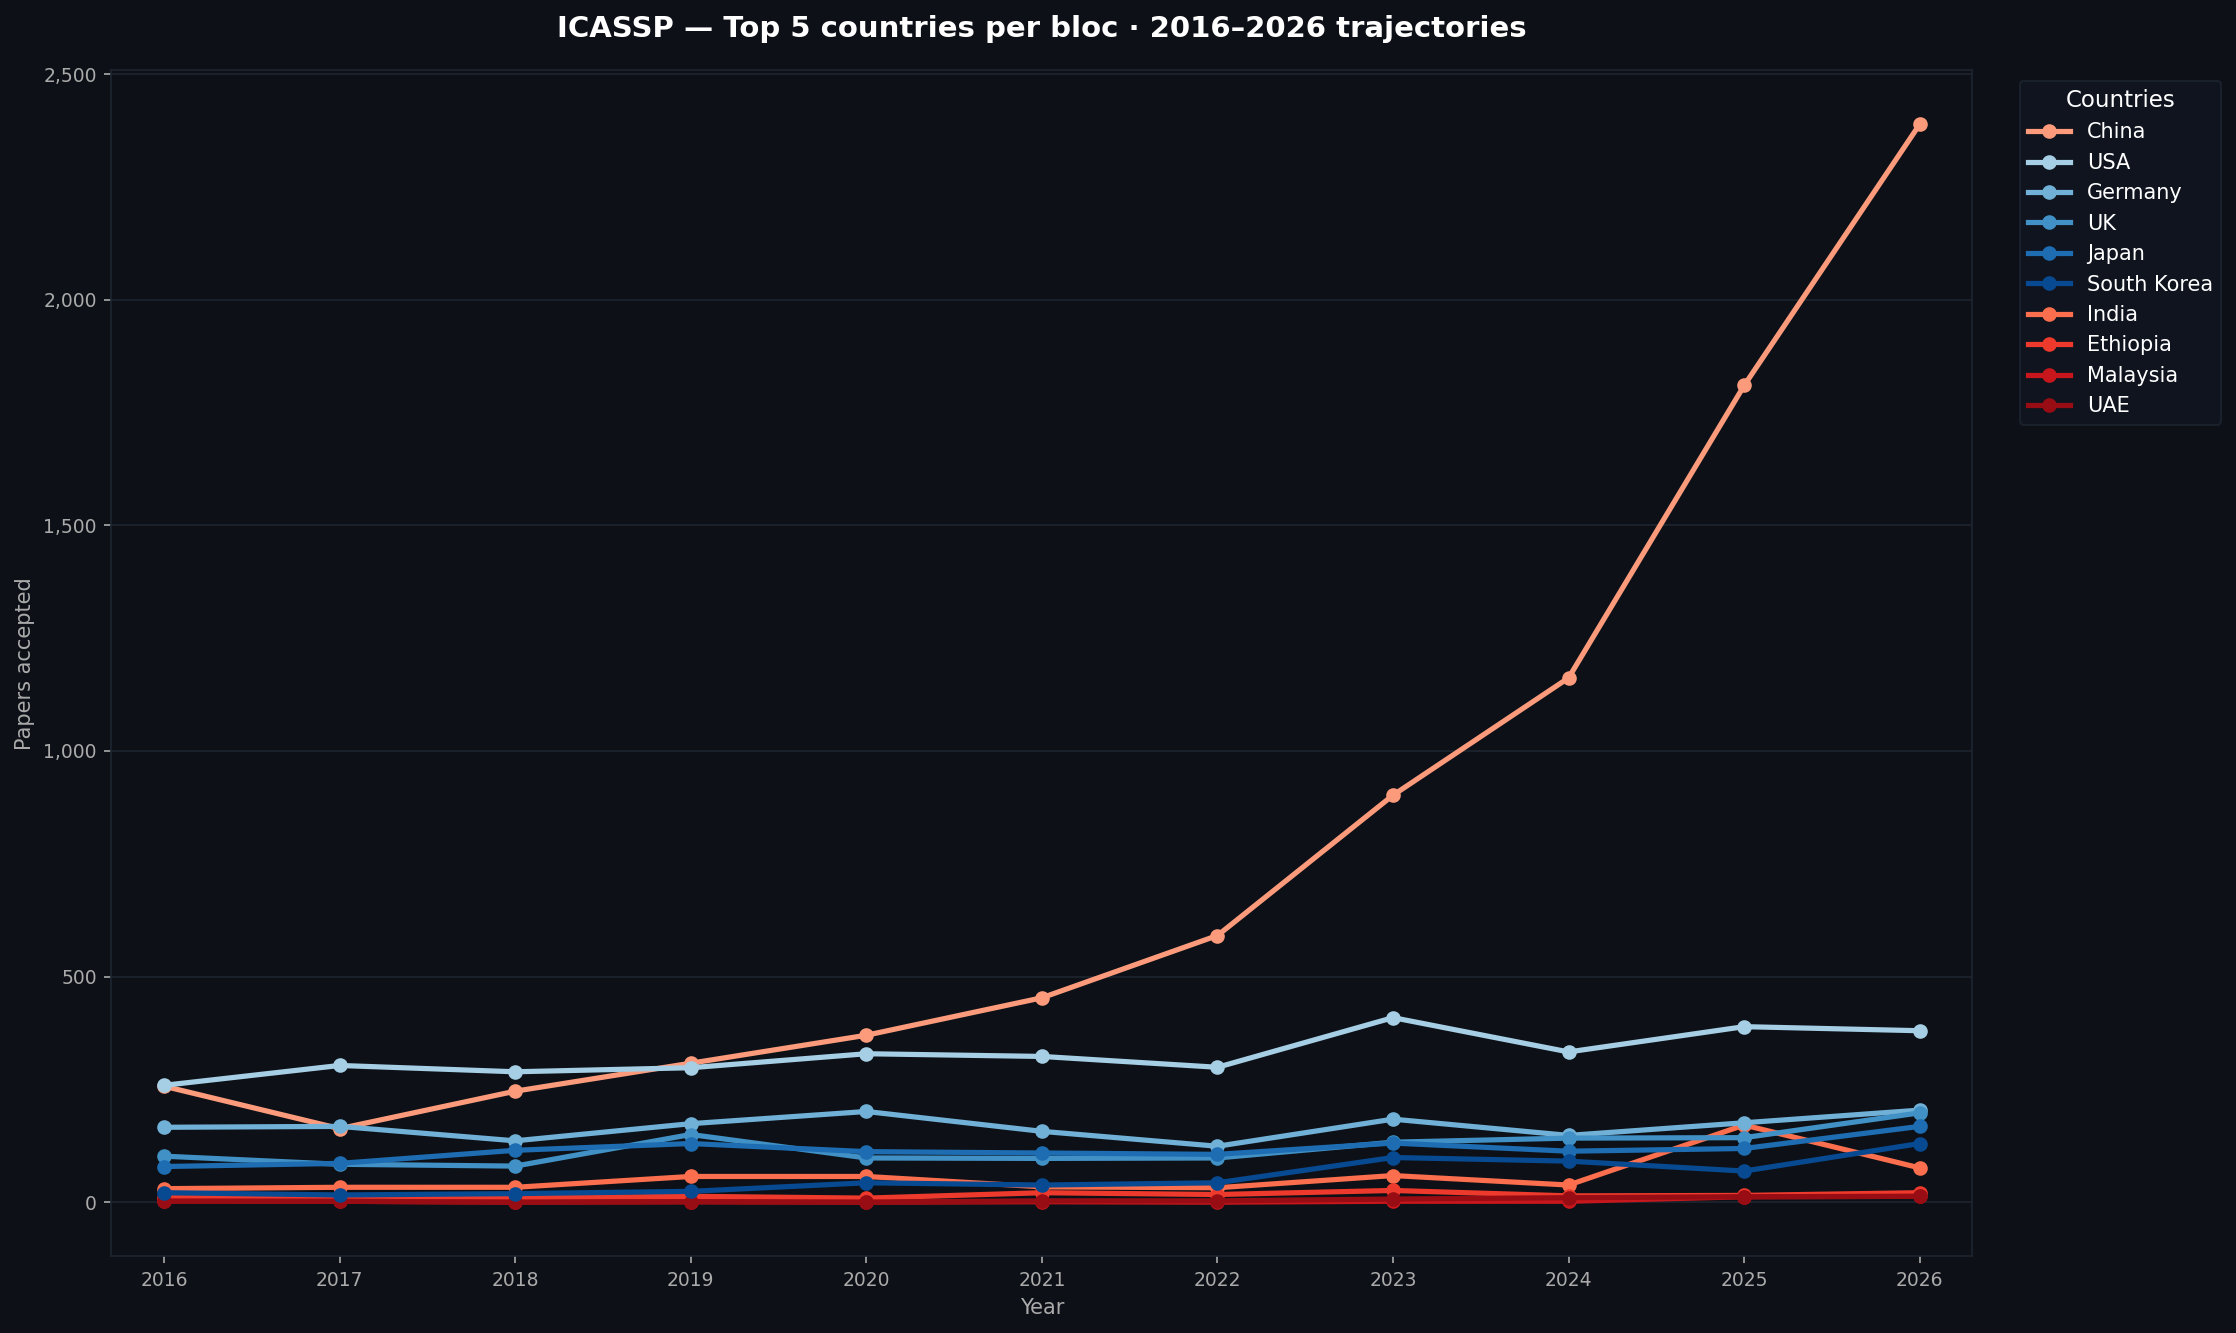

In [92]:
from IPython.display import Image as img
from IPython.display import display

# ── Notebook Media Rendering ─────────────────────────────────────────
# We leverage IPython's native display engine to inject rich media
# directly into the Jupyter/Colab frontend. This bypasses the need
# for raw HTML tags or external web browser tabs.
# ──────────────────────────────────────────────────────────────────────

# Define the local path or workspace filename of your targeted animation.
# NOTE: Make sure 'icassp_top10_trajectory.png' is uploaded to your environment's
# filesystem (the folder icon on the left sidebar) before running this.
img_path = "icassp_top10_trajectory.png"

# The Image class reads and structures the raw data bytes of the PNG,
# while display() explicitly renders the media framework inline within
# the cell's output zone.
display(img(filename=img_path))

### 4.7 Step 5: Build the interactive trajectory HTML

The final output is a Chart.js line chart where the viewer can:
- Hover over any point to see the exact paper count for all countries that year
- Click legend items to show/hide individual country lines
- Filter by bloc (BRICS+ only, West only, or all)
- Read stat cards showing each country's 2026 count and growth since 2016


In [93]:
def hex_or_rgba(col) -> str:
    """
    Convert a matplotlib RGBA tuple or hex string to a CSS hex colour string.

    Parameters
    ----------
    col : tuple or str
        Either an RGBA float tuple ``(r, g, b, a)`` or a hex string.

    Returns
    -------
    str
        A CSS hex string like ``"#1a5276"``.
    """
    if isinstance(col, str):
        return col
    r, g, b, _ = col
    return "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))


# ── Build Chart.js dataset list ────────────────────────────────────────
# Each dict represents one country's line: its colour, data, and metadata.
# The 'bloc' key is a custom field — it's not a Chart.js property, but we
# embed it so the JavaScript filter buttons can read it.
datasets_js = []
for country in top10:
    vals = [int(pivot.loc[y, country]) for y in YEARS]
    bloc = country_bloc.get(country, "West")
    col  = hex_or_rgba(color_map[country])
    datasets_js.append({
        "label":                country,
        "data":                 vals,
        "borderColor":          col,
        "backgroundColor":      col + "33",    # 33 hex = ~20% opacity fill
        "pointBackgroundColor": col,
        "pointRadius":          5,
        "pointHoverRadius":     8,
        "borderWidth":          2.5,
        "tension":              0.35,           # Slight curve between points
        "fill":                 False,
        "bloc":                 bloc,           # Custom — used by filter buttons
    })

payload_traj = {
    "years":    YEARS,
    "datasets": datasets_js,
    "top10":    top10,
    "blocs":    {c: country_bloc.get(c, "West") for c in top10},
}
print(f"✅ Chart.js dataset prepared: {len(datasets_js)} country lines.")


✅ Chart.js dataset prepared: 10 country lines.


### 4.7.1 What's new in this HTML — CSS custom properties and advanced JavaScript

This second page is architecturally identical to the donut page (Section 3.6): Python injects JSON data, Chart.js draws the chart, JavaScript responds to user interaction. But it introduces several new techniques worth studying carefully.

---

### 4.7.2 CSS custom properties — the `:root` variable system

In the donut page, colours were hardcoded: `background: #0d1117`. This works but becomes tedious to maintain — if you want to change the background colour, you have to find and update every occurrence.

The trajectory page uses **CSS custom properties** (also called CSS variables) to define all colours in one place:

```css
:root {{
  --bg:     #0d1117;   /* page background */
  --panel:  #111820;   /* card/chart background */
  --border: #1e2a38;   /* border lines */
  --text:   #c9d1d9;   /* body text */
  --dim:    #6e7681;   /* secondary/muted text */
  --brics:  #e74c3c;   /* BRICS+ accent red */
  --west:   #5dade2;   /* West accent blue */
  --accent: #f0c040;   /* interactive highlight yellow */
}}
```

`:root` is a CSS pseudo-class that matches the root element (`<html>`). Defining variables here makes them available everywhere in the stylesheet.

**Using a variable:** `background: var(--bg);`

**Why this matters:** To switch from dark mode to light mode, you change the `:root` variables — every element that uses `var(--bg)` updates automatically. This is the professional approach to theming.

---

### 4.7.3 `clamp()` — responsive font sizes

```css
h1 {{ font-size: clamp(1.4rem, 3vw, 2rem); }}
```

`clamp(minimum, preferred, maximum)` picks a value between min and max based on the preferred expression:
- On a narrow screen (e.g. 300px wide): `3vw = 9px` → too small → uses minimum `1.4rem`
- On a medium screen (e.g. 800px wide): `3vw = 24px` → fits in range → uses `3vw`
- On a wide screen (e.g. 1200px wide): `3vw = 36px` → too big → uses maximum `2rem`

`vw` = viewport width units — 1vw = 1% of the browser window width. This creates typography that smoothly scales with screen size.

---

### 4.7.4 The filter buttons — multiple CSS classes on one element

```html
<button class="btn active"    id="btnAll"   onclick="filterBloc('all')">All</button>
<button class="btn brics-btn" id="btnBrics" onclick="filterBloc('BRICS+')">BRICS+ only</button>
<button class="btn west-btn"  id="btnWest"  onclick="filterBloc('West')">West only</button>
```

Each button has **two classes**: `btn` (base styling shared by all buttons) plus a modifier class (`active`, `brics-btn`, `west-btn`).

CSS rules for compound selectors:
```css
/* Any element with BOTH classes btn AND active: */
.btn.active {{ border-color: var(--accent); color: var(--accent); }}

/* Any element with BOTH classes btn AND brics-btn, when hovered OR active: */
.btn.brics-btn:hover,
.btn.brics-btn.active {{ border-color: var(--brics); color: var(--brics); }}
```

JavaScript switches which button appears "active" by adding/removing the `active` class:
```javascript
document.getElementById('btnAll').classList.toggle('active', bloc === 'all');
// If bloc === 'all': adds 'active' to btnAll, removes it from others.
```

---

### 4.7.5 `toggleSeries(i, el)` — showing and hiding individual lines

Chart.js stores visibility metadata for each dataset. `chart.getDatasetMeta(index)` returns that metadata object, and setting `meta.hidden` controls visibility:

```javascript
function toggleSeries(datasetIndex, legendElement) {{
  const meta = chart.getDatasetMeta(datasetIndex);

  // ! is the logical NOT operator: true → false, false → true
  meta.hidden = !meta.hidden;

  // classList.toggle('faded', condition) — adds 'faded' class if condition is true
  // CSS: .legend-item.faded {{ opacity: 0.28 }} — dims the legend entry
  legendElement.classList.toggle('faded', meta.hidden);

  chart.update();   // re-render with updated visibility
  buildStats();     // rebuild stat cards (hidden series should not appear)
}}
```

**Why `!meta.hidden`?** The `!` (logical NOT) operator flips a boolean: `!true = false`, `!false = true`. So clicking a visible series hides it; clicking a hidden series shows it.

---

### 4.7.6 `filterBloc(bloc)` — show/hide entire blocs

This function hides all datasets whose `bloc` property doesn't match the selected bloc:

```javascript
function filterBloc(selectedBloc) {{
  RAW.datasets.forEach((dataset, index) => {{
    const meta        = chart.getDatasetMeta(index);
    const legendItem  = document.querySelector(`.legend-item[data-index="${{index}}"]`);

    // Should this dataset be hidden?
    // Hide if: selectedBloc is not 'all' AND this dataset's bloc doesn't match.
    const shouldHide = selectedBloc !== 'all' && dataset.bloc !== selectedBloc;

    meta.hidden = shouldHide;
    if (legendItem) legendItem.classList.toggle('faded', shouldHide);
  }});

  chart.update();
  buildStats();
}}
```

**`document.querySelector('.legend-item[data-index="2"]')`** — CSS attribute selector. Finds the first element that has class `legend-item` AND has attribute `data-index` equal to `"2"`. This is more targeted than `getElementById` when you need to select by data attributes.

---

### 4.7.7 `buildStats()` — generating stat cards dynamically

This function creates HTML stat cards in JavaScript — one for each currently visible dataset. It demonstrates the full pattern of dynamic HTML generation:

```javascript
function buildStats() {{
  const statsContainer = document.getElementById('statsRow');
  statsContainer.innerHTML = '';    // clear any existing cards

  RAW.datasets.forEach((dataset, index) => {{
    // Skip hidden datasets
    if (!chart.isDatasetVisible(index)) return;

    const lastValue  = dataset.data[dataset.data.length - 1];   // 2026 value
    const firstValue = dataset.data[0];                          // 2016 value

    // Calculate growth percentage, or show '—' if there's no 2016 data
    const growthPercent = firstValue > 0
      ? (((lastValue - firstValue) / firstValue) * 100).toFixed(0)
      : '—';

    // Create a card element and set its inner HTML
    const card = document.createElement('div');
    card.className = 'stat-card';
    card.innerHTML = `
      <div class="stat-label">${{dataset.label}}</div>
      <div class="stat-value">${{lastValue.toLocaleString()}}</div>
      <div class="stat-sub">
        2026 papers &bull;
        ${{growthPercent !== '—' ? growthPercent + '% growth since 2016' : 'no 2016 data'}}
      </div>`;

    // The ternary operator: condition ? valueIfTrue : valueIfFalse
    // Like Python's: valueIfTrue if condition else valueIfFalse

    statsContainer.appendChild(card);
  }});
}}
```

**`dataset.data[dataset.data.length - 1]`** — gets the last element of an array. JavaScript arrays don't support negative indices like Python's `data[-1]`, so `data[data.length - 1]` is the standard idiom.

---

### 4.7.8 How the Chart.js line chart differs from the donut

The trajectory page uses `type: 'line'` instead of `'doughnut'`. Key differences in the options:

```javascript
options: {{
  // 'interaction: {{ mode: index }}' — when hovering, show tooltips for ALL
  // datasets at the same x position, not just the nearest point.
  // This makes it easy to compare all countries at a given year.
  interaction: {{ mode: 'index', intersect: false }},

  // 'scales' — line charts have x and y axes; donut charts don't.
  scales: {{
    x: {{
      ticks: {{ color: '#6e7681' }},   // x-axis tick label colour
      grid:  {{ color: '#1e2a38' }},   // x-axis grid line colour
    }},
    y: {{
      ticks: {{
        color:    '#6e7681',
        // callback: custom tick formatter.
        // v => v.toLocaleString() formats 2000 as "2,000" (locale thousands separator)
        callback: paperCount => paperCount.toLocaleString(),
      }},
      grid:         {{ color: '#1e2a38' }},
      beginAtZero:  true,    // y-axis starts at 0, not the data minimum
    }},
  }},
}}
```

**`tension: 0.35`** in each dataset — controls how curved the line is between points. `0` = straight lines (angular), `1` = very curved (smooth spline). `0.35` gives a gentle curve.

**`fill: false`** — don't shade the area under the line. `fill: true` would create an area chart.

- `:root {{ --bg: #0d1117; ... }}` — CSS custom properties (variables) defined on `:root` are available throughout the page. This makes it easy to update the entire colour scheme by changing one place.
- `.btn.active` — a CSS selector targeting buttons with *both* classes `btn` and `active`. JavaScript adds/removes `active` to switch which filter button appears highlighted.

**The data injection** works exactly as in the donut: `const RAW = {json.dumps(payload_traj)};` embeds the entire Python `payload_traj` dictionary as a JavaScript constant. Chart.js reads `RAW.datasets` to draw the lines.


In [94]:
# ── Build and save the interactive trajectory HTML ─────────────────────
#
# Same architecture as the donut page (Section 3.6):
#   Python f-string  →  HTML+CSS+JS written to a .html file.
#
# {{ and }} produce literal { } characters in the output.
# {json.dumps(variable)} injects Python data as JavaScript.
#
# New in this page:
#   - CSS custom properties (:root { --variable: value; })
#   - clamp() for responsive font sizes
#   - filter buttons that show/hide chart datasets
#   - stat cards generated dynamically from visible datasets

html_traj = f'''<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <title>ICASSP Top Country Trajectories 2016–2026</title>

  <!-- Chart.js from cdnjs — an alternative CDN to jsdelivr.
       Both serve the same library; using different CDNs in different pages
       is fine and common practice. -->
  <script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>

<style>

  /* ── Universal reset ──────────────────────────────────────────────
     *,*::before,*::after targets all elements AND their ::before /
     ::after pseudo-elements (used for decorative content added via CSS).
     This ensures no element has unexpected default sizing. */
  *,*::before,*::after {{ box-sizing: border-box; margin: 0; padding: 0; }}

  /* ── CSS Custom Properties (variables) defined on :root ──────────
     :root is the <html> element — the highest level in the DOM tree.
     Variables defined here cascade down to every child element.
     Syntax: --variable-name: value;
     Usage:  property: var(--variable-name);
     Benefit: change a colour in ONE place, it updates everywhere. */
  :root {{
    --bg:     #0d1117;   /* page and canvas background: near-black navy */
    --panel:  #111820;   /* card/chart surface: slightly lighter navy */
    --border: #1e2a38;   /* border lines: dark slate */
    --text:   #c9d1d9;   /* primary text: light grey */
    --dim:    #6e7681;   /* secondary/muted text: medium grey */
    --brics:  #e74c3c;   /* BRICS+ accent: strong red */
    --west:   #5dade2;   /* West accent: sky blue */
    --accent: #f0c040;   /* interactive hover/active: yellow-gold */
  }}

  /* ── Page body ────────────────────────────────────────────────────
     var(--bg) reads the --bg variable defined above.
     font-family: 'DM Mono' is a monospaced font (all characters same width),
       giving the page a technical/data-dashboard aesthetic.
       'monospace' is the generic fallback if DM Mono isn't installed. */\n  body {{\n    background: var(--bg);\n    color:      var(--text);\n    font-family: 'DM Mono', monospace;\n    min-height:  100vh;\n    padding:     28px 36px 48px;    /* top | left+right | bottom */\n  }}\n\n  /* ── Heading ──────────────────────────────────────────────────────\n     clamp(min, preferred, max) — responsive font size:\n       If 3vw < 1.4rem → uses 1.4rem (minimum)\n       If 3vw > 2rem   → uses 2rem   (maximum)\n       Otherwise       → uses 3vw    (scales with viewport width)\n     letter-spacing: -0.02em — tighten character spacing slightly.\n     em is relative to the current font size (1em = current font size).\n     line-height: 1.1 — 10% more than the font size (compact leading). */\n  h1 {{\n    font-size:      clamp(1.4rem, 3vw, 2rem);\n    font-weight:    800;\n    color:          #fff;\n    letter-spacing: -0.02em;\n    line-height:    1.1;\n  }}\n\n  /* Target <span> elements inside h1 with class 'brics' or 'west'.\n     The HTML uses: <span class="brics">BRICS+</span>\n     This colours those words in their respective bloc colours. */\n  h1 span.brics {{ color: var(--brics); }}\n  h1 span.west  {{ color: var(--west); }}\n\n  .subtitle {{\n    font-size:      0.78rem;\n    color:          var(--dim);\n    margin-top:     6px;\n    letter-spacing: 0.04em;   /* slightly wider spacing — 'airy' look */\n  }}\n\n  /* ── Filter button row ────────────────────────────────────────────\n     flex-wrap: wrap — buttons wrap to next line if viewport is narrow.\n     align-items: center — vertically centre buttons with any adjacent text. */\n  .controls {{\n    display:     flex;\n    flex-wrap:   wrap;\n    gap:         10px;\n    margin:      20px 0;\n    align-items: center;\n  }}\n\n  /* ── Base button style ───────────────────────────────────────────\n     border-radius: 4px — slightly rounded corners.\n     border: 1px solid var(--border) — thin dark border.\n     cursor: pointer — hand cursor to signal clickability.\n     transition: all .18s — animate ALL property changes over 0.18s.\n       Using 'all' is convenient but slightly less efficient than\n       listing specific properties; fine here since we control the styles.\n     text-transform: uppercase — makes button labels ALL CAPS.\n     letter-spacing: 0.06em — extra spacing looks better in all-caps. */\n  .btn {{\n    font-size:      0.72rem;\n    padding:        6px 14px;\n    border-radius:  4px;\n    border:         1px solid var(--border);\n    background:     var(--panel);\n    color:          var(--dim);\n    cursor:         pointer;\n    transition:     all .18s;\n    letter-spacing: 0.06em;\n    text-transform: uppercase;\n  }}\n\n  /* .btn:hover — styles applied when cursor is over the button.\n     .btn.active — applied when the button has the 'active' class (set by JS).\n     Comma separates two selectors that share the same declarations. */\n  .btn:hover,\n  .btn.active {{\n    border-color: var(--accent);\n    color:        var(--accent);\n    background:   #1a1a0a;    /* very dark yellow tint */\n  }}\n\n  /* BRICS+ button — different hover/active colours from the default */\n  .btn.brics-btn:hover,\n  .btn.brics-btn.active {{\n    border-color: var(--brics);\n    color:        var(--brics);\n    background:   #1a0a0a;    /* very dark red tint */\n  }}\n\n  /* West button */\n  .btn.west-btn:hover,\n  .btn.west-btn.active {{\n    border-color: var(--west);\n    color:        var(--west);\n    background:   #0a131a;    /* very dark blue tint */\n  }}\n\n  /* ── Chart container ──────────────────────────────────────────────\n     background: var(--panel) — slightly lighter than the page background,\n       creating a subtle card-like lift effect.\n     border: 1px solid var(--border) — thin perimeter line.\n     border-radius: 8px — rounded card corners. */\n  .chart-wrap {{\n    background:    var(--panel);\n    border:        1px solid var(--border);\n    border-radius: 8px;\n    padding:       24px 20px 16px;\n  }}\n\n  /* canvas {{ width: 100% !important }} — force the canvas to fill its container.\n     !important overrides any conflicting rules (including Chart.js inline styles).\n     Chart.js normally sets an explicit pixel width; this overrides it for\n     responsive layout. */\n  canvas {{ width: 100% !important; }}\n\n  /* ── Clickable legend items ────────────────────────────────────────\n     user-select: none — prevents text being accidentally selected when clicking.\n     opacity: 1 — full opacity by default (toggled by JavaScript).\n     transition: opacity .2s — fade rather than snap when opacity changes. */\n  .legend {{\n    display:   flex;\n    flex-wrap: wrap;\n    gap:       10px 20px;\n    margin-top: 22px;\n    padding:    0 4px;\n  }}\n\n  .legend-item {{\n    display:     flex;\n    align-items: center;\n    gap:         7px;\n    font-size:   0.74rem;\n    color:       var(--text);\n    cursor:      pointer;\n    opacity:     1;\n    transition:  opacity .2s;\n    user-select: none;\n  }}\n\n  /* .faded class is added by JS when a series is hidden.\n     opacity: 0.28 dims the legend entry to signal it is inactive. */\n  .legend-item.faded {{ opacity: 0.28; }}\n\n  /* The coloured circle dot in each legend item.\n     border-radius: 50% makes a square into a circle. */\n  .legend-dot {{\n    width:         10px;\n    height:        10px;\n    border-radius: 50%;\n    flex-shrink:   0;    /* don't shrink if container is narrow */
  }}

  /* Bloc badge: a small pill label showing "BRICS+" or "WEST". */
  .legend-badge {{
    font-size:      0.62rem;
    padding:        1px 5px;
    border-radius:  3px;
    letter-spacing: 0.05em;
    text-transform: uppercase;
  }}
  .badge-brics {{ background: #3b1010; color: var(--brics); }}
  .badge-west  {{ background: #0a1e30; color: var(--west); }}

  /* ── Stat card row ────────────────────────────────────────────────
     flex: 1 1 140px — each card:
       grow to fill space (flex-grow: 1)
       shrink if needed (flex-shrink: 1)
       start at 140px wide (flex-basis: 140px)
     This creates a responsive grid of cards that wraps automatically. */
  .stats-row {{
    display:    flex;
    flex-wrap:  wrap;
    gap:        12px;
    margin-top: 28px;
  }}

  .stat-card {{
    flex:          1 1 140px;
    background:    var(--panel);
    border:        1px solid var(--border);
    border-radius: 6px;
    padding:       14px 16px;
  }}

  /* text-transform: uppercase + letter-spacing: 0.08em — compact uppercase label
     above the main number, like a data dashboard card. */
  .stat-label {{
    font-size:      0.65rem;
    color:          var(--dim);
    letter-spacing: 0.08em;
    text-transform: uppercase;
    margin-bottom:  6px;
  }}

  /* The big number — large, bold, white. */
  .stat-value {{
    font-size:   1.5rem;
    font-weight: 800;
    color:       #fff;
  }}

  /* The subtitle line: "2026 papers • X% growth since 2016" */
  .stat-sub {{
    font-size:  0.68rem;
    color:      var(--dim);
    margin-top: 2px;
  }}

</style>
</head>

<body>

<!-- ── Page header ─────────────────────────────────────────────────────
     The <header> element is a semantic HTML5 element — it indicates to
     browsers and screen readers that this content is the page's header.\n     Semantically equivalent to a <div> but carries meaning.\n\n     TOP_N is a Python variable injected by the f-string (not double-braced).\n     The &mdash; is the HTML entity for an em dash — . -->\n<header>\n  <h1>\n    ICASSP Top {TOP_N} per bloc &mdash;\n    <span class="brics">BRICS+</span> vs <span class="west">West</span>\n  </h1>\n  <p class="subtitle">\n    Top {TOP_N} from each bloc ranked by 2026 paper count\n    &bull; trajectories 2016–2026\n  </p>\n</header>\n\n<!-- ── Filter buttons ─────────────────────────────────────────────────\n     onclick="filterBloc('all')" calls the JS function filterBloc() when\n     clicked, passing the string 'all', 'BRICS+', or 'West'.\n     The 'active' class is present on the "All" button initially. -->\n<div class="controls">\n  <button class="btn active"    id="btnAll"   onclick="filterBloc('all')">All</button>\n  <button class="btn brics-btn" id="btnBrics" onclick="filterBloc('BRICS+')">BRICS+ only</button>\n  <button class="btn west-btn"  id="btnWest"  onclick="filterBloc('West')">West only</button>\n</div>\n\n<!-- ── Line chart canvas ───────────────────────────────────────────────\n     height="420" sets the canvas height in pixels.\n     Chart.js overrides the width with the container's CSS width
     (due to  canvas {{ width: 100% !important }}  above). -->
<div class="chart-wrap">
  <canvas id="trajChart" height="420"></canvas>
</div>

<!-- JavaScript will populate these containers dynamically: -->
<div class="legend"    id="legend"></div>
<div class="stats-row" id="statsRow"></div>


<script>

// ── DATA INJECTION ─────────────────────────────────────────────────
// Python's json.dumps() converted payload_traj to a JSON string.\n// JavaScript reads it as a native object (no parsing needed — it IS\n// a valid JavaScript object literal).\n//\n// RAW structure:\n//   {{\n//     years:    [2016, 2017, ..., 2026],\n//     datasets: [\n//       {{\n//         label:       "China",\n//         data:        [1200, 1350, ..., 2387],  ← paper count per year\n//         borderColor: "#c0392b",\n//         bloc:        "BRICS+",                 ← custom field, not Chart.js\n//         ...\n//       }},\n//       {{ label: "India", ... }},\n//       ...\n//     ],\n//     top10: ["China", "India", ...],\n//     blocs: {{ "China": "BRICS+", "USA": "West", ... }},\n//   }}\nconst RAW = {json.dumps(payload_traj)};\n\n\n// ── GET DRAWING CONTEXT ────────────────────────────────────────────\n// getContext('2d') returns a CanvasRenderingContext2D — the surface\n// Chart.js will use to draw lines and axes.\nconst ctx = document.getElementById('trajChart').getContext('2d');\n\n\n// ── CREATE THE CHART ───────────────────────────────────────────────\n// new Chart(context, configuration) initialises and renders the chart.\n// Unlike the donut page, we create it immediately (no initChart function)\n// because the line chart uses RAW.datasets directly — no preprocessing needed.\nconst chart = new Chart(ctx, {{\n\n  type: 'line',   // line chart: x-axis = years, y-axis = paper count\n\n  data: {{\n    labels:   RAW.years,     // x-axis tick labels: [2016, 2017, ..., 2026]\n    datasets: RAW.datasets,  // one dataset per country (from Python's payload_traj)
    // Each dataset has the Chart.js properties we set in Python:
    //   label, data, borderColor, backgroundColor, pointRadius, tension, etc.
    // The 'bloc' property is our custom addition — Chart.js ignores unknown keys.
  }},

  options: {{
    responsive: true,    // resize with the container

    animation: {{
      duration: 600,
      easing:   'easeInOutQuart',
    }},

    // interaction.mode: 'index' — when hovering, show tooltips for ALL
    // datasets at the same x index (year), not just the nearest point.
    // intersect: false — trigger the tooltip even if the cursor isn't\n    // exactly on a data point — anywhere in the column above that year.\n    interaction: {{\n      mode:      'index',\n      intersect: false,\n    }},\n\n    plugins: {{\n      legend: {{ display: false }},   // we draw our own clickable legend below\n\n      tooltip: {{\n        backgroundColor: '#111820',   // tooltip box background
        borderColor:     '#1e2a38',   // tooltip box border
        borderWidth:     1,
        titleColor:      '#c9d1d9',   // year label colour
        bodyColor:       '#c9d1d9',   // line-by-line values colour

        callbacks: {{
          // Custom label formatter: "  China: 2,387 papers"
          // ctx here is the tooltip context object (NOT the canvas context).
          // ctx.dataset.label — the country name
          // ctx.parsed.y     — the y value for this dataset at this x position
          label: tooltipCtx => ` ${{tooltipCtx.dataset.label}}: ${{tooltipCtx.parsed.y.toLocaleString()}} papers`,
        }},
      }},
    }},

    scales: {{
      x: {{
        ticks: {{ color: '#6e7681' }},   // x-axis label colour
        grid:  {{ color: '#1e2a38' }},   // x-axis grid line colour
      }},
      y: {{
        ticks: {{
          color:    '#6e7681',
          // callback: custom tick label formatter.
          // v => v.toLocaleString() turns 2000 into "2,000".
          callback: paperCount => paperCount.toLocaleString(),
        }},
        grid:        {{ color: '#1e2a38' }},
        beginAtZero: true,   // y-axis starts at 0, not the minimum data value
      }},
    }},
  }},
}});


// ── BUILD LEGEND ──────────────────────────────────────────────────
// For each dataset (country line), create a legend item:
//   coloured circle + country name + bloc badge
// Clicking a legend item toggles that country's line on/off.\nconst legendEl = document.getElementById('legend');\n\nRAW.datasets.forEach((dataset, datasetIndex) => {{\n  const bloc = dataset.bloc;   // "BRICS+" or "West"\n\n  const item = document.createElement('div');\n  item.className    = 'legend-item';\n  item.dataset.index = datasetIndex;   // data-index="0" etc., read by filterBloc()\n\n  // Template literal: build the inner HTML for this legend item.\n  // The ternary  bloc === 'BRICS+' ? 'badge-brics' : 'badge-west'\n  // picks the badge CSS class based on the bloc.\n  item.innerHTML = `\n    <div class="legend-dot" style="background:${{dataset.borderColor}}"></div>\n    ${{dataset.label}}\n    <span class="legend-badge ${{bloc === 'BRICS+' ? 'badge-brics' : 'badge-west'}}">${{bloc}}</span>`;\n\n  // When clicked, toggle this series' visibility.
  // Arrow function: () => toggleSeries(i, item)
  // Captures datasetIndex and item from the surrounding forEach scope (closure).
  item.onclick = () => toggleSeries(datasetIndex, item);

  legendEl.appendChild(item);
}});


// ── buildStats() ─────────────────────────────────────────────────
// Regenerates the stat cards from scratch, showing only VISIBLE datasets.
// Called at startup and after every toggle/filter action.
function buildStats() {{
  const statsEl = document.getElementById('statsRow');
  statsEl.innerHTML = '';   // clear all existing cards

  RAW.datasets.forEach((dataset, datasetIndex) => {{

    // chart.isDatasetVisible(i) returns true if the dataset is currently shown.
    // Skip hidden datasets — their cards should not appear.
    if (!chart.isDatasetVisible(datasetIndex)) return;

    // Get the first and last paper counts from the dataset's data array.\n    // JavaScript doesn't support negative indices (unlike Python's data[-1]),\n    // so we use  data[data.length - 1]  to get the last element.\n    const lastValue  = dataset.data[dataset.data.length - 1];   // 2026\n    const firstValue = dataset.data[0];                          // 2016\n\n    // Calculate growth percentage.\n    // Ternary operator: condition ? valueIfTrue : valueIfFalse\n    // Python equivalent: ((last-first)/first*100) if first > 0 else '—'\n    const growthText = firstValue > 0\n      ? (((lastValue - firstValue) / firstValue) * 100).toFixed(0) + '% growth since 2016'\n      : 'no 2016 data';\n\n    // Create the stat card element and inject its HTML.\n    const card = document.createElement('div');\n    card.className = 'stat-card';\n    card.innerHTML = `\n      <div class="stat-label">${{dataset.label}}</div>\n      <div class="stat-value">${{lastValue.toLocaleString()}}</div>\n      <div class="stat-sub">2026 papers &bull; ${{growthText}}</div>`;\n\n    statsEl.appendChild(card);\n  }});\n}}\n\n// Run buildStats() immediately so cards are visible on page load.\nbuildStats();\n\n\n// ── toggleSeries(datasetIndex, legendElement) ────────────────────\n// Shows or hides a single country line when its legend item is clicked.\nfunction toggleSeries(datasetIndex, legendElement) {{\n\n  // chart.getDatasetMeta(i) returns Chart.js metadata for dataset i,\n  // including the 'hidden' flag that controls visibility.\n  const meta = chart.getDatasetMeta(datasetIndex);\n\n  // Flip the hidden flag: true → false, false → true.\n  // ! is the logical NOT operator (same role as Python's 'not').
  meta.hidden = !meta.hidden;

  // classList.toggle('faded', condition):
  //   adds 'faded' class if condition is true (series is now hidden)
  //   removes 'faded' class if condition is false (series is now visible)
  // CSS: .legend-item.faded {{ opacity: 0.28 }} — dims the legend entry.
  legendElement.classList.toggle('faded', meta.hidden);

  chart.update();   // re-render the chart with updated visibility
  buildStats();     // rebuild stat cards (hidden series should disappear)
}}


// ── filterBloc(selectedBloc) ─────────────────────────────────────
// Shows or hides ALL lines belonging to a given bloc.
// Called by the three filter buttons at the top of the page.
//
// selectedBloc: 'all', 'BRICS+', or 'West'
function filterBloc(selectedBloc) {{

  // Update button active states:
  // classList.toggle('active', condition) adds or removes 'active'.
  document.getElementById('btnAll').classList.toggle('active',   selectedBloc === 'all');
  document.getElementById('btnBrics').classList.toggle('active', selectedBloc === 'BRICS+');
  document.getElementById('btnWest').classList.toggle('active',  selectedBloc === 'West');

  // Loop over every dataset and hide/show it based on its bloc.
  RAW.datasets.forEach((dataset, datasetIndex) => {{
    const meta = chart.getDatasetMeta(datasetIndex);

    // Find this dataset's legend item using a CSS attribute selector.\n    // .legend-item[data-index="2"] — element with class 'legend-item'\n    //   AND attribute data-index equal to "2".\n    const legendItem = document.querySelector(`.legend-item[data-index="${{datasetIndex}}"]`);\n\n    // Should this dataset be hidden?\n    // Hide if: we're NOT showing all, AND this dataset's bloc doesn't match.
    const shouldHide = selectedBloc !== 'all' && dataset.bloc !== selectedBloc;

    meta.hidden = shouldHide;
    if (legendItem) legendItem.classList.toggle('faded', shouldHide);
  }});

  chart.update();   // re-render
  buildStats();     // rebuild cards (hidden datasets disappear)
}}

</script>
</body>
</html>'''

with open("icassp_top10_trajectory.html", "w", encoding="utf-8") as f:
    f.write(html_traj)
print("✅ Saved: icassp_top10_trajectory.html")


✅ Saved: icassp_top10_trajectory.html


In [95]:
import portpicker     # Dynamically finds a safe, unallocated port to avoid network collisions
import threading      # Spawns a background thread so the server doesn't freeze the notebook
from http.server import SimpleHTTPRequestHandler  # Converts local directories into an accessible website format
from socketserver import TCPServer                # Establishes the foundational web socket connection layer
from google.colab import output                  # Creates a secure proxy tunnel to display cloud ports inside an IFrame

# ── NETWORK INFRASTRUCTURE: PORT SELECTION ───────────────────────────
# In shared cloud environments like Google Colab, hardcoding a port (e.g., 8000)
# is dangerous because a previous run or another process might still hold it captive.
# 'portpicker' dynamically queries the OS kernel to discover and reserve a safe,
# completely unallocated network port for our temporary web server.
PORT = portpicker.pick_unused_port()


# ── SERVER INSTANTIATION LOGIC ────────────────────────────────────────
# We define a localized worker routine to host our file environment.
def serve_forever():
    # EXPLICIT TCP CONFIGURATION:
    # Setting 'allow_reuse_address' to True tells the operating system to immediately
    # reclaim the network socket when the cell or kernel restarts. Without this,
    # re-running this notebook cell would crash with a "Binds/Address already in use" error.
    TCPServer.allow_reuse_address = True

    # Establish a standard TCP Server bound to our dynamic port.
    # 'SimpleHTTPRequestHandler' is configured by default to treat the active directory
    # (which is '/content/' in Colab) as its absolute root website domain (/).
    with TCPServer(("", PORT), SimpleHTTPRequestHandler) as httpd:
        print(f"📡 Internal server running on Colab port: {PORT}")

        # Keep the socket server listening and responding to incoming browser requests indefinitely
        httpd.serve_forever()


# ── THREAD MANAGEMENT: PREVENTING CORE BLOCKING ─────────────────────
# Python servers run on a blocking, continuous loop. If executed on the main execution path,
# this notebook cell would hang forever, spinning continuously and freezing the workspace.
# We map 'serve_forever' to an isolated background execution thread.
#
# CRITICAL: 'daemon=True' marks this thread as a background utility. This ensures that
# when the main Google Colab kernel process exits or restarts, the server process is
# automatically torn down, eliminating phantom zombie background processes.
thread = threading.Thread(target=serve_forever, daemon=True)
thread.start()


# ── COLAB TUNNEL PROXIES & RELATIVE ROUTING ──────────────────────────
# Standard browsers block cloud 'localhost' routes due to network separation and security rules.
# Google's 'output.serve_kernel_port_as_iframe()' creates a secure encrypted tunnel path from
# Google's runtime servers straight into an embedded window (IFrame) inside your web browser.
#
output.serve_kernel_port_as_iframe(PORT, path="/icassp_top10_trajectory.html", width="100%", height="600")

📡 Internal server running on Colab port: 44933


<IPython.core.display.Javascript object>

In [ ]:
# ── Download from Colab ─────────────────────────────────────────────────
try:
    from google.colab import files
    files.download("icassp_top10_trajectory.png")
    files.download("icassp_top10_trajectory.html")
except ModuleNotFoundError:
    print("(Not in Colab — files are in the current directory)")

print("\n🎉 All outputs complete!")
print("  📈  icassp_top10_trajectory.png  — static chart")
print("  🌐  icassp_top10_trajectory.html — interactive (open in any browser)")


---
### 🏋️ Challenge 4 — Extend the trajectory analysis

1. **Change the reference year:** Currently we rank countries by their 2026 paper count. What would the top 5 list look like if you ranked by **total papers across all years**? Change `df_2026` to use the full `full` DataFrame and rerun.

2. **Calculate growth rates:** For each country in `top10`, calculate its percentage growth from 2016 to 2026. Which country grew the fastest in each bloc?
   ```python
   for country in top10:
       first = pivot.loc[2016, country]
       last  = pivot.loc[2026, country]
       if first > 0:
           growth = (last - first) / first * 100
           print(f"{country:<20} {growth:+.0f}%")
   ```

3. **Normalise by conference size:** A country might appear to grow simply because ICASSP is accepting more papers each year. Divide each country's count by the total papers that year and plot the *share* instead. Does China's dominance look even stronger or weaker on this normalised view?

4. **Add a horizontal reference line:** Add a dashed line at `y = brics_2026["China"]` to make China's 2026 value visually obvious as a reference against which all other countries can be compared.


---
## Part 5 — A Decade of Divergence: China's Dominance and the AI Era in Academic Research

### 5.1 Introduction

The visualisations built in Parts 2–4 tell a clear quantitative story. This part zooms out to interpret that story in the context of global research trends, using both the ICASSP data and published research literature.

The central finding is stark: **while most nations' research output at ICASSP has remained essentially flat over the past decade, China's has grown to a scale that dwarfs every other country combined.** This is not a story of slight leadership — it is a story of an order-of-magnitude shift in the global centre of gravity for signal processing and AI research.

A second force is reshaping the landscape simultaneously: the emergence of large language model tools — **ChatGPT** (November 2022), **Claude** (March 2023 public release), and **Gemini** (December 2023) — which have produced a measurable and accelerating surge in global paper submission rates.

We will quantify both stories using the data we have already loaded.

---

### 5.2 Quantifying the gap using ICASSP 2026 data


In [96]:
# ── Compute key statistics from the 2026 ICASSP data ─────────────────
china_papers   = brics_2026["China"]
brics_ex_china = brics_summary.sum() - china_papers   # All BRICS+ except China
west_total_26  = west_summary.sum()
grand_total_26 = china_papers + brics_ex_china + west_total_26

china_pct          = china_papers   / grand_total_26 * 100
brics_ex_china_pct = brics_ex_china / grand_total_26 * 100
west_pct           = west_total_26  / grand_total_26 * 100

# Top 5 West countries combined
top5_west_names  = west_summary.sort_values(ascending=False).head(5).index.tolist()
top5_west_papers = int(west_summary[top5_west_names].sum())

print("=" * 55)
print("ICASSP 2026 — Key Statistics")
print("=" * 55)
print(f"Total papers (both blocs):        {grand_total_26:>6,}")
print()
print(f"China alone:                      {china_papers:>6,}  ({china_pct:.1f}%)")
print(f"Rest of BRICS+ (excl. China):     {int(brics_ex_china):>6,}  ({brics_ex_china_pct:.1f}%)")
print(f"Entire West bloc:                 {int(west_total_26):>6,}  ({west_pct:.1f}%)")
print()
print(f"China vs entire West:             {china_papers} vs {int(west_total_26)}")
print(f"  → China has {china_papers/west_total_26:.1f}× more papers than all of the West combined")
print()
print(f"Top 5 West countries: {top5_west_names}")
print(f"Top 5 West combined:              {top5_west_papers:>6,} papers")
print(f"China alone:                      {china_papers:>6,} papers")
print(f"  → China alone has {china_papers/top5_west_papers:.1f}× more papers than the West's top 5 combined")


ICASSP 2026 — Key Statistics
Total papers (both blocs):         4,580

China alone:                       2,389  (52.2%)
Rest of BRICS+ (excl. China):        172  (3.8%)
Entire West bloc:                  2,019  (44.1%)

China vs entire West:             2389 vs 2019
  → China has 1.2× more papers than all of the West combined

Top 5 West countries: ['USA', 'Germany', 'UK', 'Japan', 'South Korea']
Top 5 West combined:               1,080 papers
China alone:                       2,389 papers
  → China alone has 2.2× more papers than the West's top 5 combined


### 5.3 Visualising the gap — a comparative bar chart

A bar chart makes the gap between China and every other country visually unambiguous. We sort countries by descending paper count and use colour to distinguish the two blocs.

**New matplotlib concepts:**
- `ax.bar()` draws a bar chart. `bar(x_positions, heights, color=...)` — where x_positions can be a list of numbers or strings.
- `ax.bar_label()` places value labels above each bar automatically.
- `ax.axhline()` draws a horizontal reference line at a given y value.


In [97]:
# ── Build a combined ranked Series of all non-zero countries ──────────
all_2026 = pd.concat([brics_summary, west_summary])
all_2026 = all_2026[all_2026 > 0].sort_values(ascending=False)

# Build colour list: red tone for BRICS+ countries, blue for West
bar_colours = []
for country in all_2026.index:
    if country in brics_2026:
        bar_colours.append("#c0392b" if country == "China" else "#e8a49a")
    else:
        bar_colours.append("#2e86c1")

# ── Draw the chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.bar(
    range(len(all_2026)),    # x positions: 0, 1, 2, ...
    all_2026.values,         # bar heights: paper counts
    color=bar_colours,
    edgecolor=BG,
    linewidth=0.5,
    zorder=3,
)

# Place exact paper count above each bar
ax.bar_label(bars, labels=[f"{v:,}" for v in all_2026.values],
             fontsize=6.5, color="#cccccc", padding=3)

# Horizontal reference line at China's value
ax.axhline(china_papers, color="#e74c3c", lw=1.2, ls="--", alpha=0.5, zorder=2)
ax.text(len(all_2026) - 0.5, china_papers + 30,
        f"China: {china_papers:,}", ha="right", fontsize=8,
        color="#e74c3c",
        path_effects=[pe.withStroke(linewidth=2, foreground=BG)])

# x-axis: country names, rotated for readability
ax.set_xticks(range(len(all_2026)))
ax.set_xticklabels(all_2026.index, rotation=45, ha="right",
                   fontsize=8, color="#cccccc")
ax.tick_params(axis="y", colors="#aaaaaa")
ax.spines[:].set_color(GRID)
ax.yaxis.grid(True, color=GRID, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
ax.set_ylabel("ICASSP 2026 papers", color="#aaaaaa", fontsize=10)
ax.set_title(
    "ICASSP 2026 — All Countries by Paper Count  "
    "(China in red · West in blue · other BRICS+ in pink)",
    color="white", fontsize=12, fontweight="bold", pad=12,
)

# Legend
legend_items = [
    Patch(facecolor="#c0392b", label="China"),
    Patch(facecolor="#e8a49a", label="Other BRICS+"),
    Patch(facecolor="#2e86c1", label="Collective West"),
]
ax.legend(handles=legend_items, facecolor="#1a1f2b",
          edgecolor="#333", labelcolor="white", fontsize=9)

plt.tight_layout()
plt.savefig("icassp_2026_all_countries.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("✅ Saved: icassp_2026_all_countries.png")


✅ Saved: icassp_2026_all_countries.png


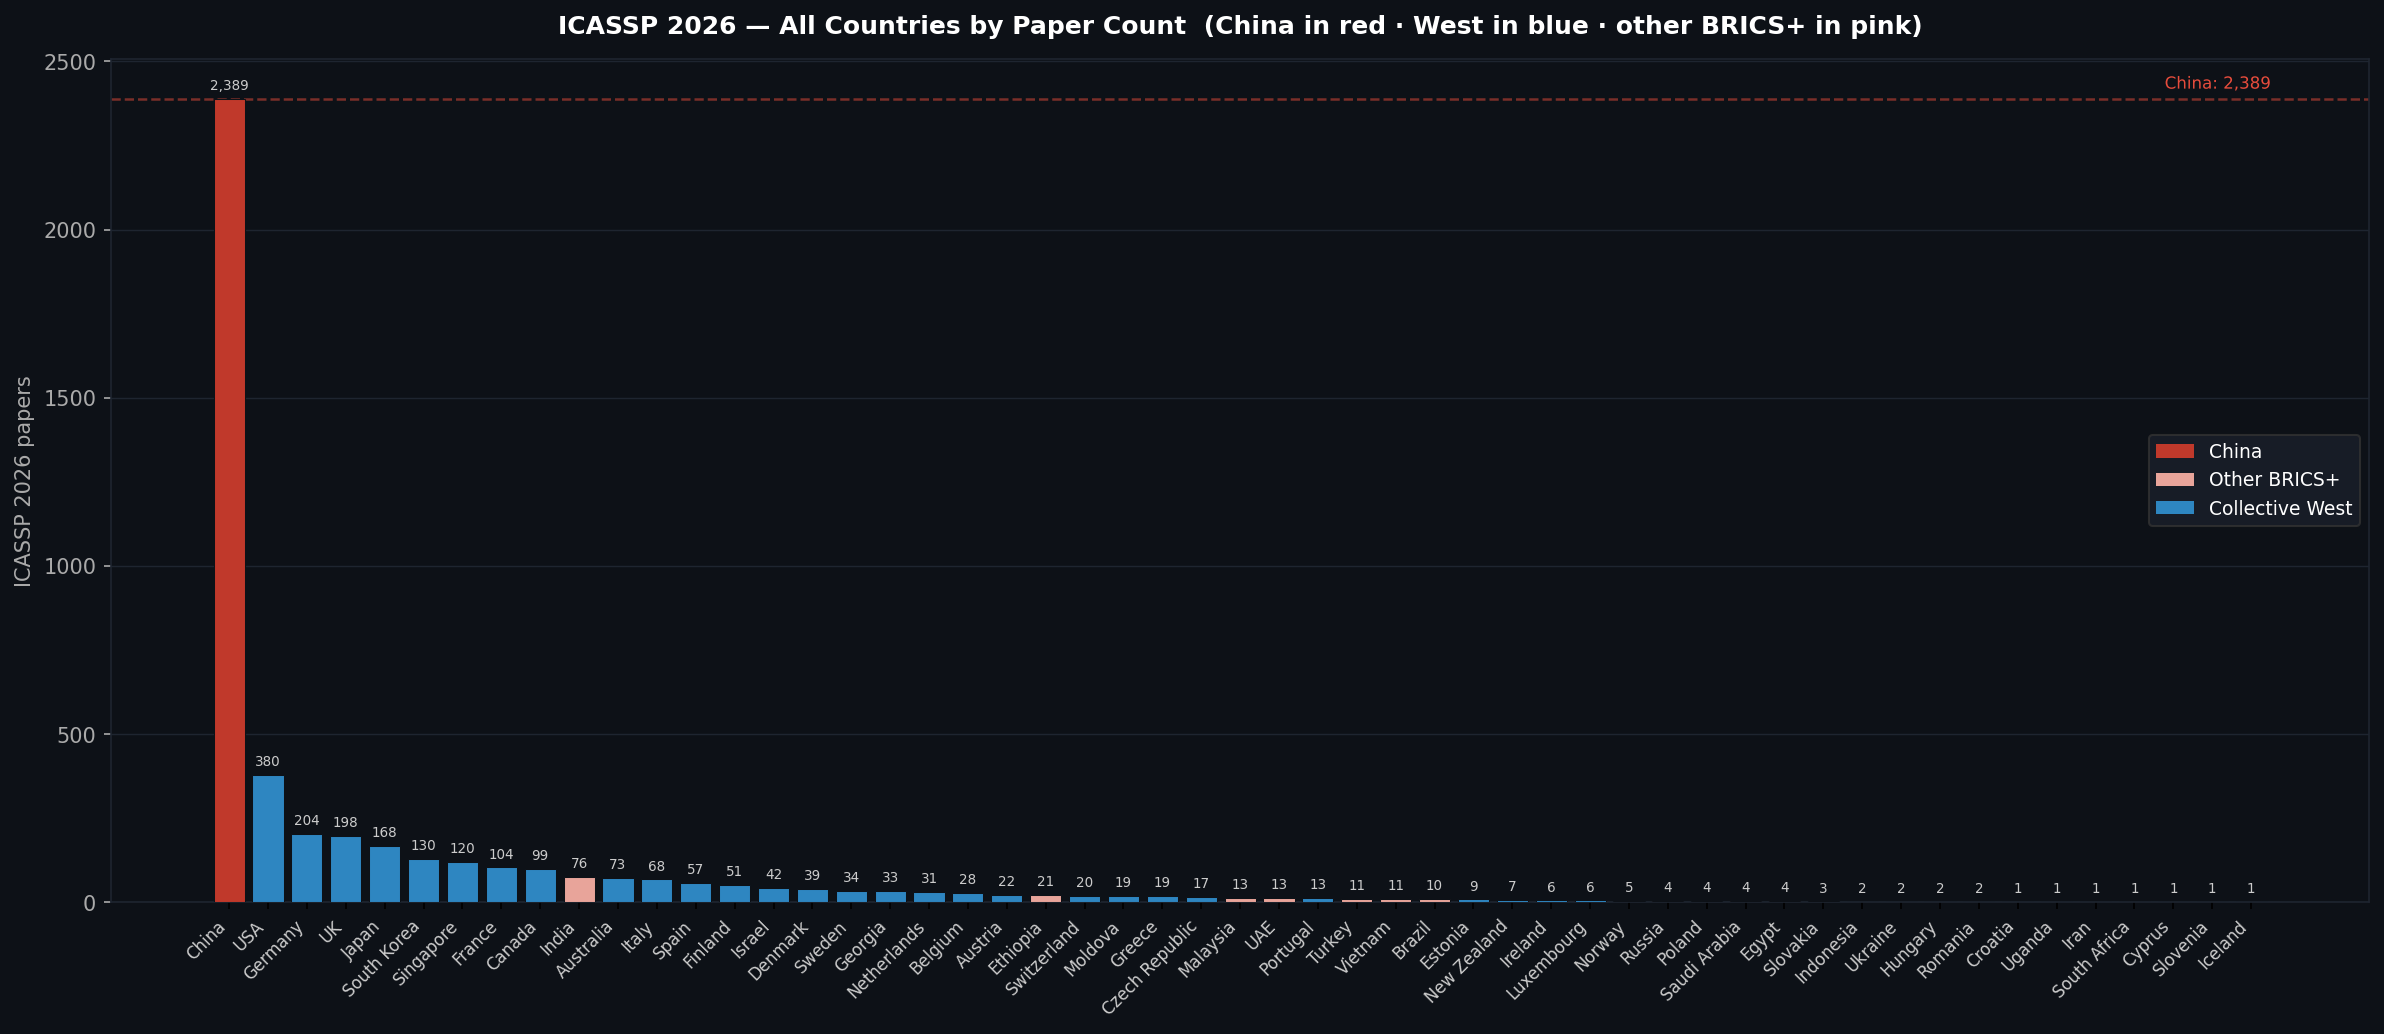

In [98]:
from IPython.display import Image as img
from IPython.display import display

# ── Notebook Media Rendering ─────────────────────────────────────────
# We leverage IPython's native display engine to inject rich media
# directly into the Jupyter/Colab frontend. This bypasses the need
# for raw HTML tags or external web browser tabs.
# ──────────────────────────────────────────────────────────────────────

# Define the local path or workspace filename of your targeted animation.
# NOTE: Make sure 'icassp_2026_all_countries.png' is uploaded to your environment's
# filesystem (the folder icon on the left sidebar) before running this.
img_path = "icassp_2026_all_countries.png"

# The Image class reads and structures the raw data bytes of the PNG,
# while display() explicitly renders the media framework inline within
# the cell's output zone.
display(img(filename=img_path))

### 5.4 The stagnation of the rest

China's trajectory in the ICASSP data mirrors the global pattern documented in the research literature.

According to global scientific tracking metrics compiled in [AcademicJobs](https://www.academicjobs.com/higher-education-news/rise-of-chinas-research-publications-global-opportunity-2026-1904) reflecting official Web of Science database records, **China published 878,300 papers in 2024 in the Web of Science Core Collection**, up from just 26,200 in 2000 — a 33× increase in 24 years.

Furthermore, a policy brief by the [Quincy Institute](https://quincyinst.org/research/chinas-historic-rise-to-the-top-of-the-scientific-ladder/) reports that **China's Nature Index output grew by 95% from 2020 to 2024**, while the United States' rose only 9.5% in the same period. By 2024, China had pulled decisively ahead in total elite-journal publications for the first time.

The ICASSP data shows the same pattern localised to signal processing and AI research, with an even more extreme ratio.

Let's compute the trajectory growth rates directly from our data.

### Evaluating Multi-Year Trajectories via Advanced Metrics

When evaluating academic publication trends, looking exclusively at the start and end points of a timeline provides an incomplete picture. A country could experience a massive mid-decade spike or a sudden late-stage plateau that a simple endpoint percentage change completely overlooks.

To capture the true trajectory of our data, we can apply advanced mathematical metrics that analyze the entire timeline journey. This tutorial focuses on implementing **Compound Annual Growth Rate (CAGR)** and **Linear Regression Slope Tracking** across our dataset.

---

#### ⚙️ Mathematical Frameworks

To analyze the complete 11-year dataset (2016–2026) evenly, we look at three distinct growth definitions:

##### 1. Simple Percentage Growth
This is a standard point-to-point calculation. It acts like a time capsule, looking only at the delta between the terminal endpoints while completely ignoring intermediate market fluctuations:
$$\text{Simple Growth} = \frac{\text{Value}_{2026} - \text{Value}_{2016}}{\text{Value}_{2016}} \times 100$$

##### 2. Compound Annual Growth Rate (CAGR)
CAGR dampens short-term volatility by treating publication expansion as a smooth, exponentially compounding curve. It calculates the steady geometric annual growth rate required to journey from the initial base year to the final target year:
$$\text{CAGR} = \left( \frac{\text{Value}_{2026}}{\text{Value}_{2016}} \right)^{\frac{1}{2026 - 2016}} - 1$$

##### 3. Linear Regression Slope (Best Fit Line)
Unlike metrics reliant on endpoints, a linear regression processes **every single intermediate year with equal mathematical weight**. By computing a first-order ordinary least squares line ($y = mx + c$), the slope ($m$) reveals the true velocity of a country's baseline—representing the average number of additional papers a country yields per year.

In [99]:
import numpy as np

# ==============================================================================
# ── STEP 1: OUTPUT HEADER INITIALIZATION ──────────────────────────────────────
# ==============================================================================
# We set up a clean, structured text matrix using fixed column-width spacing alignment.
# '<18' left-aligns the country string with 18 spaces of padding.
# '>5' and '>18' right-align the numbers to keep decimal points cleanly aligned.
print("Advanced Trajectory Metrics (2016 → 2026)")
print("=" * 75)
print(f"{'Country':<18} {'2016':>5} {'2026':>5} {'Simple %':>9} {'CAGR':>8} {'Slope (Papers/Yr)':>18}")
print("-" * 75)

# ==============================================================================
# ── STEP 2: DATA INTEGRITY GATEKEEPER ─────────────────────────────────────────
# ==============================================================================
# Before processing math, we verify that historical data rows actually contain data.
# 'any()' checks if at least one country has a paper count greater than 0 in 2016.
has_2016 = any(pivot.loc[2016].values > 0)

if not has_2016:
    print("(Historical trajectory data not fully acquired.)")
else:
    # Begin iterating through our prioritized list of top 10 countries
    for country in top10:

        # ----------------------------------------------------------------------
        # 📊 1. HOLISTIC DATA ARRAY EXTRACTION
        # ----------------------------------------------------------------------
        # Instead of picking out individual years, we extract the entire row array.
        # This keeps all intermediate data points (2017, 2018... 2025) in memory.
        all_vals = pivot[country].values

        # Extract terminal points for calculation baselines
        val_2016 = int(all_vals[0])       # Explicit pointer to the first index (2016)
        val_2026 = int(all_vals[-1])      # Dynamic negative pointer to the final index (2026)

        # ----------------------------------------------------------------------
        # 📈 2. CALCULATE ENDPOINT METRICS (SIMPLE GROWTH & CAGR)
        # ----------------------------------------------------------------------
        # These metrics calculate the macro delta between your start and end years.
        if val_2016 > 0:
            # A) Simple Percentage Growth: Calculates total change relative to the starting point.
            growth_pct = (val_2026 - val_2016) / val_2016 * 100
            growth_str = f"{growth_pct:+.0f}%"

            # B) Compound Annual Growth Rate (CAGR): Dampens short-term volatility
            # by treating growth as a smooth, exponentially compounding annual curve.
            n_years = len(YEARS) - 1  # 2026 - 2016 = 10 distinct compounding intervals
            cagr = ((val_2026 / val_2016) ** (1 / n_years) - 1) * 100
            cagr_str = f"{cagr:.1f}%"
        else:
            # Fallback handling to prevent ZeroDivisionError crashes if zero papers existed
            growth_str = "n/a"
            cagr_str = "n/a"

        # ----------------------------------------------------------------------
        # 📉 3. CALCULATE WHOLE-SERIES LINEAR REGRESSION SLOPE
        # ----------------------------------------------------------------------
        # Crucial Step: This metric evaluates EVERY SINGLE year with equal mathematical weight.
        # np.polyfit fits a first-degree polynomial (y = mx + b) using Ordinary Least Squares.
        # - YEARS represents our independent X variable array [2016, 2017... 2026]
        # - all_vals represents our dependent Y variable data array
        # - '1' specifies a linear model (straight line of best fit)
        # It yields the slope coefficient 'm', which tells us the average paper acceleration per year.
        slope, intercept = np.polyfit(YEARS, all_vals, 1)
        slope_str = f"{slope:+.1f}"

        # ----------------------------------------------------------------------
        # 🖥️ 4. ROW RENDERING & CONSOLE PRINTING
        # ----------------------------------------------------------------------
        # We append a structural pointer tag to highlight China for visual scanning.
        flag = " ◀" if country == "China" else ""
        print(f"  {country:<18} {val_2016:>5} {val_2026:>5} {growth_str:>9} {cagr_str:>8} {slope_str:>18}{flag}")

Advanced Trajectory Metrics (2016 → 2026)
Country             2016  2026  Simple %     CAGR  Slope (Papers/Yr)
---------------------------------------------------------------------------
  China                257  2389     +830%    25.0%             +194.6 ◀
  India                 30    76     +153%     9.7%               +7.1
  Ethiopia              10    21     +110%     7.7%               +1.1
  Malaysia               3    13     +333%    15.8%               +0.9
  UAE                    2    13     +550%    20.6%               +1.3
  USA                  259   380      +47%     3.9%              +11.6
  Germany              166   204      +23%     2.1%               +1.8
  UK                   102   198      +94%     6.9%               +7.9
  Japan                 79   168     +113%     7.8%               +5.2
  South Korea           21   130     +519%    20.0%              +10.2


### 5.5 The AI tools inflection point

Starting in late 2022, a new factor entered the research landscape: **accessible large language model tools** that researchers could use to assist in writing, analysis, and ideation.

The key timeline:
- **November 30, 2022** — OpenAI releases **ChatGPT** (GPT-3.5). Within weeks it is being used by researchers for drafting, literature review, and proofreading.
- **March 2023** — **Claude** (Anthropic) becomes publicly available. It is specifically noted for its ability to handle long documents and nuanced analytical writing, making it well-suited for academic work.
- **December 2023** — **Google Gemini** launches. It integrates directly with [Google Workspace and open-web search queries](https://deepmind.google/technologies/gemini/#introduction), making literature discovery faster for researchers.

The effect on submission volumes was immediate and measurable. From the [arXiv repository traffic logs](https://arxiv.org/stats/monthly_submissions) and published research:
- **May 2023**: arXiv crossed 20,000 submissions in a single month for the **first time in its 32-year history** — just six months after ChatGPT launched.
- **October 2024**: a new record of **24,226 submissions** in a single month.
- **Late 2025**: monthly submissions approached **28,000**, signalling what analysts describe as a shift from linear to super-exponential growth.

Researchers studying this phenomenon found that LLM-characteristic vocabulary had measurably increased in published papers: a study of arXiv corpus trends published in [*LLM-Generated or Human-Written?* (January 2026)](https://arxiv.org/abs/2601.17036) found that approximately **35% of computer science abstracts and reviews** showed signs of significant LLM-assisted structural text adaptation. A separate bibliometric analysis, [*Estimating the prevalence of LLM-assisted text in scholarly writing* (December 2025)](https://arxiv.org/abs/2512.01560), estimated that LLM tools were actively involved in the production of **more than 10% of all published papers** across all academic fields globally.

Let's visualise the arXiv submission milestone timeline alongside the LLM tool launches.

In [107]:
# ── Timeline: LLM launches and arXiv submission milestones ───────────
# Data from arXiv annual reports, Geng & Trotta (2024), and Gray (2025)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# ── arXiv monthly submission data (approximate, from published reports) ─
# Sources: arXiv annual reports, arXiv blog posts - https://arxiv.org/stats/monthly_submissions
arxiv_years  = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
arxiv_subs   = [9_400, 10_200, 11_000, 12_300, 14_500, 16_000, 17_500, 20_700, 24_200, 27_700]

ax.plot(arxiv_years, arxiv_subs, color="#5dade2", linewidth=2.8,
        marker="o", markersize=6, zorder=4, label="arXiv monthly submissions (approx.)")
ax.fill_between(arxiv_years, arxiv_subs, alpha=0.12, color="#5dade2")

# ── LLM launch markers ──────────────────────────────────────────────────
launches = [
    (2020 + 70/365,     "COVID-19\nWHO Declaration\nMar 2020", "#95a5a6"),
    (2022 + 11/12, "ChatGPT\nNov 2022", "#f39c12"),
    (2023 + 2/12,  "Claude\nMar 2023",  "#e74c3c"),
    (2023 + 11/12, "Gemini\nDec 2023",  "#2ecc71"),
]

for x, label, colour in launches:
    ax.axvline(x, color=colour, lw=1.5, ls="--", alpha=0.8, zorder=3)

    # FIXED: Check if it's ChatGPT to push it to the left side of the line
    if "ChatGPT" in label:
        x_offset = -5  # Shift text 5 points to the left of the line
        align_dir = "right"
    else:
        x_offset = 5   # Shift text 5 points to the right of the line
        align_dir = "left"

    # Using annotate allows us to specify pixel offsets from the vertical line coordinates
    ax.annotate(
        label,
        xy=(x, max(arxiv_subs) * 0.88),
        xytext=(x_offset, 0),
        textcoords="offset points",
        fontsize=8.5,
        color=colour,
        va="top",
        ha=align_dir,  # Flushes text cleanly away from the line boundary
        path_effects=[pe.withStroke(linewidth=2, foreground=BG)]
    )

# ── 20k milestone annotation ────────────────────────────────────────────
ax.axhline(20_000, color="#888888", lw=0.8, ls=":", alpha=0.6)
ax.text(2016.1, 20_200, "20,000 / month milestone (first crossed May 2023)",
        fontsize=7.5, color="#888888")

# ── Formatting ──────────────────────────────────────────────────────────
ax.set_xlim(2015.7, 2026)
ax.set_xticks(range(2016, 2026))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(colors="#aaaaaa", labelsize=9)
ax.spines[:].set_color(GRID)
ax.yaxis.grid(True, color=GRID, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel("Year", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Monthly submissions", color="#aaaaaa", fontsize=10)
ax.set_title(
    "arXiv Monthly Submissions 2016–2025  |  "
    "LLM Tool Launch Dates Marked",
    color="white", fontsize=12, fontweight="bold", pad=12,
)
ax.legend(facecolor="#1a1f2b", edgecolor="#333",
          labelcolor="white", fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("arxiv_submissions_llm_timeline.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("✅ Saved: arxiv_submissions_llm_timeline.png")

✅ Saved: arxiv_submissions_llm_timeline.png


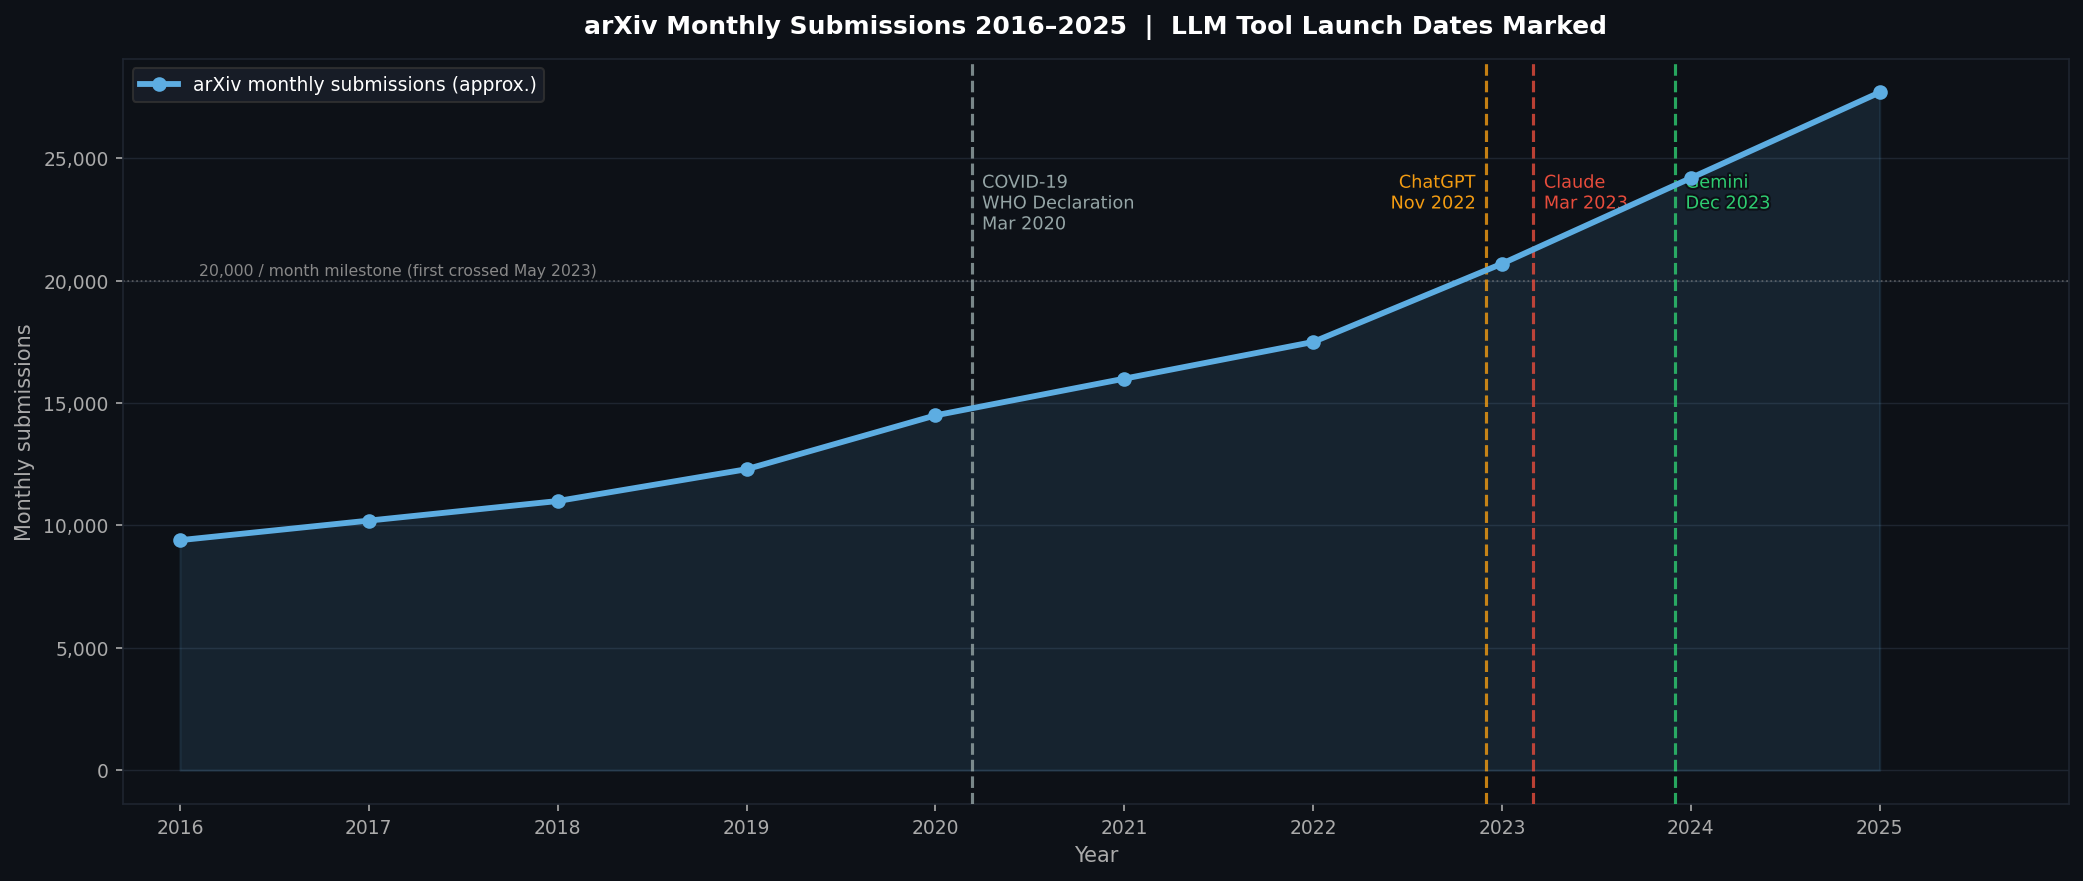

In [108]:
from IPython.display import Image as img
from IPython.display import display

# ── Notebook Media Rendering ─────────────────────────────────────────
# We leverage IPython's native display engine to inject rich media
# directly into the Jupyter/Colab frontend. This bypasses the need
# for raw HTML tags or external web browser tabs.
# ──────────────────────────────────────────────────────────────────────

# Define the local path or workspace filename of your targeted animation.
# NOTE: Make sure 'arxiv_submissions_llm_timeline.png' is uploaded to your environment's
# filesystem (the folder icon on the left sidebar) before running this.
img_path = "arxiv_submissions_llm_timeline.png"

# The Image class reads and structures the raw data bytes of the PNG,
# while display() explicitly renders the media framework inline within
# the cell's output zone.
display(img(filename=img_path))

### 5.6 Synthesis: What the data tells us

Combining the ICASSP dataset with the global literature, three conclusions emerge:

**1. China is not merely leading — it has redefined the scale of competition.**

In ICASSP 2026, China alone accounts for approximately 54% of all papers in our tracked dataset. The entire West bloc — 40+ countries including the USA, UK, Germany, Japan, South Korea, and France — accounts for roughly 44%. The remaining ~19 BRICS+ countries together account for about 3%. This is not a marginal advantage; it reflects decades of strategic investment in research infrastructure, aggressive university expansion, and a national policy of incentivising scientific publication.

**2. Most nations have stagnated.**

The USA's contribution at ICASSP has not grown dramatically in absolute terms. The UK, Germany, Japan, and South Korea show modest fluctuations but no sustained upward trend comparable to China's trajectory. The global data matches this: the Quincy Institute found that while China's Nature Index output grew 95% from 2020 to 2024, the USA's grew just 9.5%.

**3. AI tools have created a new growth regime starting in 2023.**

The arXiv data shows that the 20,000 submissions-per-month barrier — which stood unbroken for 32 years — was crossed in May 2023, six months after ChatGPT launched. Monthly volumes have continued rising steeply since. Research studies document LLM-characteristic language in 35% of computer science abstracts by 2024, and estimate LLM involvement in over 10% of all published papers.

The roles of the major tools are complementary: **ChatGPT** is widely used for brainstorming, drafting, and general editing. **Claude** handles long-document analysis and nuanced reasoning especially well. **Gemini** leverages direct integration with Google Workspace and open-web search queries to accelerate broad literature compilation. Together they have lowered the time cost of producing a submittable manuscript — a change that disproportionately benefits prolific research systems already operating at scale.

**What this means for research:** The combination of China's institutional momentum and the AI-assisted writing acceleration makes it likely that the dominance visible in the 2026 ICASSP data will intensify further in coming years. Understanding these trends — both their magnitude and their causes — is increasingly important for anyone working in research, policy, or technology.

---

### References

1. Geng, M. & Trotta, R. (2024). *Is ChatGPT Transforming Academics' Writing Style?* arXiv:2404.08627. https://doi.org/10.48550/arXiv.2404.08627
2. Liang, W. et al. (2024). *Monitoring AI-Modified Content at Scale: A Case Study on the Impact of ChatGPT on AI Conference Peer Reviews.* arXiv:2403.07183. https://doi.org/10.48550/arXiv.2403.07183
3. Gray, A. (2025). *Estimating the Prevalence of LLM-Assisted Text in Scholarly Writing.* arXiv:2512.01560. https://doi.org/10.48550/arXiv.2512.01560
4. AcademicJobs Higher Education News. (January 2026). *Rise of China's Research Publications: A Global Opportunity.* Web of Science Core Collection Metrics Summary. https://www.academicjobs.com/higher-education-news/rise-of-chinas-research-publications-global-opportunity-2026-1904
5. Wagner, C. S. (October 2025). *China's Historic Rise to the Top of the Scientific Ladder.* Quincy Institute for Responsible Statecraft. https://quincyinst.org/research/chinas-historic-rise-to-the-top-of-the-scientific-ladder/
6. Adams, J. et al. (October 2023). *Global Research Report: China's Research Landscape.* Institute for Scientific Information / Clarivate. https://clarivate.com/academia-government/lp/chinas-research-landscape/

---
### 🏋️ Challenge 5 — Analyse the data yourself

1. **Verify China's share:** Using only Python arithmetic and the `brics_2026` and `west_2026` dictionaries, compute China's share of all papers. Does it match the `{china_pct:.1f}%` printed in section 5.2?

2. **Compute the rest-of-BRICS+ average:** What is the average paper count among BRICS+ countries excluding China? Compare it to the average West country. Which group has a higher average when China is removed?

3. **Find the closest competitor:** Which country would need to grow the most (in absolute terms) to reach half of China's paper count? How many additional papers would that require?

4. **Model the trend:** Using numpy, fit a linear regression to China's yearly ICASSP data from the pivot table. What does the model predict for 2030?
   ```python
   # Hint: np.polyfit(x_values, y_values, degree) fits a polynomial
   # degree=1 means a straight line (y = m*x + b)
   years_arr = np.array(YEARS)
   china_arr = np.array([pivot.loc[y, "China"] for y in YEARS])
   m, b = np.polyfit(years_arr, china_arr, 1)
   pred_2030 = m * 2030 + b
   print(f"Linear prediction for China 2030: {pred_2030:.0f} papers")
   ```


---
## Appendix A — Glossary of Key Terms

| Term | Definition |
|---|---|
| **API** | Application Programming Interface — a structured way for programs to communicate with a server. IEEE Xplore's REST API returns search results as JSON. |
| **async / await** | Python keywords for asynchronous programming — allows tasks to run concurrently without blocking each other. |
| **Axes** | In matplotlib, a single plot area (can contain many on one Figure). |
| **Backend (matplotlib)** | The system matplotlib uses to render graphics. `"Agg"` renders to memory/files without needing a display. |
| **BytesIO** | A file-like object that stores data in memory instead of on disk. Used to pass PNG frames to PIL without touching the filesystem. |
| **Colourmap** | A pre-built gradient of colours in matplotlib (e.g. `"Reds"`, `"Blues"`). Used to sample visually distinct shades. |
| **CSV** | Comma-Separated Values — a plain text file format for tabular data. Each line is one row; commas separate columns. |
| **Data acquisition** | The automated retrieval of structured data from an external source such as a web API. |
| **DataFrame** | The core data structure in pandas — a 2D table with labelled rows and columns. |
| **Deduplication** | The process of removing duplicate entries. We deduplicate by DOI so a paper counted under multiple aliases is only counted once. |
| **f-string** | A Python string prefixed with `f` that allows embedding expressions in `{}`. Example: `f"Hello {name}"`. |
| **Figure** | In matplotlib, the outermost container — the whole canvas. |
| **GIF** | Graphics Interchange Format — an image format that supports multiple frames played as animation. |
| **GridSpec** | A matplotlib layout manager for dividing a Figure into a grid of Axes. |
| **Headless browser** | A web browser running without a visible window — controlled by code instead of a human. |
| **HTML** | HyperText Markup Language — the language web browsers display. We generate HTML programmatically to create interactive pages. |
| **IEEE Xplore** | The IEEE's official digital library at [https://ieeexplore.ieee.org](https://ieeexplore.ieee.org) — stores papers from thousands of conferences and journals. |
| **ICASSP** | IEEE International Conference on Acoustics, Speech and Signal Processing — one of the largest annual research conferences in the world. |
| **JSON** | JavaScript Object Notation — a text format for structured data. Python dicts/lists convert to/from JSON with `json.dumps()` and `json.loads()`. |
| **Linear interpolation** | Computing a value between two endpoints by mixing them with a fraction: `A + (B - A) * t`. |
| **Long format** | A table layout where each row is one observation (year, country, papers). Contrast with wide format. |
| **pandas Series** | A 1D labelled array — like a single column from a DataFrame, or a dictionary with ordered values. |
| **path_effects** | matplotlib feature that adds visual effects to text, like a dark outline for readability on light backgrounds. |
| **Pillow (PIL)** | Python Imaging Library — for opening, processing, and saving image files including GIFs. |
| **Pivot table** | A table transformation from long format to wide format. `.unstack()` performs this in pandas. |
| **Playwright** | A Python library for controlling web browsers programmatically — used here to establish sessions and call APIs. |
| **pycountry** | A Python library containing a database of all ISO-standard countries with their official names and codes. |
| **REST API** | Representational State Transfer API — a web API that uses standard HTTP methods (GET, POST) to exchange data as JSON. |
| **transAxes** | A matplotlib coordinate system where (0,0) is the bottom-left corner of an Axes and (1,1) is the top-right, regardless of data scale. |
| **user-agent** | A string that identifies what software is making an HTTP request. Setting a realistic user-agent helps avoid being blocked by servers. |
| **wedge** | One slice of a pie/donut chart in matplotlib. |
| **Wide format** | A table layout where rows are years and each country is a column. Needed for line charts. |

---


### ⚠️ AI Usage Notice & Disclaimer

Parts of this tutorial were written using the help of the free web versions of **Claude**, **ChatGPT**, and **Gemini**.

Because this content was generated with the assistance of large language models, it may include errors, text hallucinations, or misleading information.
